In [11]:
import uproot

file = uproot.open("Sim_D2ODetector006.root")
Sim_Tree = file["Sim_Tree"]

# List all branches
print("Available branches:")
for branch in Sim_Tree.keys():
    print(f"  {branch}")

Available branches:
  eventData
  eventData/TObject
  eventData/TObject/fUniqueID
  eventData/TObject/fBits
  eventData/narrow_veto_edep[4]
  eventData/wide_veto_edep[4]
  eventData/eventNumber
  eventData/direction0
  eventData/position0
  eventData/vol0
  eventData/veto_tag
  eventData/veto_edep
  eventData/sourceParticleEnergy
  eventData/numHits
  eventData/numHitsArea
  eventData/muVetoEnergy[12]
  eventData/pmtHits
  eventData/pmtHits/pmtHits.fUniqueID
  eventData/pmtHits/pmtHits.fBits
  eventData/pmtHits/pmtHits.pmtNum
  eventData/pmtHits/pmtHits.eventTime
  eventData/pmtHits/pmtHits.photonEnergy
  eventData/pmtHits/pmtHits.parentType
  eventData/areaPMTHits
  eventData/areaPMTHits/areaPMTHits.fUniqueID
  eventData/areaPMTHits/areaPMTHits.fBits
  eventData/areaPMTHits/areaPMTHits.pmtNum
  eventData/areaPMTHits/areaPMTHits.eventTime
  eventData/areaPMTHits/areaPMTHits.photonEnergy
  eventData/areaPMTHits/areaPMTHits.parentType
  eventData/areaPMTHits/areaPMTHits.photonPosition
  

In [23]:
path = "Sim_D2ODetector003.root" 

Libraries imported successfully
File opened: Sim_D2ODetector003.root
Total events: 1000000

Loading gamma particle data...
  Total gamma particles: 2,177,676
  Min gamma energy: 0.000017 MeV
  Max gamma energy: 10.829135 MeV


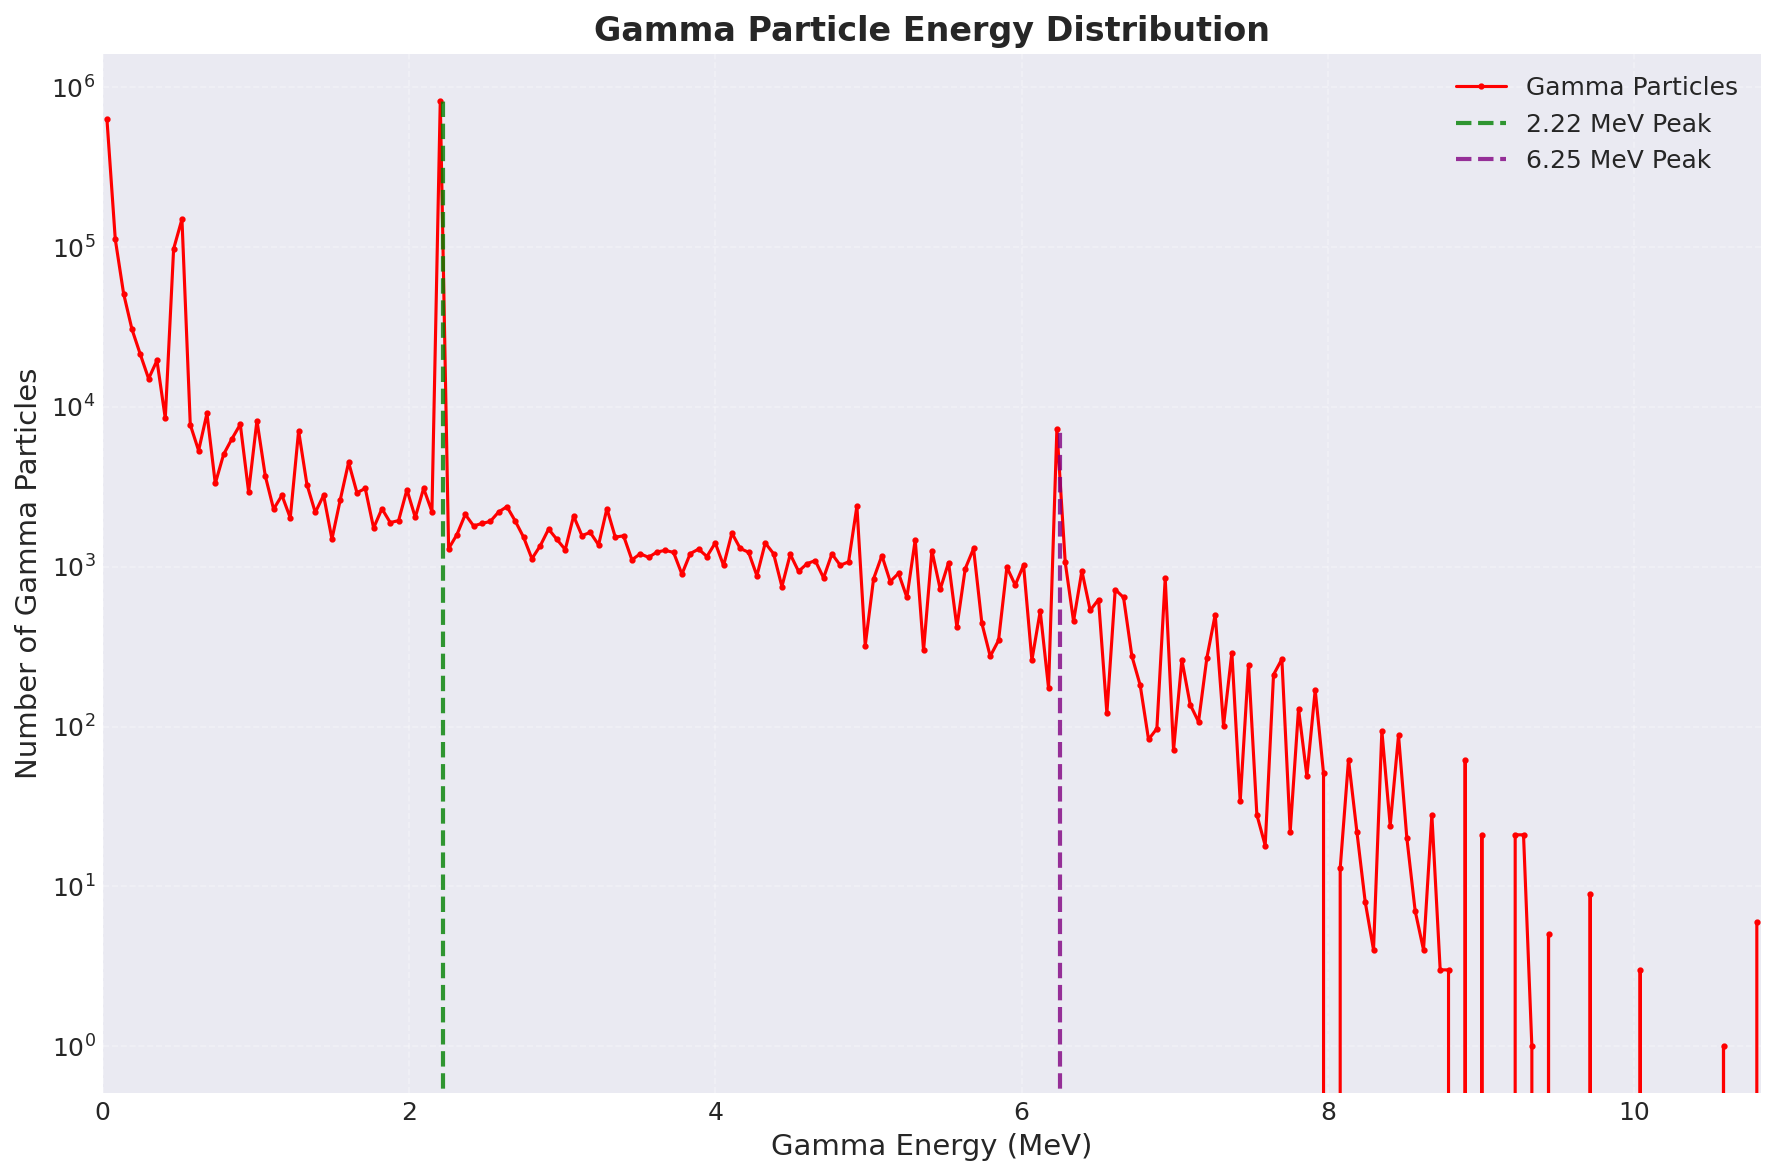


Figure saved as: figure_gamma_full_range.png
  Vertical line at 2.22 MeV extends to y = 823640
  Vertical line at 6.25 MeV extends to y = 7274

GAMMA PARTICLE STATISTICS (MeV)

Gamma Particles (All):
  Count: 2,177,676
  Mean energy: 1.192403 MeV
  Median energy: 0.510999 MeV
  Std dev: 1.253067 MeV
  Min energy: 0.000017 MeV
  Max energy: 10.829135 MeV

  Energy range distribution:
    < 1 keV:            312 (  0.0%)
    1-10 keV:       271,581 ( 12.5%)
    10-100 keV:     456,824 ( 21.0%)
    0.1-1 MeV:      456,147 ( 20.9%)
    1-10 MeV:       992,802 ( 45.6%)
    >10 MeV:             10 (  0.0%)

ANALYSIS COMPLETE


In [24]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
import os

# Set publication-quality plot parameters
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.dpi'] = 150

print("Libraries imported successfully")

# ============================================================
# SPECIFY YOUR FILE HERE
# ============================================================

if not os.path.exists(path):
    print(f"Error: {path} not found!")
    exit()

file = uproot.open(path)
Sim_Tree = file["Sim_Tree"]
event_data = Sim_Tree["eventData"]
print(f"File opened: {path}")
print(f"Total events: {Sim_Tree.num_entries}")

# ============================================================
# LOAD GAMMA DATA FROM ALL PARTICLES
# ============================================================
print("\nLoading gamma particle data...")

try:
    all_particle_pdg = event_data["allParticlePDG"].array()
    all_particle_energy = event_data["allParticleEnergy"].array()
    all_particle_parentID = event_data["allParticleParentID"].array()
    
    all_pdg_flat = ak.to_numpy(ak.flatten(all_particle_pdg))
    all_energy_flat = ak.to_numpy(ak.flatten(all_particle_energy))
    all_parentID_flat = ak.to_numpy(ak.flatten(all_particle_parentID))
    
    # Filter for gamma particles (PDG 22)
    gamma_particle_mask = (all_pdg_flat == 22)
    gamma_particle_energies = all_energy_flat[gamma_particle_mask]  # Already in MeV
    
    # Remove any zero or negative energies
    gamma_particle_energies = gamma_particle_energies[gamma_particle_energies > 0]
    
    n_all_gammas = len(gamma_particle_energies)
    
    print(f"  Total gamma particles: {n_all_gammas:,}")
    print(f"  Min gamma energy: {np.min(gamma_particle_energies):.6f} MeV")
    print(f"  Max gamma energy: {np.max(gamma_particle_energies):.6f} MeV")
    
except Exception as e:
    print(f"✗ Error loading gamma particle data: {e}")
    gamma_particle_energies = np.array([])
    n_all_gammas = 0

# ============================================================
# FIGURE: ALL GAMMA PARTICLES (Full range with vertical lines to peak)
# ============================================================
if n_all_gammas > 0:
    
    max_energy = np.max(gamma_particle_energies)
    
    # Define bins for full range
    bins_full = np.linspace(0, max_energy, 200)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Calculate histogram
    hist, bin_edges = np.histogram(gamma_particle_energies, bins=bins_full)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Plot the histogram as a line - changed color to orange
    ax.plot(bin_centers, hist, color='red', marker='o', markersize=2, 
            linewidth=1.5, label='Gamma Particles', linestyle='-')
    
    # Find the maximum y-value (peak of the histogram)
    max_y = np.max(hist)
    
    # Add vertical lines from x-axis up to the peak value at 2.22 MeV and 6.25 MeV
    # Find the histogram values at these specific energies
    idx_2p22 = np.argmin(np.abs(bin_centers - 2.22))
    idx_6p25 = np.argmin(np.abs(bin_centers - 6.25))
    
    y_2p22 = hist[idx_2p22]  # Height at 2.22 MeV
    y_6p25 = hist[idx_6p25]  # Height at 6.25 MeV
    
    # Draw vertical lines from 0 to the histogram height at those energies
    ax.vlines(x=2.22, ymin=0, ymax=y_2p22, colors='green', linestyles='--', 
              linewidth=2, alpha=0.8, label='2.22 MeV Peak')
    ax.vlines(x=6.25, ymin=0, ymax=y_6p25, colors='purple', linestyles='--', 
              linewidth=2, alpha=0.8, label='6.25 MeV Peak')
    
    ax.set_xlabel('Gamma Energy (MeV)', fontsize=14)
    ax.set_ylabel('Number of Gamma Particles', fontsize=14)
    ax.set_title('Gamma Particle Energy Distribution', fontsize=16, fontweight='bold')
    ax.set_xlim(0, max_energy)
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3, axis='both', linestyle='--')
    ax.legend(fontsize=12)
    
    plt.tight_layout()
    plt.savefig('figure_gamma_full_range.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nFigure saved as: figure_gamma_full_range.png")
    print(f"  Vertical line at 2.22 MeV extends to y = {y_2p22:.0f}")
    print(f"  Vertical line at 6.25 MeV extends to y = {y_6p25:.0f}")

else:
    print("\n" + "="*80)
    print("NO GAMMA PARTICLES FOUND")
    print("="*80)
    print("This is expected for EM shower simulation.")
    print("Gamma particles will appear when there are gamma interactions.")

# ============================================================
# PRINT GAMMA STATISTICS
# ============================================================
print("\n" + "="*80)
print("GAMMA PARTICLE STATISTICS (MeV)")
print("="*80)

if n_all_gammas > 0:
    print(f"\nGamma Particles (All):")
    print(f"  Count: {n_all_gammas:,}")
    print(f"  Mean energy: {np.mean(gamma_particle_energies):.6f} MeV")
    print(f"  Median energy: {np.median(gamma_particle_energies):.6f} MeV")
    print(f"  Std dev: {np.std(gamma_particle_energies):.6f} MeV")
    print(f"  Min energy: {np.min(gamma_particle_energies):.6f} MeV")
    print(f"  Max energy: {np.max(gamma_particle_energies):.6f} MeV")
    
    # Count gammas in specific energy ranges
    n_very_low = np.sum(gamma_particle_energies < 0.001)
    n_low = np.sum((gamma_particle_energies >= 0.001) & (gamma_particle_energies < 0.01))
    n_med_low = np.sum((gamma_particle_energies >= 0.01) & (gamma_particle_energies < 0.1))
    n_med = np.sum((gamma_particle_energies >= 0.1) & (gamma_particle_energies < 1))
    n_high = np.sum((gamma_particle_energies >= 1) & (gamma_particle_energies < 10))
    n_very_high = np.sum(gamma_particle_energies >= 10)
    
    print(f"\n  Energy range distribution:")
    print(f"    < 1 keV:       {n_very_low:>8,} ({100*n_very_low/n_all_gammas:>5.1f}%)")
    print(f"    1-10 keV:      {n_low:>8,} ({100*n_low/n_all_gammas:>5.1f}%)")
    print(f"    10-100 keV:    {n_med_low:>8,} ({100*n_med_low/n_all_gammas:>5.1f}%)")
    print(f"    0.1-1 MeV:     {n_med:>8,} ({100*n_med/n_all_gammas:>5.1f}%)")
    print(f"    1-10 MeV:      {n_high:>8,} ({100*n_high/n_all_gammas:>5.1f}%)")
    print(f"    >10 MeV:       {n_very_high:>8,} ({100*n_very_high/n_all_gammas:>5.1f}%)")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)

In [ ]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
import os

# Set publication-quality plot parameters
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.dpi'] = 150

print("Libraries imported successfully")

# ============================================================
# SPECIFY YOUR FILE HERE
# ============================================================
path = "Sim_D2ODetector007.root" 

if not os.path.exists(path):
    print(f"Error: {path} not found!")
    exit()

file = uproot.open(path)
Sim_Tree = file["Sim_Tree"]
event_data = Sim_Tree["eventData"]
print(f"File opened: {path}")
print(f"Total events: {Sim_Tree.num_entries}")

# ============================================================
# LOAD GAMMA DATA FROM ALL PARTICLES
# ============================================================
print("\nLoading gamma particle data...")

try:
    all_particle_pdg = event_data["allParticlePDG"].array()
    all_particle_energy = event_data["allParticleEnergy"].array()
    all_particle_parentID = event_data["allParticleParentID"].array()
    
    all_pdg_flat = ak.to_numpy(ak.flatten(all_particle_pdg))
    all_energy_flat = ak.to_numpy(ak.flatten(all_particle_energy))
    all_parentID_flat = ak.to_numpy(ak.flatten(all_particle_parentID))
    
    # Filter for gamma particles (PDG 22)
    gamma_particle_mask = (all_pdg_flat == 22)
    gamma_particle_energies = all_energy_flat[gamma_particle_mask]  # Already in MeV
    
    # Remove any zero or negative energies
    gamma_particle_energies = gamma_particle_energies[gamma_particle_energies > 0]
    
    n_all_gammas = len(gamma_particle_energies)
    
    print(f"  Total gamma particles: {n_all_gammas:,}")
    print(f"  Min gamma energy: {np.min(gamma_particle_energies):.6f} MeV")
    print(f"  Max gamma energy: {np.max(gamma_particle_energies):.6f} MeV")
    
except Exception as e:
    print(f"✗ Error loading gamma particle data: {e}")
    gamma_particle_energies = np.array([])
    n_all_gammas = 0

# ============================================================
# FIGURE: ALL GAMMA PARTICLES (0-10 MeV range with vertical lines to peak)
# ============================================================
if n_all_gammas > 0:
    
    max_energy = np.max(gamma_particle_energies)
    
    # Define bins for 0-10 MeV range
    bins_full = np.linspace(0, 10, 200)  # CHANGED: from max_energy to 10
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Calculate histogram
    hist, bin_edges = np.histogram(gamma_particle_energies, bins=bins_full)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Plot the histogram as a line
    ax.plot(bin_centers, hist, color='red', marker='o', markersize=2, 
            linewidth=1.5, label='Gamma Particles', linestyle='-')
    
    # Find the maximum y-value (peak of the histogram)
    max_y = np.max(hist)
    
    # Add vertical lines from x-axis up to the peak value at 2.22 MeV and 6.25 MeV
    # Find the histogram values at these specific energies
    idx_2p22 = np.argmin(np.abs(bin_centers - 2.22))
    idx_6p25 = np.argmin(np.abs(bin_centers - 6.25))
    
    y_2p22 = hist[idx_2p22]  # Height at 2.22 MeV
    y_6p25 = hist[idx_6p25]  # Height at 6.25 MeV
    
    # Draw vertical lines from 0 to the histogram height at those energies
    ax.vlines(x=2.22, ymin=0, ymax=y_2p22, colors='green', linestyles='--', 
              linewidth=2, alpha=0.8, label='2.22 MeV Peak')
    ax.vlines(x=6.25, ymin=0, ymax=y_6p25, colors='purple', linestyles='--', 
              linewidth=2, alpha=0.8, label='6.25 MeV Peak')
    
    ax.set_xlabel('Gamma Energy (MeV)', fontsize=14)
    ax.set_ylabel('Number of Gamma Particles', fontsize=14)
    ax.set_title('Gamma Particle Energy Distribution (0-10 MeV)', fontsize=16, fontweight='bold')  # CHANGED: updated title
    ax.set_xlim(0, 10)  # CHANGED: from max_energy to 10
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3, axis='both', linestyle='--')
    ax.legend(fontsize=12)
    
    plt.tight_layout()
    plt.savefig('figure_gamma_0-10MeV.png', dpi=300, bbox_inches='tight')  # CHANGED: updated filename
    plt.show()
    
    print(f"\nFigure saved as: figure_gamma_0-10MeV.png")
    print(f"  Vertical line at 2.22 MeV extends to y = {y_2p22:.0f}")
    print(f"  Vertical line at 6.25 MeV extends to y = {y_6p25:.0f}")

else:
    print("\n" + "="*80)
    print("NO GAMMA PARTICLES FOUND")
    print("="*80)
    print("This is expected for EM shower simulation.")
    print("Gamma particles will appear when there are gamma interactions.")

# ============================================================
# PRINT GAMMA STATISTICS
# ============================================================
print("\n" + "="*80)
print("GAMMA PARTICLE STATISTICS (MeV)")
print("="*80)

if n_all_gammas > 0:
    print(f"\nGamma Particles (All):")
    print(f"  Count: {n_all_gammas:,}")
    print(f"  Mean energy: {np.mean(gamma_particle_energies):.6f} MeV")
    print(f"  Median energy: {np.median(gamma_particle_energies):.6f} MeV")
    print(f"  Std dev: {np.std(gamma_particle_energies):.6f} MeV")
    print(f"  Min energy: {np.min(gamma_particle_energies):.6f} MeV")
    print(f"  Max energy: {np.max(gamma_particle_energies):.6f} MeV")
    
    # Count gammas in specific energy ranges
    n_very_low = np.sum(gamma_particle_energies < 0.001)
    n_low = np.sum((gamma_particle_energies >= 0.001) & (gamma_particle_energies < 0.01))
    n_med_low = np.sum((gamma_particle_energies >= 0.01) & (gamma_particle_energies < 0.1))
    n_med = np.sum((gamma_particle_energies >= 0.1) & (gamma_particle_energies < 1))
    n_high = np.sum((gamma_particle_energies >= 1) & (gamma_particle_energies < 10))
    n_very_high = np.sum(gamma_particle_energies >= 10)
    
    print(f"\n  Energy range distribution:")
    print(f"    < 1 keV:       {n_very_low:>8,} ({100*n_very_low/n_all_gammas:>5.1f}%)")
    print(f"    1-10 keV:      {n_low:>8,} ({100*n_low/n_all_gammas:>5.1f}%)")
    print(f"    10-100 keV:    {n_med_low:>8,} ({100*n_med_low/n_all_gammas:>5.1f}%)")
    print(f"    0.1-1 MeV:     {n_med:>8,} ({100*n_med/n_all_gammas:>5.1f}%)")
    print(f"    1-10 MeV:      {n_high:>8,} ({100*n_high/n_all_gammas:>5.1f}%)")
    print(f"    >10 MeV:       {n_very_high:>8,} ({100*n_very_high/n_all_gammas:>5.1f}%)")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)

Libraries imported successfully
File opened: Sim_D2ODetector007.root
Total events: 100000

Loading gamma particle data...


File opened: Sim_D2ODetector003.root
Total events: 1000000

Loading particle data...
✓ All particles data found

Identifying deuterons and tritium...
Deuterons found: 821,476
Tritium found: 7,178

Deuteron exponential fit (range: 0-800 μs):
  A = 648.1, τ = 378.9 μs, C = 245.2


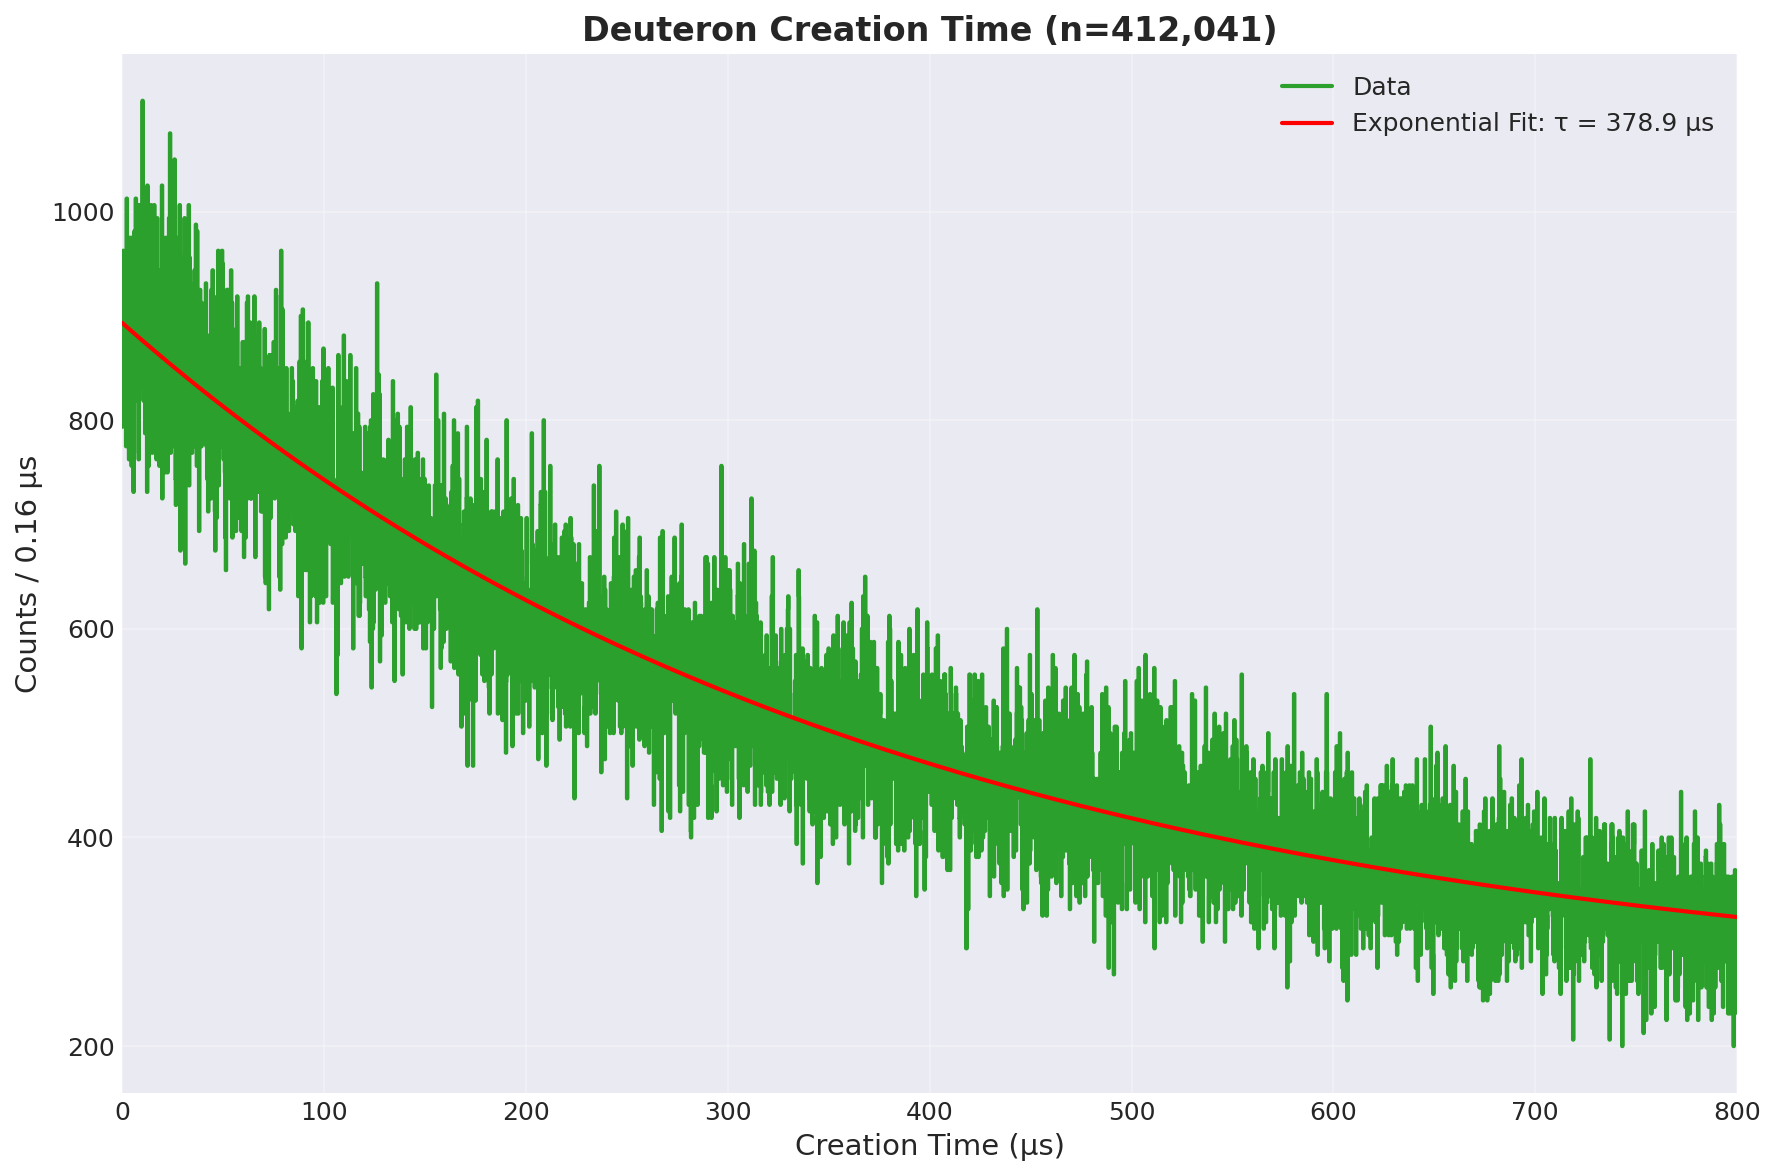


Tritium exponential fit (range: 0-11871 μs):
  A = 5.5, τ = 1260.9 μs, C = 0.0


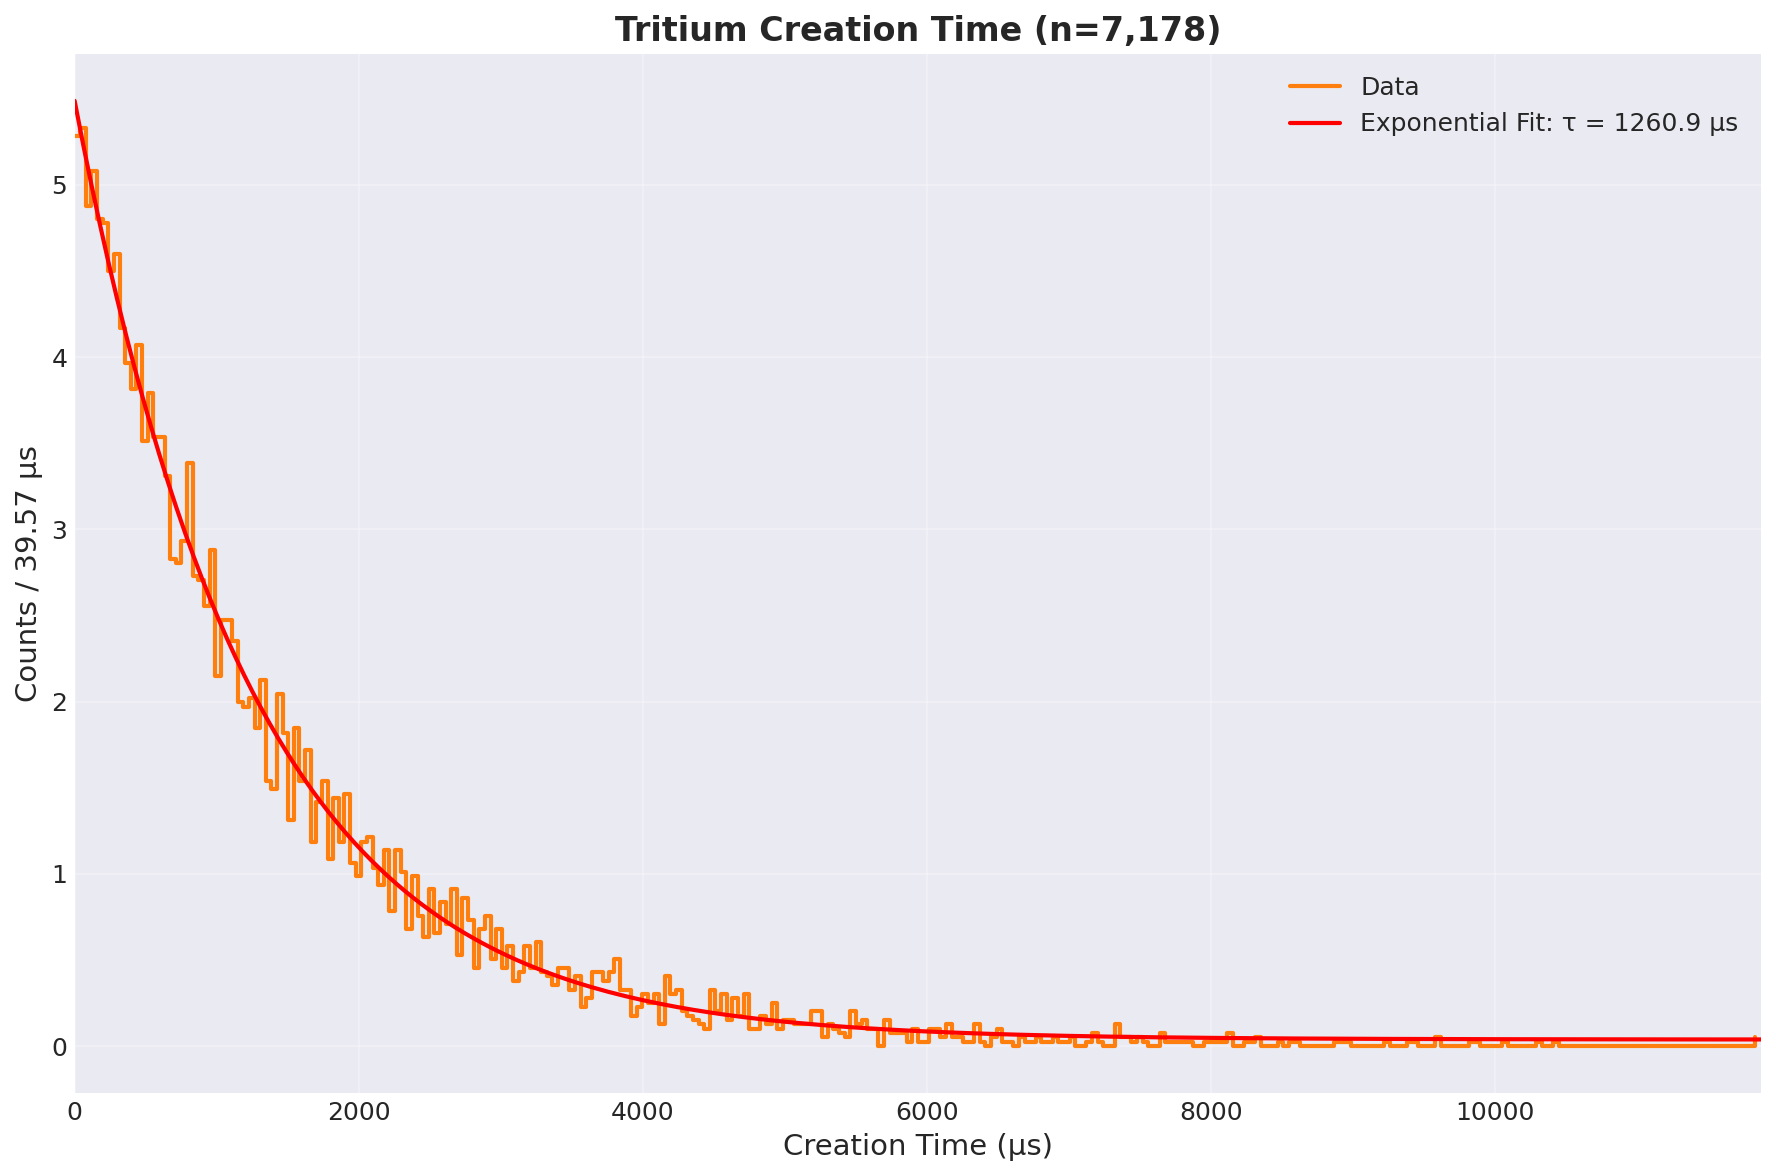

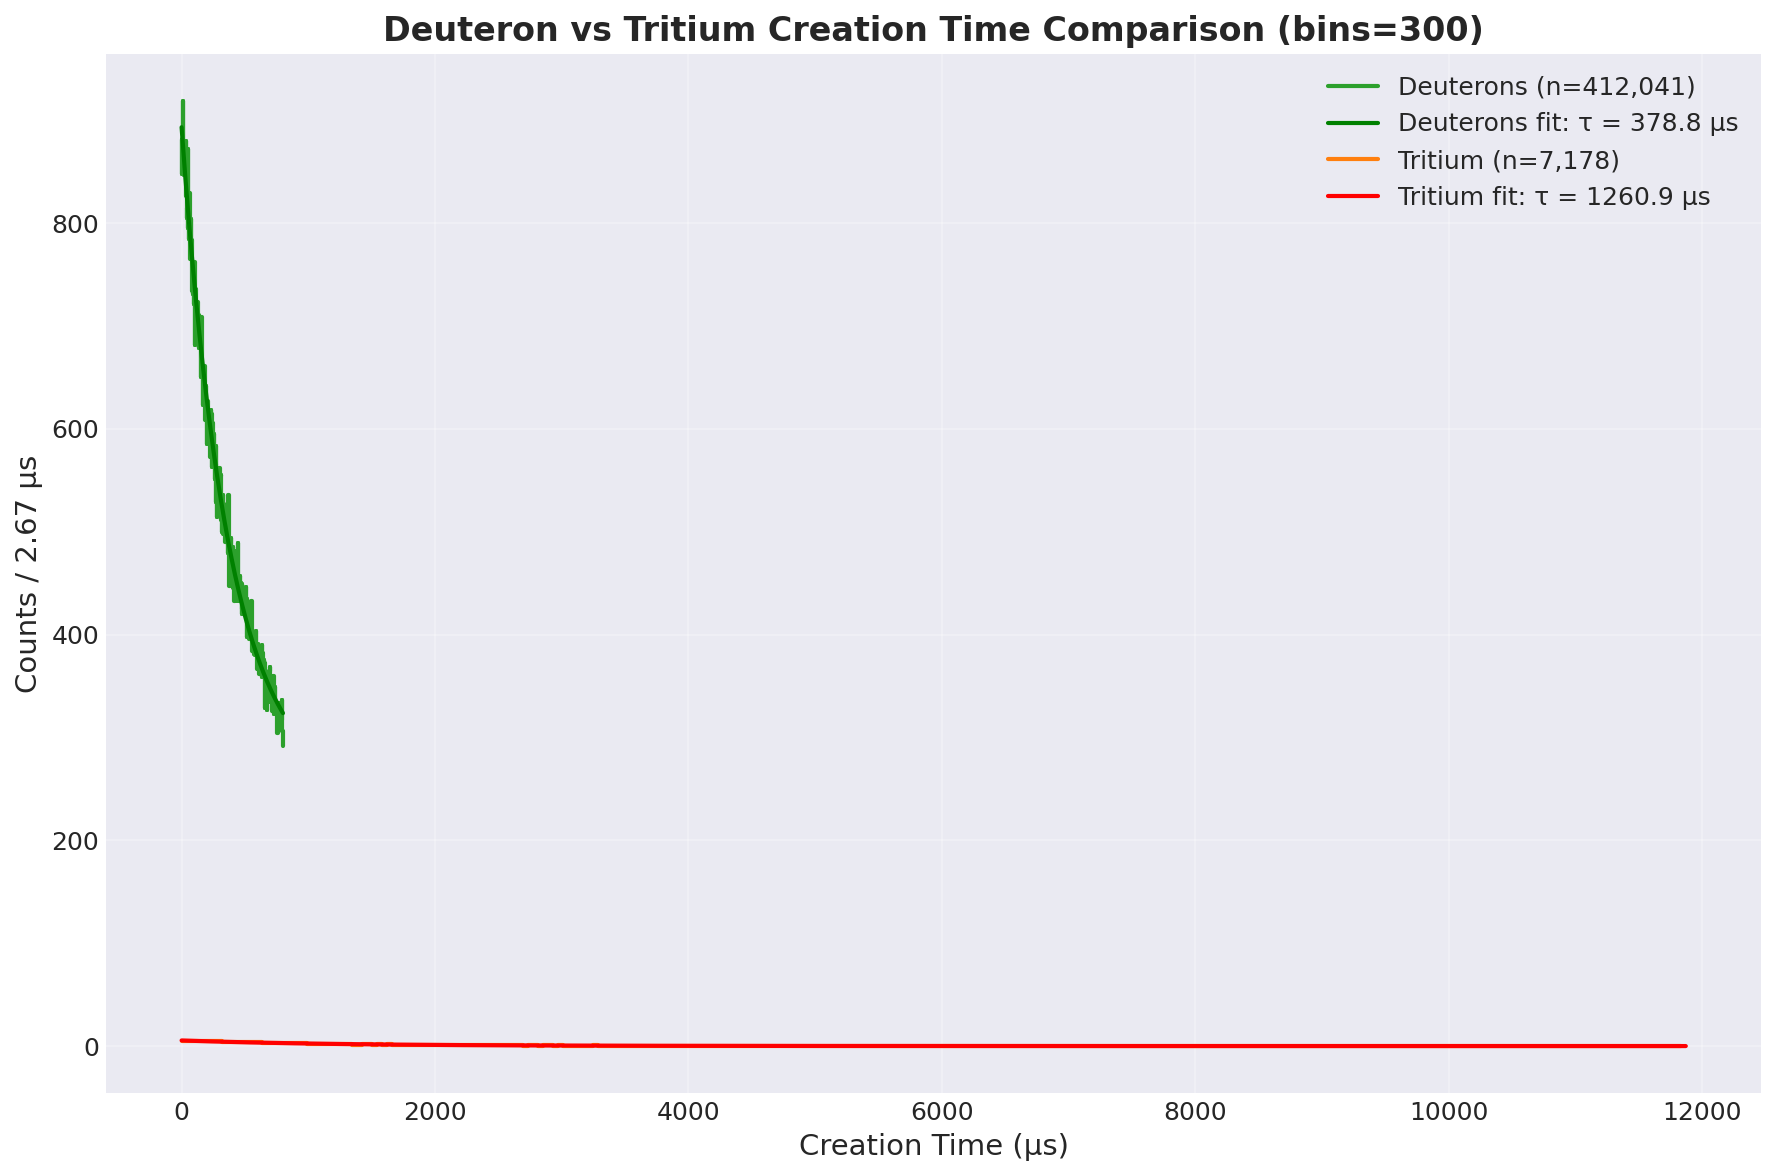

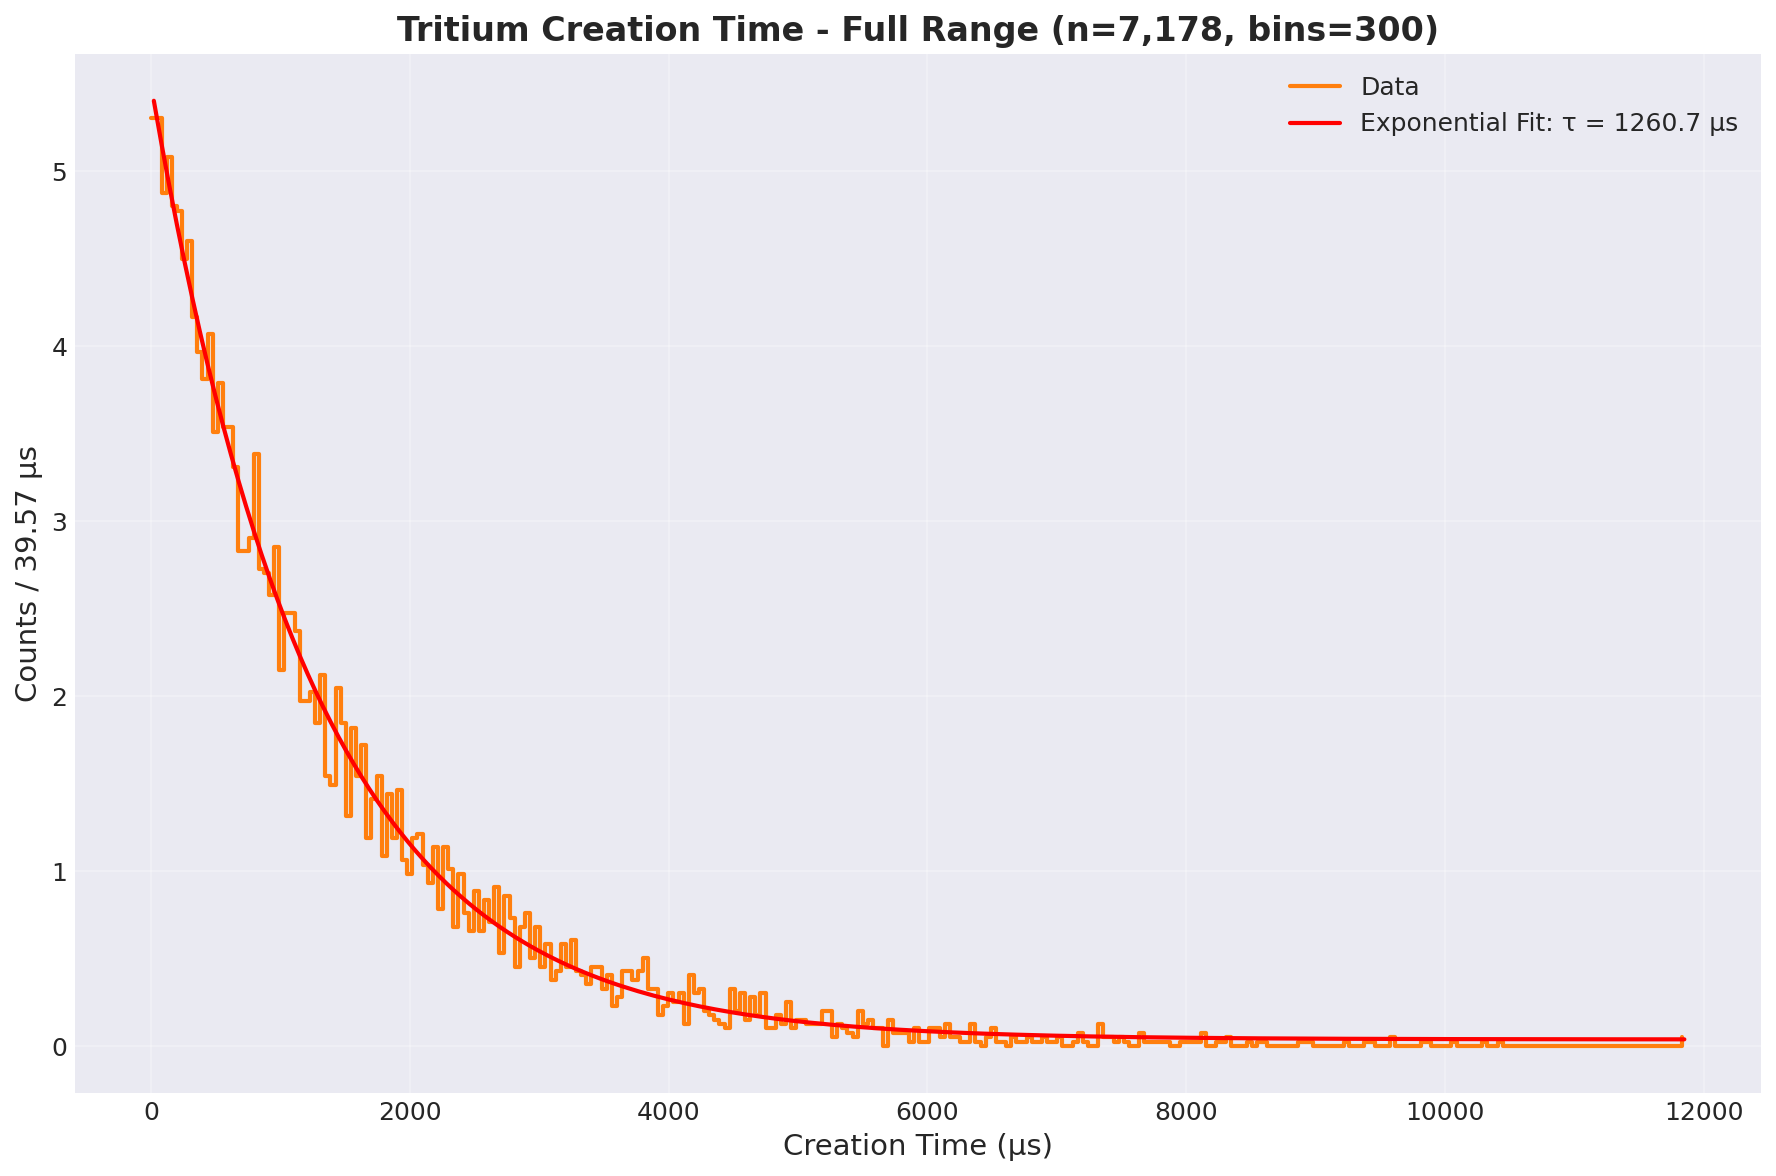


CREATION TIME STATISTICS

Deuterons (821,476 particles):
  Mean time (full range):   1256.34 μs
  Median time (full range): 795.62 μs

  Statistics for 0-800 μs range (n=412041):
    Mean time:   331.10 μs
    Median time: 298.16 μs

Tritium (7,178 particles):
  Mean time (full range):   1370.68 μs
  Median time (full range): 916.73 μs

  Statistics for ≥0 μs range (n=7178):
    Mean time:   1370.68 μs
    Median time: 916.73 μs

SUMMARY TABLE
Metric                                        Value               
-----------------------------------------------------------------
Deuterons (n + H → D + γ)                     821,476
Tritium (n + D → T + γ)                       7,178
Total Capture Products                        828,654
Deuteron Fraction                             99.1%
Tritium Fraction                              0.9%

FILES GENERATED
  - figure_deuteron.png
  - figure_tritium.png
  - figure_deuteron_tritium_overlay.png
  - figure_tritium_full_range.png

ANALYSIS COMPLET

In [20]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
import os
from scipy.optimize import curve_fit

# ============================================================
# CONFIGURATION - ADJUST THESE PARAMETERS
# ============================================================
N_BINS_DEUTERON = 5000      # Number of bins for deuteron plot
N_BINS_TRITIUM = 300        # Number of bins for tritium plot
N_BINS_OVERLAY = 300        # Number of bins for overlay plot
N_BINS_FULL_RANGE = 300     # Number of bins for full range plot
BIN_RANGE_MIN = 0           # Minimum time range for plots
BIN_RANGE_MAX = 800        # Maximum time range for deuteron plots

# ============================================================
# EXPONENTIAL FIT FUNCTION
# ============================================================
def exponential_decay(t, A, tau, C):
    """Exponential decay function: A * exp(-t/tau) + C"""
    return A * np.exp(-t / tau) + C

# ============================================================
# SPECIFY YOUR FILE HERE


if not os.path.exists(path):
    print(f"Error: {path} not found!")
    exit()

file = uproot.open(path)
Sim_Tree = file["Sim_Tree"]
event_data = Sim_Tree["eventData"]
print(f"File opened: {path}")
print(f"Total events: {Sim_Tree.num_entries}")

# ============================================================
# LOAD PARTICLE DATA
# ============================================================
print("\nLoading particle data...")

try:
    all_particle_pdg = event_data["allParticlePDG"].array()
    all_particle_time = event_data["allParticleTime"].array()
    has_all_particles = True
    print("✓ All particles data found")
except Exception as e:
    has_all_particles = False
    print(f"✗ All particles data not found: {e}")
    exit()

# ============================================================
# IDENTIFY DEUTERONS & TRITIUM
# ============================================================
print("\nIdentifying deuterons and tritium...")

all_pdg_flat = ak.to_numpy(ak.flatten(all_particle_pdg))
all_time_flat = ak.to_numpy(ak.flatten(all_particle_time))

# PDG codes
deuteron_pdg = 1000010020
tritium_pdg = 1000010030  # Tritium (not triton)

is_deuteron = (all_pdg_flat == deuteron_pdg)
is_tritium = (all_pdg_flat == tritium_pdg)

n_deuterons = np.sum(is_deuteron)
n_tritium = np.sum(is_tritium)

print(f"Deuterons found: {n_deuterons:,}")
print(f"Tritium found: {n_tritium:,}")

# ============================================================
# FIGURE 1: DEUTERON CREATION TIME
# ============================================================
fig, ax = plt.subplots(figsize=(12, 8))

if n_deuterons > 0:
    deuteron_times_us = all_time_flat[is_deuteron] / 1000
    
    # Define time range for deuterons (start from 16 μs)
    t_min = BIN_RANGE_MIN
    t_max = BIN_RANGE_MAX
    
    mask_plot = (deuteron_times_us >= t_min) & (deuteron_times_us <= t_max)
    deuteron_times_plot = deuteron_times_us[mask_plot]
    
    if len(deuteron_times_plot) > 0:
        # Use configurable number of bins
        hist, bin_edges = np.histogram(deuteron_times_plot, bins=N_BINS_DEUTERON, range=(t_min, t_max))
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        bin_width = bin_edges[1] - bin_edges[0]
        
        # Normalize by bin width to get counts per μs
        hist_norm = hist / bin_width
        
        # Plot as step histogram (stair-step line)
        ax.step(bin_edges[:-1], hist_norm, where='post', color='#2ca02c', linewidth=2, label='Data')
        
        # Fit exponential decay (fit to normalized data)
        mask_fit = hist > 0
        bin_centers_fit = bin_centers[mask_fit]
        hist_fit = hist[mask_fit] / bin_width  # Normalize fit data
        
        if len(bin_centers_fit) > 3:
            try:
                p0 = [max(hist_fit), 100, 0]
                popt, _ = curve_fit(exponential_decay, bin_centers_fit, hist_fit, p0=p0, maxfev=5000)
                x_fit = np.linspace(t_min, t_max, 200)
                y_fit = exponential_decay(x_fit, *popt)
                ax.plot(x_fit, y_fit, 'r-', linewidth=2, 
                        label=f'Exponential Fit: τ = {popt[1]:.1f} μs')
                
                print(f"\nDeuteron exponential fit (range: {t_min}-{t_max} μs):")
                print(f"  A = {popt[0]:.1f}, τ = {popt[1]:.1f} μs, C = {popt[2]:.1f}")
            except Exception as e:
                print(f"Fit failed for deuterons: {e}")
        
        ax.set_xlabel('Creation Time (μs)', fontsize=14)
        ax.set_ylabel(f'Counts / {bin_width:.2f} μs', fontsize=14)
        ax.set_title(f'Deuteron Creation Time (n={len(deuteron_times_plot):,})', 
                     fontsize=16, fontweight='bold')
        ax.set_xlim(t_min, t_max)
        ax.legend(fontsize=12)
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, f'No Deuterons in {t_min}-{t_max} μs range', 
                transform=ax.transAxes, ha='center', va='center', fontsize=14)
else:
    ax.text(0.5, 0.5, 'No Deuterons Found', transform=ax.transAxes, ha='center', va='center', fontsize=14)

plt.tight_layout()
plt.savefig('figure_deuteron.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# FIGURE 2: TRITIUM CREATION TIME
# ============================================================
fig, ax = plt.subplots(figsize=(12, 8))

if n_tritium > 0:
    tritium_times_us = all_time_flat[is_tritium] / 1000
    
    # Define time range for tritium (start from 16 μs)
    t_min = BIN_RANGE_MIN
    t_max = np.max(tritium_times_us)
    
    mask_plot = (tritium_times_us >= t_min)
    tritium_times_plot = tritium_times_us[mask_plot]
    
    if len(tritium_times_plot) > 0:
        # Use configurable number of bins
        hist, bin_edges = np.histogram(tritium_times_plot, bins=N_BINS_TRITIUM, range=(t_min, t_max))
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        bin_width = bin_edges[1] - bin_edges[0]
        
        # Normalize by bin width to get counts per μs
        hist_norm = hist / bin_width
        
        # Plot as step histogram (stair-step line)
        ax.step(bin_edges[:-1], hist_norm, where='post', color='#ff7f0e', linewidth=2, label='Data')
        
        # Fit exponential decay (fit to normalized data)
        mask_fit = hist > 0
        bin_centers_fit = bin_centers[mask_fit]
        hist_fit = hist[mask_fit] / bin_width  # Normalize fit data
    
        if len(bin_centers_fit) > 3:
            try:
                p0 = [max(hist_fit), np.mean(tritium_times_plot), 0]
                popt, _ = curve_fit(exponential_decay, bin_centers_fit, hist_fit, p0=p0, maxfev=5000)
                x_fit = np.linspace(t_min, t_max, 200)
                y_fit = exponential_decay(x_fit, *popt)
                ax.plot(x_fit, y_fit, 'r-', linewidth=2, 
                        label=f'Exponential Fit: τ = {popt[1]:.1f} μs')
                
                print(f"\nTritium exponential fit (range: {t_min}-{t_max:.0f} μs):")
                print(f"  A = {popt[0]:.1f}, τ = {popt[1]:.1f} μs, C = {popt[2]:.1f}")
            except Exception as e:
                print(f"Fit failed for tritium: {e}")
        
        ax.set_xlabel('Creation Time (μs)', fontsize=14)
        ax.set_ylabel(f'Counts / {bin_width:.2f} μs', fontsize=14)
        ax.set_title(f'Tritium Creation Time (n={len(tritium_times_plot):,})', 
                     fontsize=16, fontweight='bold')
        ax.set_xlim(t_min, t_max)
        ax.legend(fontsize=12)
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, f'No Tritium above {t_min} μs', 
                transform=ax.transAxes, ha='center', va='center', fontsize=14)
else:
    ax.text(0.5, 0.5, 'No Tritium Found', transform=ax.transAxes, ha='center', va='center', fontsize=14)

plt.tight_layout()
plt.savefig('figure_tritium.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# FIGURE 3: DEUTERON VS TRITIUM OVERLAY
# ============================================================
fig, ax = plt.subplots(figsize=(12, 8))

# Deuterons (16-1000 μs)
if n_deuterons > 0:
    deuteron_times_us = all_time_flat[is_deuteron] / 1000
    t_min_d = BIN_RANGE_MIN
    t_max_d = BIN_RANGE_MAX
    mask_d = (deuteron_times_us >= t_min_d) & (deuteron_times_us <= t_max_d)
    deuteron_times_plot = deuteron_times_us[mask_d]
    
    if len(deuteron_times_plot) > 0:
        hist_d, bin_edges_d = np.histogram(deuteron_times_plot, bins=N_BINS_OVERLAY, range=(t_min_d, t_max_d))
        bin_width_d = bin_edges_d[1] - bin_edges_d[0]
        hist_d_norm = hist_d / bin_width_d
        
        # Plot as step histogram (stair-step line)
        ax.step(bin_edges_d[:-1], hist_d_norm, where='post', color='#2ca02c', linewidth=2, 
                label=f'Deuterons (n={len(deuteron_times_plot):,})')
        
        # Fit for deuterons
        mask_fit_d = hist_d > 0
        bin_centers_fit_d = (bin_edges_d[:-1] + bin_edges_d[1:])[mask_fit_d] / 2
        hist_fit_d = hist_d[mask_fit_d] / bin_width_d
        
        if len(bin_centers_fit_d) > 3:
            try:
                p0 = [max(hist_fit_d), 100, 0]
                popt_d, _ = curve_fit(exponential_decay, bin_centers_fit_d, hist_fit_d, p0=p0, maxfev=5000)
                x_fit = np.linspace(t_min_d, t_max_d, 200)
                y_fit = exponential_decay(x_fit, *popt_d)
                ax.plot(x_fit, y_fit, 'g-', linewidth=2, 
                        label=f'Deuterons fit: τ = {popt_d[1]:.1f} μs')
            except:
                pass

# Tritium (16 μs to max)
if n_tritium > 0:
    tritium_times_us = all_time_flat[is_tritium] / 1000
    t_min_t = BIN_RANGE_MIN
    mask_t = (tritium_times_us >= t_min_t)
    tritium_times_plot = tritium_times_us[mask_t]
    
    if len(tritium_times_plot) > 0:
        t_max_t = np.max(tritium_times_plot)
        hist_t, bin_edges_t = np.histogram(tritium_times_plot, bins=N_BINS_OVERLAY, range=(t_min_t, t_max_t))
        bin_width_t = bin_edges_t[1] - bin_edges_t[0]
        hist_t_norm = hist_t / bin_width_t
        
        # Plot as step histogram (stair-step line)
        ax.step(bin_edges_t[:-1], hist_t_norm, where='post', color='#ff7f0e', linewidth=2, 
                label=f'Tritium (n={len(tritium_times_plot):,})')
        
        # Fit for tritium
        mask_fit_t = hist_t > 0
        bin_centers_fit_t = (bin_edges_t[:-1] + bin_edges_t[1:])[mask_fit_t] / 2
        hist_fit_t = hist_t[mask_fit_t] / bin_width_t
        
        if len(bin_centers_fit_t) > 3:
            try:
                p0 = [max(hist_fit_t), np.mean(tritium_times_plot), 0]
                popt_t, _ = curve_fit(exponential_decay, bin_centers_fit_t, hist_fit_t, p0=p0, maxfev=5000)
                x_fit = np.linspace(t_min_t, t_max_t, 200)
                y_fit = exponential_decay(x_fit, *popt_t)
                ax.plot(x_fit, y_fit, 'r-', linewidth=2, 
                        label=f'Tritium fit: τ = {popt_t[1]:.1f} μs')
            except:
                pass

ax.set_xlabel('Creation Time (μs)', fontsize=14)
ax.set_ylabel(f'Counts / {bin_width_d:.2f} μs', fontsize=14)
ax.set_title(f'Deuteron vs Tritium Creation Time Comparison (bins={N_BINS_OVERLAY})', 
             fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figure_deuteron_tritium_overlay.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# FIGURE 4: TRITIUM CREATION TIME - FULL RANGE
# ============================================================
if n_tritium > 0:
    fig, ax = plt.subplots(figsize=(12, 8))
    
    tritium_times_us = all_time_flat[is_tritium] / 1000
    
    # Use configurable number of bins for full range
    hist, bin_edges = np.histogram(tritium_times_us, bins=N_BINS_FULL_RANGE)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = bin_edges[1] - bin_edges[0]
    
    # Normalize by bin width to get counts per μs
    hist_norm = hist / bin_width
    
    # Plot as step histogram (stair-step line)
    ax.step(bin_edges[:-1], hist_norm, where='post', color='#ff7f0e', linewidth=2, label='Data')
    
    # Fit exponential decay (fit to normalized data)
    mask_fit = hist > 0
    bin_centers_fit = bin_centers[mask_fit]
    hist_fit = hist[mask_fit] / bin_width  # Normalize fit data
    
    if len(bin_centers_fit) > 3:
        try:
            p0 = [max(hist_fit), np.mean(tritium_times_us), 0]
            popt, _ = curve_fit(exponential_decay, bin_centers_fit, hist_fit, p0=p0, maxfev=5000)
            x_fit = np.linspace(min(bin_centers), max(bin_centers), 200)
            y_fit = exponential_decay(x_fit, *popt)
            ax.plot(x_fit, y_fit, 'r-', linewidth=2, 
                    label=f'Exponential Fit: τ = {popt[1]:.1f} μs')
        except:
            pass
    
    ax.set_xlabel('Creation Time (μs)', fontsize=14)
    ax.set_ylabel(f'Counts / {bin_width:.2f} μs', fontsize=14)
    ax.set_title(f'Tritium Creation Time - Full Range (n={n_tritium:,}, bins={N_BINS_FULL_RANGE})', 
                 fontsize=16, fontweight='bold')
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('figure_tritium_full_range.png', dpi=300, bbox_inches='tight')
    plt.show()

# ============================================================
# STATISTICS SUMMARY
# ============================================================
print("\n" + "="*80)
print("CREATION TIME STATISTICS")
print("="*80)

if n_deuterons > 0:
    deuteron_times_us = all_time_flat[is_deuteron] / 1000
    print(f"\nDeuterons ({n_deuterons:,} particles):")
    print(f"  Mean time (full range):   {np.mean(deuteron_times_us):.2f} μs")
    print(f"  Median time (full range): {np.median(deuteron_times_us):.2f} μs")
    
    mask_range = (deuteron_times_us >= BIN_RANGE_MIN) & (deuteron_times_us <= BIN_RANGE_MAX)
    if np.sum(mask_range) > 0:
        range_times = deuteron_times_us[mask_range]
        print(f"\n  Statistics for {BIN_RANGE_MIN}-{BIN_RANGE_MAX} μs range (n={len(range_times)}):")
        print(f"    Mean time:   {np.mean(range_times):.2f} μs")
        print(f"    Median time: {np.median(range_times):.2f} μs")

if n_tritium > 0:
    tritium_times_us = all_time_flat[is_tritium] / 1000
    print(f"\nTritium ({n_tritium:,} particles):")
    print(f"  Mean time (full range):   {np.mean(tritium_times_us):.2f} μs")
    print(f"  Median time (full range): {np.median(tritium_times_us):.2f} μs")
    
    # Statistics for times >= BIN_RANGE_MIN
    mask_range = (tritium_times_us >= BIN_RANGE_MIN)
    if np.sum(mask_range) > 0:
        range_times = tritium_times_us[mask_range]
        print(f"\n  Statistics for ≥{BIN_RANGE_MIN} μs range (n={len(range_times)}):")
        print(f"    Mean time:   {np.mean(range_times):.2f} μs")
        print(f"    Median time: {np.median(range_times):.2f} μs")

else:
    print("\n" + "="*80)
    print("NO DEUTERONS OR TRITIUM FOUND")
    print("="*80)

# ============================================================
# SUMMARY TABLE
# ============================================================
print("\n" + "="*80)
print("SUMMARY TABLE")
print("="*80)
print(f"{'Metric':<45} {'Value':<20}")
print("-"*65)
print(f"{'Deuterons (n + H → D + γ)':<45} {n_deuterons:,}")
print(f"{'Tritium (n + D → T + γ)':<45} {n_tritium:,}")
print(f"{'Total Capture Products':<45} {n_deuterons + n_tritium:,}")

if n_deuterons + n_tritium > 0:
    print(f"{'Deuteron Fraction':<45} {100 * n_deuterons / (n_deuterons + n_tritium):.1f}%")
    print(f"{'Tritium Fraction':<45} {100 * n_tritium / (n_deuterons + n_tritium):.1f}%")

print("\n" + "="*80)
print("FILES GENERATED")
print("="*80)
if n_deuterons > 0 or n_tritium > 0:
    print("  - figure_deuteron.png")
    print("  - figure_tritium.png")
    print("  - figure_deuteron_tritium_overlay.png")
    if n_tritium > 0:
        print("  - figure_tritium_full_range.png")
else:
    print("  No plots generated (no deuterons or tritium found)")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)

In [8]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import awkward as ak
import os
from matplotlib.patches import Circle
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("Libraries imported successfully")

# ============================================================
# SPECIFY YOUR FILE HERE
# ============================================================
 # Change this to your file name

# ============================================================
# Check if file exists and open
# ============================================================
if not os.path.exists(path):
    print(f"Error: {path} not found!")
    print("\nAvailable ROOT files in current directory:")
    for f in os.listdir('.'):
        if f.endswith('.root'):
            print(f"  - {f}")
else:
    file = uproot.open(path)
    print(f"File opened successfully: {path}")
    print(f"File size: {os.path.getsize(path) / 1024 / 1024:.2f} MB")

# ============================================================
# 1. PRINT ALL AVAILABLE TREES IN ROOT FILE
# ============================================================
if os.path.exists(path):
    print("\n" + "="*60)
    print("ALL AVAILABLE TREES IN ROOT FILE")
    print("="*60)
    
    # Print all top-level keys
    print("\nTop-level objects in file:")
    for key in file.keys():
        obj = file[key]
        if 'TTree' in str(type(obj)):
            print(f"  🌲 {key} (TTree) - {obj.num_entries} entries")
        elif hasattr(obj, 'keys'):
            print(f"  📁 {key} (directory)")
        else:
            print(f"  📄 {key}")
    
    # Open the main tree
    if "Sim_Tree" in file:
        Sim_Tree = file["Sim_Tree"]
        print(f"\n✓ Main tree 'Sim_Tree' opened - {Sim_Tree.num_entries} entries")
    else:
        print(f"\n⚠️ 'Sim_Tree' not found")
        Sim_Tree = None

# ============================================================
# 2. PRINT ALL BRANCHES IN Sim_Tree (TOP LEVEL)
# ============================================================
if os.path.exists(path) and Sim_Tree is not None:
    print("\n" + "="*60)
    print("ALL BRANCHES IN Sim_Tree (Top Level)")
    print("="*60)
    
    for key in Sim_Tree.keys():
        print(f"  - {key}")
    
    print(f"\nTotal top-level branches: {len(Sim_Tree.keys())}")

# ============================================================
# 3. PRINT ALL BRANCHES INSIDE eventData
# ============================================================
if os.path.exists(path) and Sim_Tree is not None:
    print("\n" + "="*60)
    print("ALL BRANCHES INSIDE eventData")
    print("="*60)
    
    if "eventData" in Sim_Tree:
        # Access eventData as a branch
        eventData_branch = Sim_Tree["eventData"]
        
        # Show what's inside eventData
        print("\nContents of eventData:")
        if hasattr(eventData_branch, 'keys'):
            for key in eventData_branch.keys():
                print(f"  - {key}")
            print(f"\nTotal eventData branches: {len(eventData_branch.keys())}")
        else:
            print("  eventData is not a directory structure")
            print(f"  Type: {type(eventData_branch)}")
    else:
        print("eventData not found in Sim_Tree")

# ============================================================
# 4. PRINT ALL BRANCHES WITH FULL PATHS
# ============================================================
if os.path.exists(path) and Sim_Tree is not None:
    print("\n" + "="*60)
    print("ALL BRANCHES WITH FULL PATHS")
    print("="*60)
    
    def print_all_branches(tree, prefix=""):
        branches = []
        for key in tree.keys():
            full_path = f"{prefix}{key}" if prefix else key
            try:
                # Try to access as a branch
                test = tree[key].array(library='np', entry_stop=1)
                branches.append(full_path)
                print(f"  - {full_path}")
            except:
                # Might be a sub-structure
                print(f"  📁 {full_path}/")
                try:
                    sub_branches = print_all_branches(tree[key], f"{full_path}/")
                    branches.extend(sub_branches)
                except:
                    pass
        return branches
    
    all_branches = print_all_branches(Sim_Tree)
    print(f"\nTotal branches found: {len(all_branches)}")

# ============================================================
# 5. CATEGORIZE ALL BRANCHES
# ============================================================
if os.path.exists(path) and Sim_Tree is not None:
    print("\n" + "="*60)
    print("BRANCH CATEGORIES")
    print("="*60)
    
    # Get all branch names
    def get_all_branch_names(tree, prefix=""):
        branches = []
        for key in tree.keys():
            full_path = f"{prefix}{key}" if prefix else key
            try:
                tree[key].array(library='np', entry_stop=1)
                branches.append(full_path)
            except:
                try:
                    sub_branches = get_all_branch_names(tree[key], f"{full_path}/")
                    branches.extend(sub_branches)
                except:
                    pass
        return branches
    
    all_branch_names = get_all_branch_names(Sim_Tree)
    
    # Categorize
    pmt_branches = [b for b in all_branch_names if 'pmt' in b.lower() or 'hit' in b.lower()]
    capture_branches = [b for b in all_branch_names if 'capture' in b.lower() or 'neutron' in b.lower()]
    step_branches = [b for b in all_branch_names if 'step' in b.lower()]
    pos_branches = [b for b in all_branch_names if 'pos' in b.lower() or 'position' in b.lower()]
    energy_branches = [b for b in all_branch_names if 'energy' in b.lower() or 'ke' in b.lower()]
    time_branches = [b for b in all_branch_names if 'time' in b.lower()]
    
    print(f"\n📈 PMT/Hit branches ({len(pmt_branches)}):")
    for b in pmt_branches[:20]:
        print(f"    - {b}")
    if len(pmt_branches) > 20:
        print(f"    ... and {len(pmt_branches)-20} more")
    
    print(f"\n🔬 Neutron/Capture branches ({len(capture_branches)}):")
    for b in capture_branches:
        print(f"    - {b}")
    
    print(f"\n👣 Step data branches ({len(step_branches)}):")
    for b in step_branches:
        print(f"    - {b}")
    
    print(f"\n📍 Position branches ({len(pos_branches)}):")
    for b in pos_branches[:10]:
        print(f"    - {b}")
    
    print(f"\n⚡ Energy branches ({len(energy_branches)}):")
    for b in energy_branches[:10]:
        print(f"    - {b}")
    
    print(f"\n⏰ Time branches ({len(time_branches)}):")
    for b in time_branches[:10]:
        print(f"    - {b}")

# ============================================================
# 6. PRINT SAMPLE DATA FROM EACH BRANCH
# ============================================================
if os.path.exists(path) and Sim_Tree is not None:
    print("\n" + "="*60)
    print("SAMPLE DATA FROM EACH BRANCH (first 3 events)")
    print("="*60)
    
    all_branch_names = get_all_branch_names(Sim_Tree)
    
    for branch in all_branch_names[:30]:  # Limit to first 30 to avoid too much output
        try:
            data = Sim_Tree[branch].array(library='np', entry_stop=3)
            print(f"\n📊 {branch}:")
            print(f"   Shape: {data.shape if hasattr(data, 'shape') else 'N/A'}")
            print(f"   Type: {type(data)}")
            
            if len(data) > 0:
                if hasattr(data, 'dtype'):
                    if 'float' in str(data.dtype) or 'int' in str(data.dtype):
                        print(f"   First 3 values: {data[:3]}")
                    else:
                        print(f"   First 3 values: {data[:3]}")
                else:
                    print(f"   First 3 values: {data[:3]}")
        except Exception as e:
            print(f"\n📊 {branch}:")
            print(f"   Error: {e}")

# ============================================================
# 7. CHECK FOR STEP DATA AVAILABILITY
# ============================================================
if os.path.exists(path) and Sim_Tree is not None:
    print("\n" + "="*60)
    print("STEP DATA AVAILABILITY CHECK")
    print("="*60)
    
    step_branches = ['stepTrackID', 'stepPDG', 'stepProcessID', 'stepPosX', 'stepPosY', 'stepPosZ', 
                     'stepKineticEnergy', 'stepGlobalTime', 'stepEnergyDeposit', 'stepLength',
                     'stepNumber', 'stepVolumeCopy', 'stepParentID']
    
    step_data_available = {}
    for branch in step_branches:
        full_branch = f"eventData/{branch}"
        try:
            test = Sim_Tree[full_branch].array(library='np', entry_stop=1)
            step_data_available[branch] = True
        except:
            step_data_available[branch] = False
    
    print("\nStep data availability:")
    for branch in step_branches:
        print(f"  {'✓' if step_data_available.get(branch, False) else '✗'} {branch}")
    
    if any(step_data_available.values()):
        print("\n✓ Step data is available in this file!")
        
        # Show sample step data size
        for branch in step_branches:
            if step_data_available.get(branch, False):
                data = Sim_Tree[f"eventData/{branch}"].array(library='np')
                print(f"\nSample {branch}: {len(data)} events, first event has {len(data[0]) if len(data) > 0 else 0} steps")
                break
    else:
        print("\n✗ No step data available in this file.")
        print("  (Step recorder may not have been enabled during simulation)")

# ============================================================
# 8. LOAD BASIC EVENT DATA
# ============================================================
if os.path.exists(path) and Sim_Tree is not None:
    print("\n" + "="*60)
    print("LOADING BASIC EVENT DATA")
    print("="*60)
    
    # Get number of events
    n_events = Sim_Tree.num_entries
    print(f"\nNumber of events: {n_events}")
    
    # Check what neutron capture branches exist
    capture_branches = ['neutronCaptureDetected', 'neutronCaptureOnHydrogen', 'neutronCaptureOnDeuterium',
                        'neutronCaptureTime', 'neutronCaptureGammaEnergy', 'neutronCaptureVolume',
                        'neutronCapturePosX', 'neutronCapturePosY', 'neutronCapturePosZ',
                        'neutronCaptureProduct', 'neutronCaptureProductEnergy', 'neutronCaptureNHits']
    
    print("\nNeutron capture branches found:")
    for branch in capture_branches:
        full_branch = f"eventData/{branch}"
        try:
            test = Sim_Tree[full_branch].array(library='np', entry_stop=1)
            print(f"  ✓ {branch}")
        except:
            print(f"  ✗ {branch}")

# ============================================================
# 9. PRINT PMT HIT STRUCTURE
# ============================================================
if os.path.exists(path) and Sim_Tree is not None:
    print("\n" + "="*60)
    print("PMT HIT STRUCTURE")
    print("="*60)
    
    try:
        pmt_hits = Sim_Tree["eventData/pmtHits"].array()
        
        print(f"\nPMT hits object type: {type(pmt_hits)}")
        print(f"Number of events: {len(pmt_hits)}")
        
        # Show available fields
        if hasattr(pmt_hits, 'fields'):
            print(f"\nAvailable fields in pmtHits:")
            for field in pmt_hits.fields:
                print(f"  - {field}")
        
        # Show first event sample
        print(f"\nFirst event sample:")
        if len(pmt_hits) > 0:
            first_event = pmt_hits[0]
            print(f"  Number of hits: {len(first_event)}")
            if hasattr(first_event, 'fields'):
                for field in first_event.fields:
                    values = first_event[field][:5]
                    print(f"  {field}: {values}")
    except Exception as e:
        print(f"Error reading PMT hits: {e}")

print("\n" + "="*60)
print("INITIALIZATION COMPLETE - READY FOR ANALYSIS")
print("="*60)

Libraries imported successfully
File opened successfully: Sim_D2ODetector007.root
File size: 1057.71 MB

ALL AVAILABLE TREES IN ROOT FILE

Top-level objects in file:
  📄 beamOn.dat;1
  🌲 Sim_Tree;36 (TTree) - 100000 entries
  🌲 Setup_Tree;1 (TTree) - 1 entries
  📁 histos;1 (directory)
  📄 histos/pmtHits;1
  📄 histos/pmtNumVsTime;1
  📄 histos/photonEnergy;1
  📄 histos/photonsPerEvent;1
  📁 pmtPositions;1 (directory)
  📄 pmtPositions/pmtPosX;1
  📄 pmtPositions/pmtPosY;1
  📄 pmtPositions/pmtPosZ;1

✓ Main tree 'Sim_Tree' opened - 100000 entries

ALL BRANCHES IN Sim_Tree (Top Level)
  - eventData
  - eventData/TObject
  - eventData/TObject/fUniqueID
  - eventData/TObject/fBits
  - eventData/narrow_veto_edep[4]
  - eventData/wide_veto_edep[4]
  - eventData/eventNumber
  - eventData/direction0
  - eventData/position0
  - eventData/vol0
  - eventData/veto_tag
  - eventData/veto_edep
  - eventData/sourceParticleEnergy
  - eventData/numHits
  - eventData/numHitsArea
  - eventData/muVetoEnergy[1

Libraries imported successfully
File opened: Sim_D2ODetector007.root
Total events: 100000

Loading data...
✓ All particles data found
✗ Neutron capture data not found

Data loading complete

Applying quality cuts to PMT hits...
Events before cuts: 100000
Events after cuts: 43851
Total detected photons: 1006982

PARTICLE STATISTICS
Total particles created (all): 28,606,809
Primary particles (parentID=0): 100,000
Secondary particles (parentID>0): 28,506,809
Secondary fraction: 99.7%

--------------------------------------------------------------------------------
SECONDARY PARTICLES (Grouped by Type) - Sorted by count
--------------------------------------------------------------------------------
Particle Type                       Count        Percentage
--------------------------------------------------------------------------------
Electrons (e⁻)                      14,723,023   51.65     % █████████████████████████
Unknown (PDG -22)                   8,692,223    30.49     % ██████

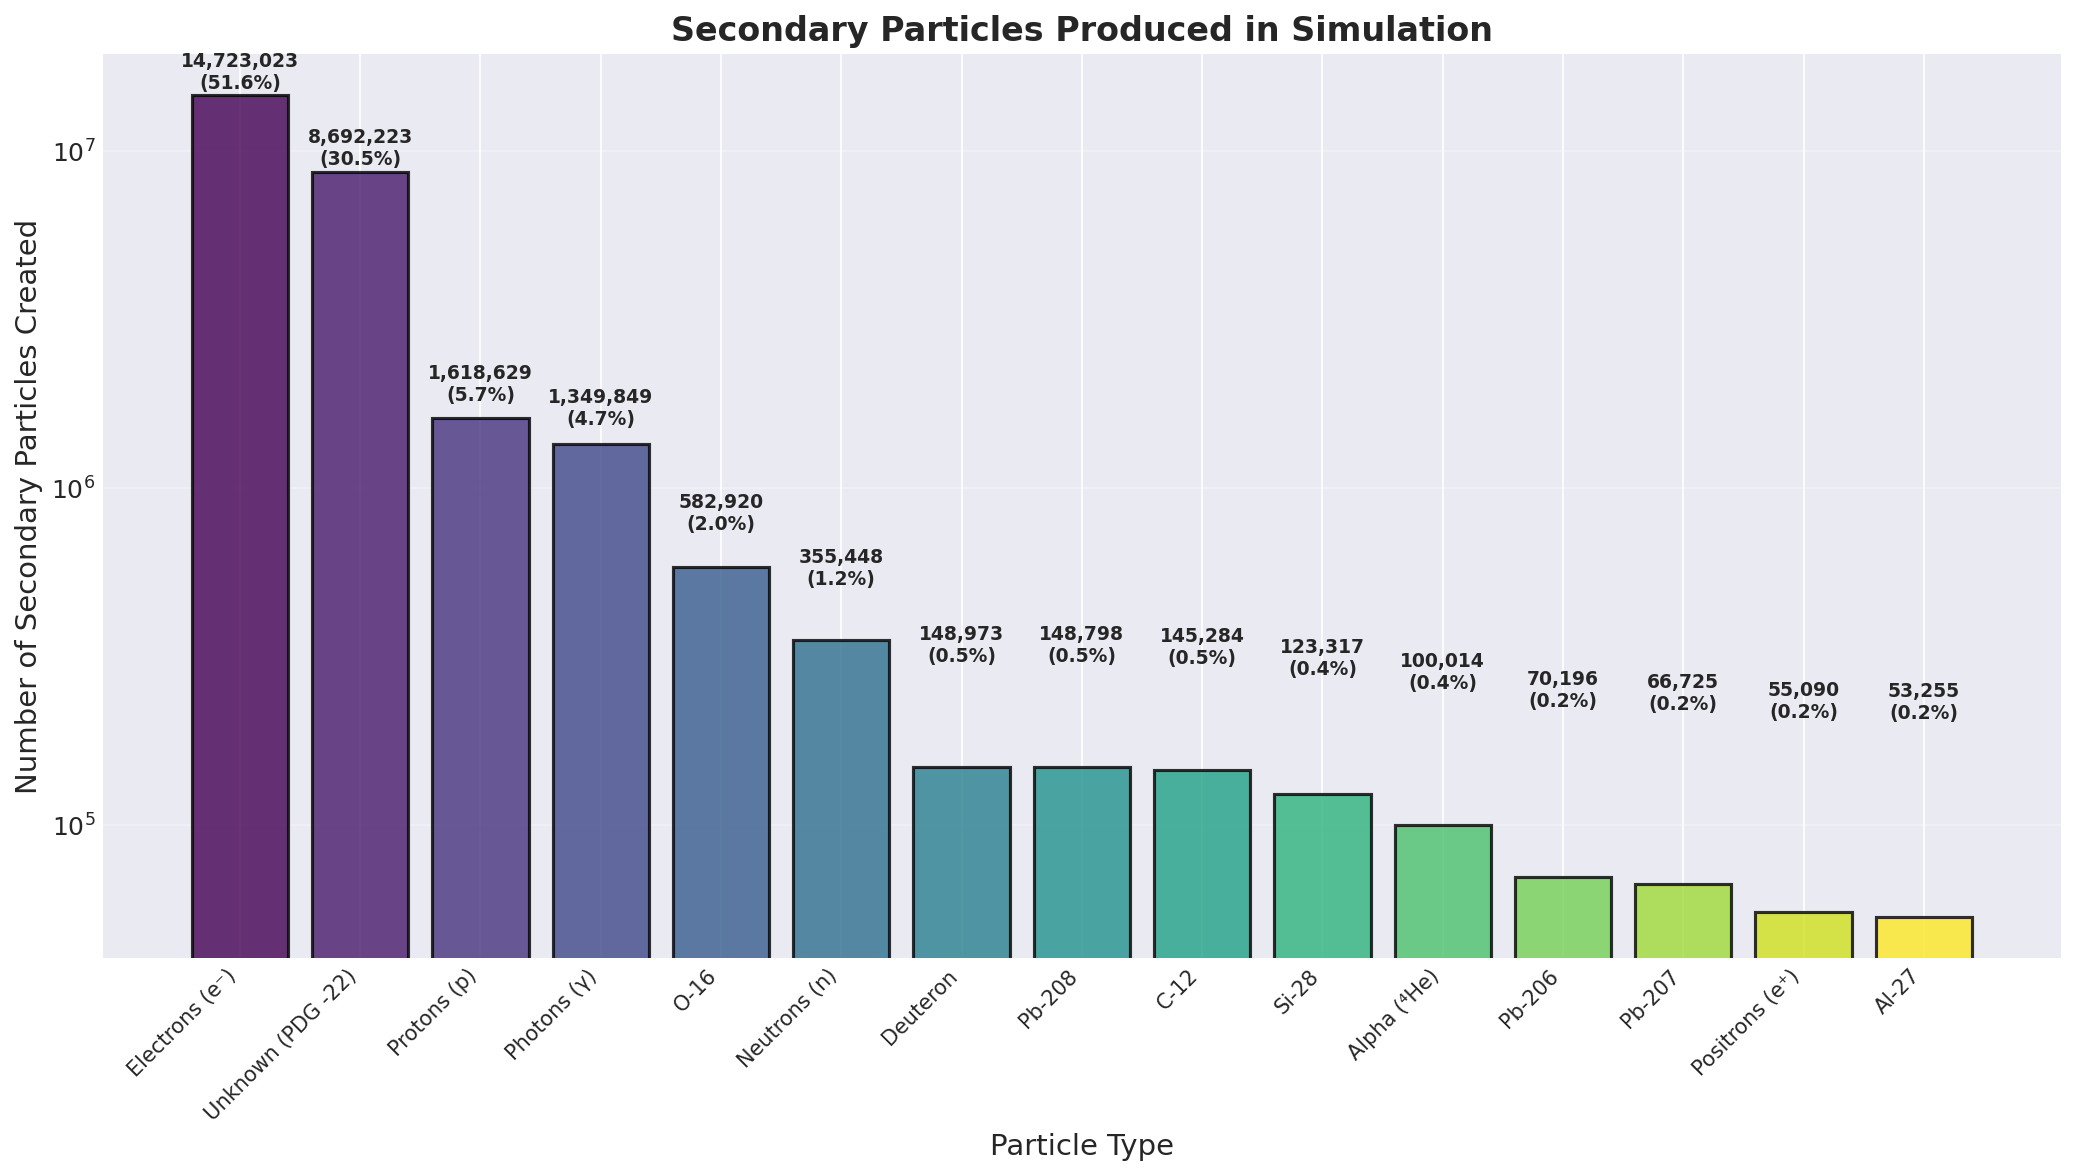

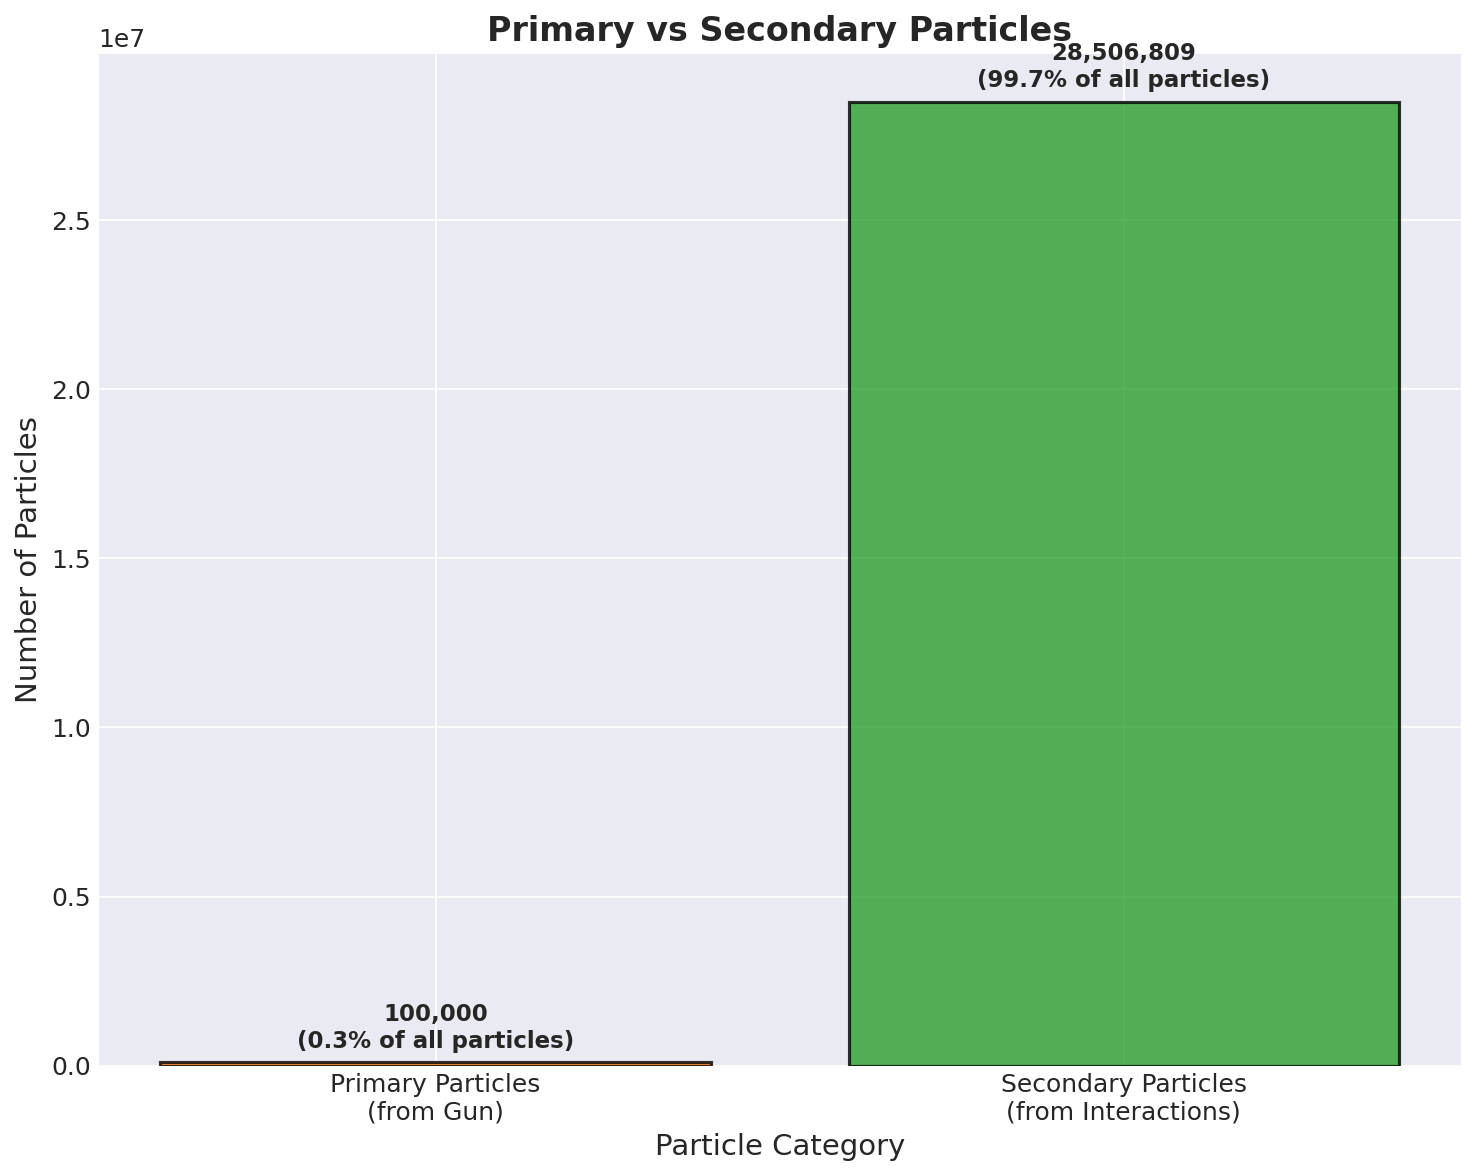

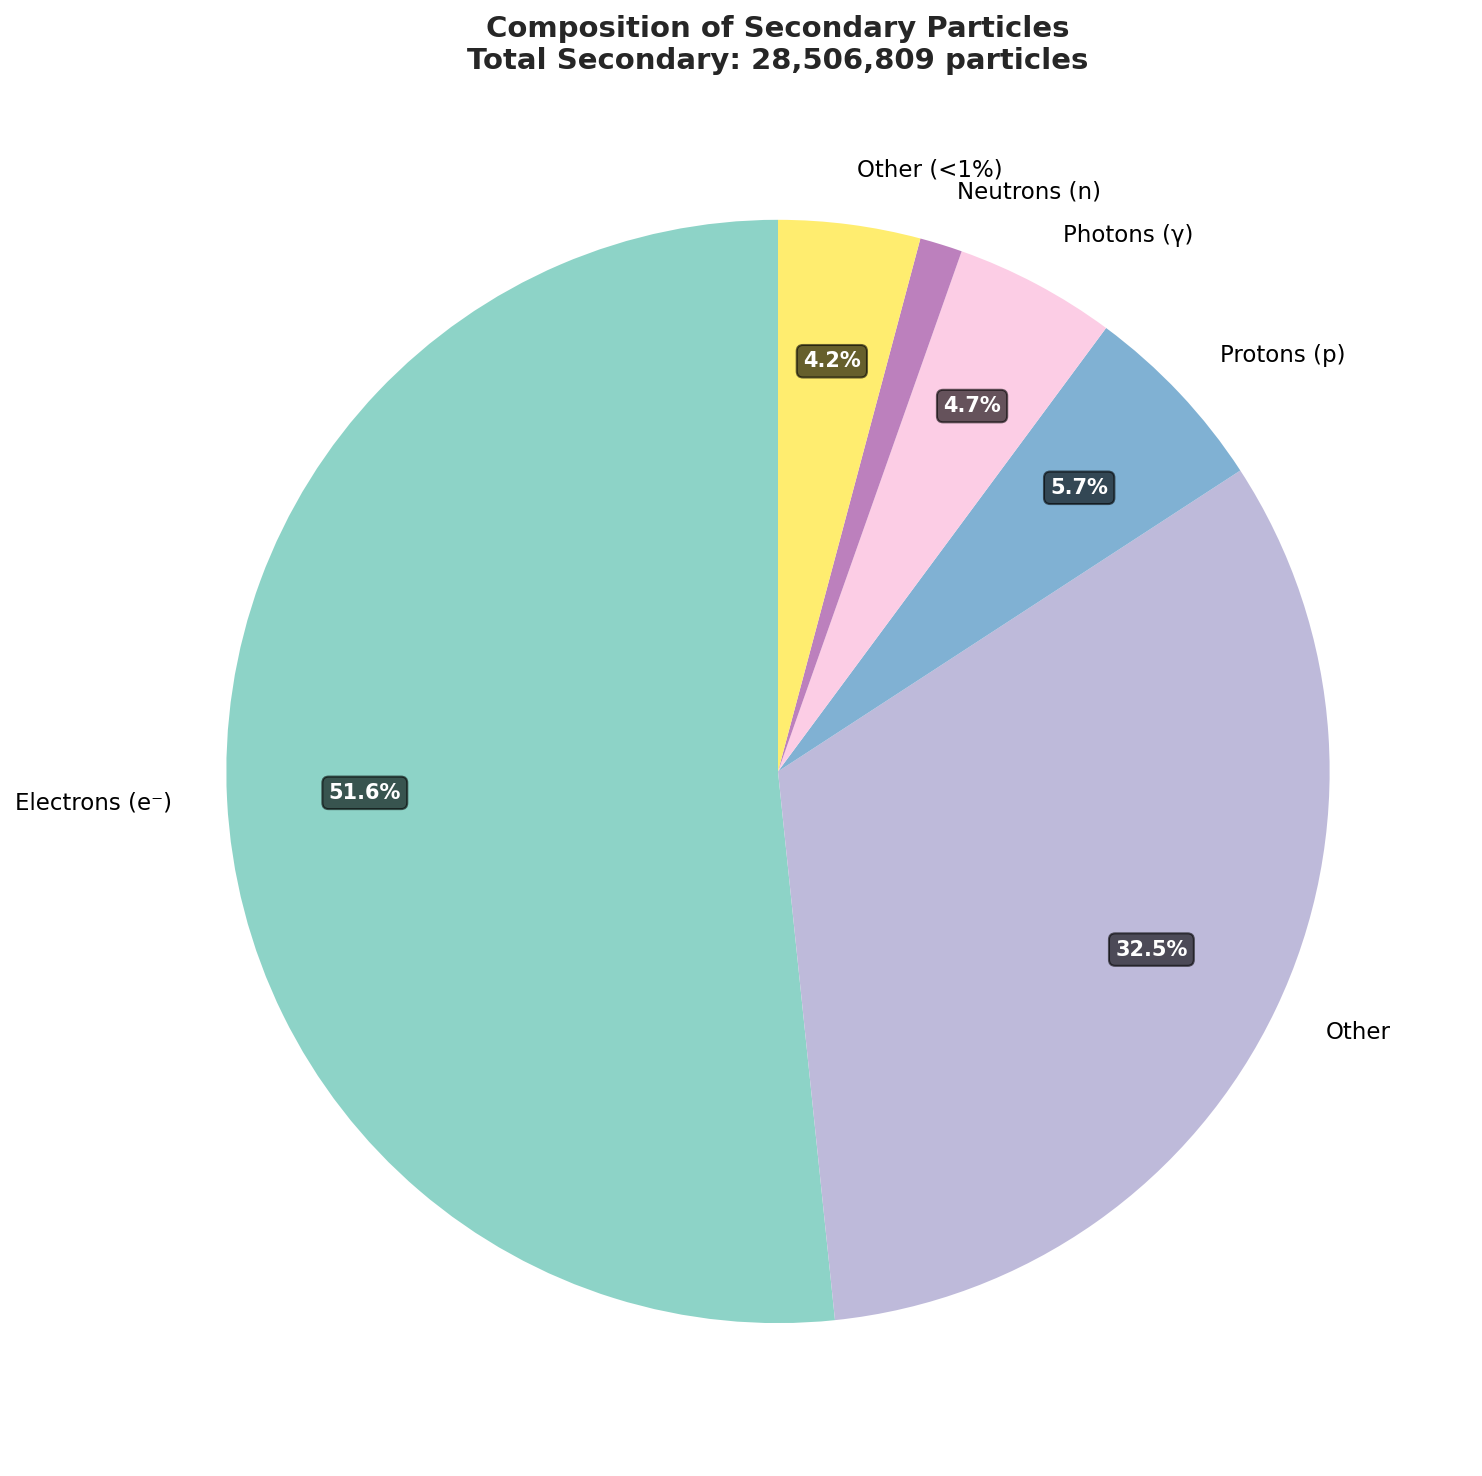

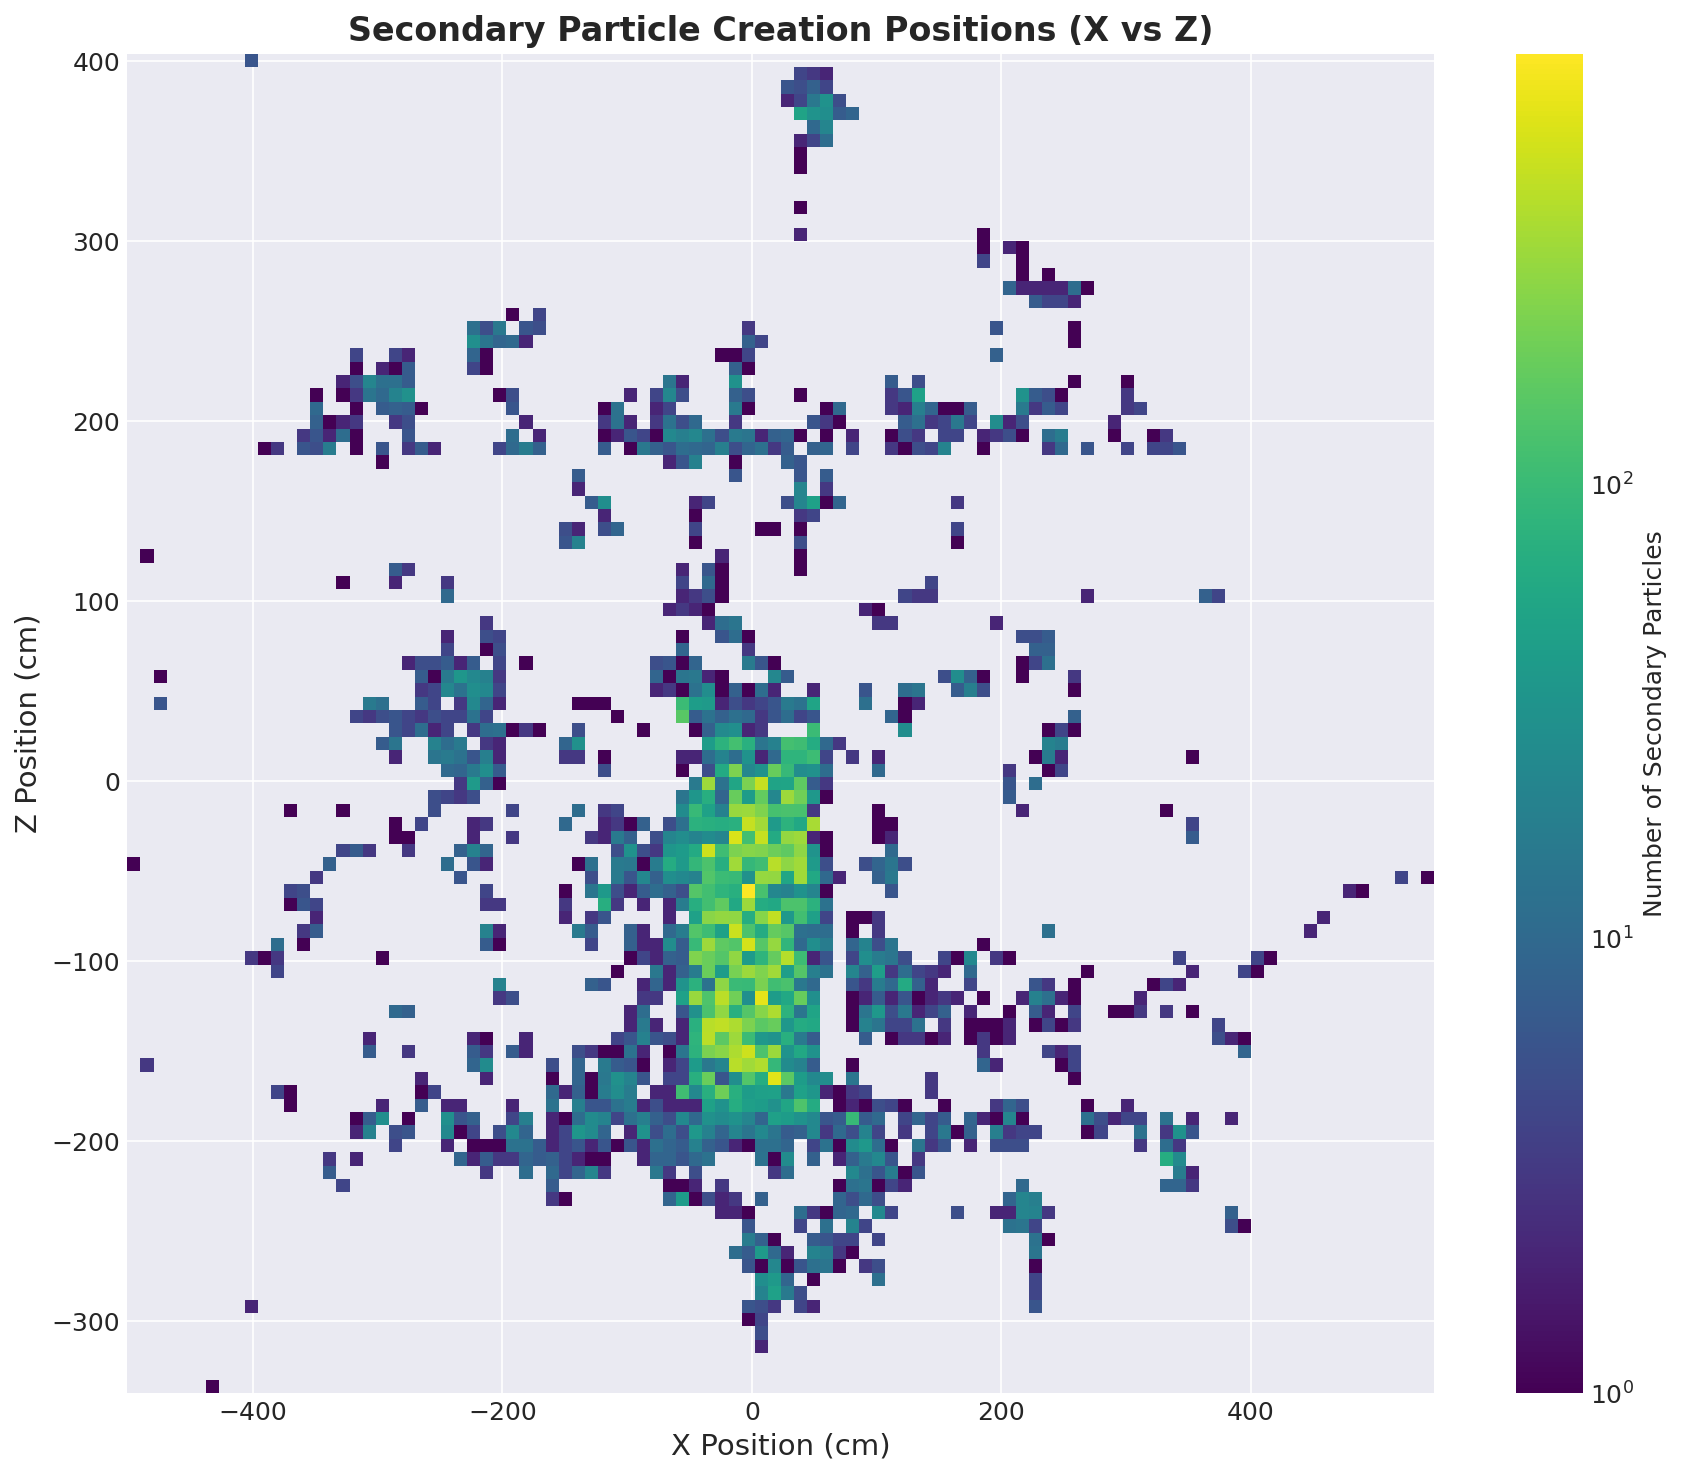

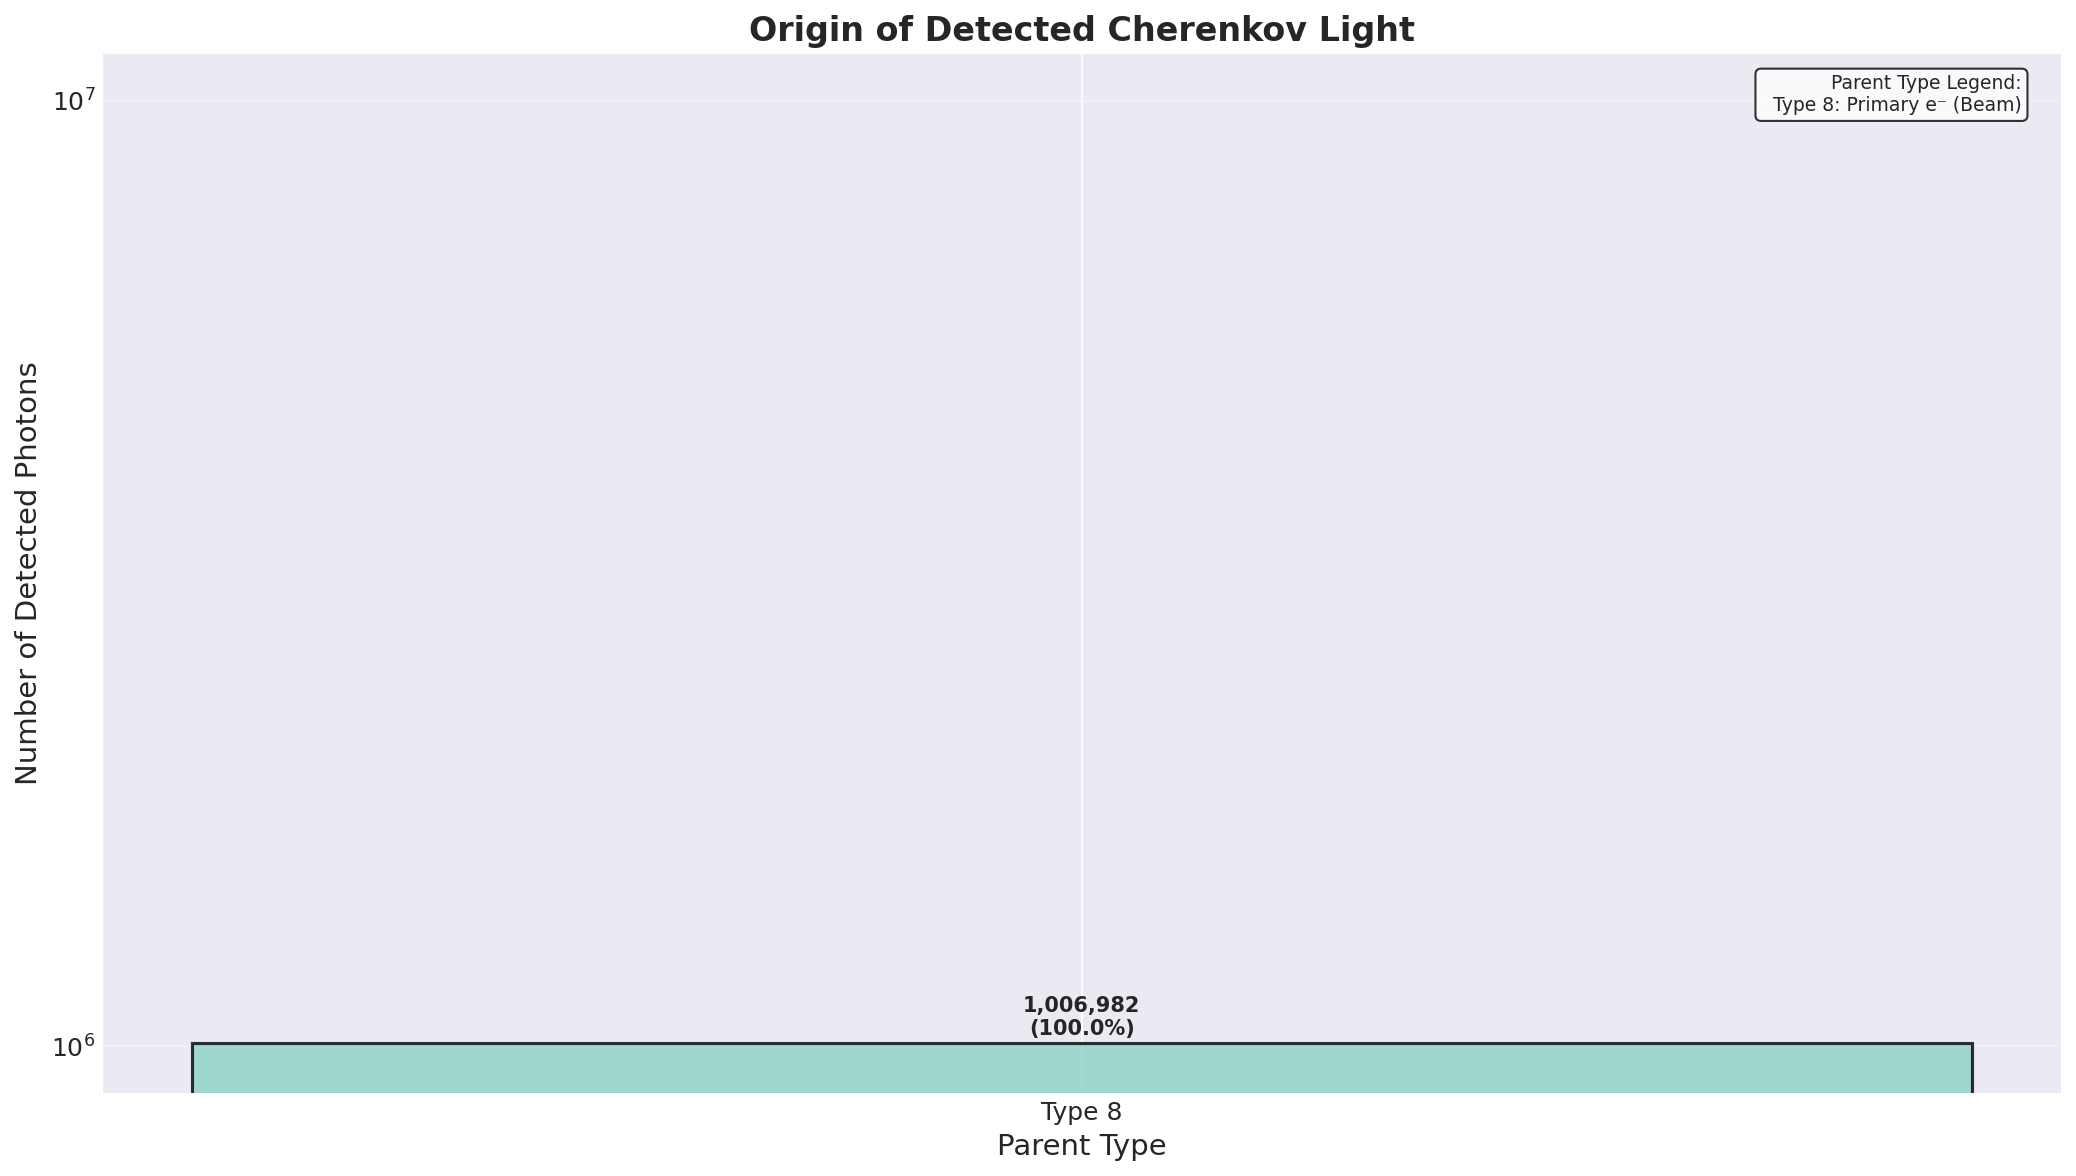


SUMMARY TABLE
Metric                                        Value               
-----------------------------------------------------------------
Total Events                                  100,000
Events After Quality Cuts                     43,851
Total Detected Photons                        1,006,982
Mean Photons per Event                        23.0
Total Particles Created                       28,606,809
Primary Particles (from Gun)                  100,000
Secondary Particles (from Interactions)       28,506,809
Secondary Fraction                            99.7%
Secondary Gammas (γ)                          1,349,849
Secondary Electrons (e⁻)                      14,723,023
Secondary Positrons (e⁺)                      55,090
Secondary Neutrons (n)                        355,448

FILES GENERATED
  - figure1_secondary_particles.png
  - figure2_primary_vs_secondary.png
  - figure3_secondary_composition.png
  - figure4_secondary_particle_positions.png
  - figure5_parent_type_d

In [10]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
import os
from collections import Counter

# Set publication-quality plot parameters
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.dpi'] = 150

print("Libraries imported successfully")

# ============================================================
# PDG CODE TO PARTICLE NAME MAPPING (with Nuclear Ion Grouping)
# ============================================================

# Element symbols for Z=1 to 100
element_symbols = {
    1: 'H', 2: 'He', 3: 'Li', 4: 'Be', 5: 'B', 6: 'C', 7: 'N', 8: 'O',
    9: 'F', 10: 'Ne', 11: 'Na', 12: 'Mg', 13: 'Al', 14: 'Si', 15: 'P', 
    16: 'S', 17: 'Cl', 18: 'Ar', 19: 'K', 20: 'Ca', 21: 'Sc', 22: 'Ti',
    23: 'V', 24: 'Cr', 25: 'Mn', 26: 'Fe', 27: 'Co', 28: 'Ni', 29: 'Cu',
    30: 'Zn', 31: 'Ga', 32: 'Ge', 33: 'As', 34: 'Se', 35: 'Br', 36: 'Kr',
    37: 'Rb', 38: 'Sr', 39: 'Y', 40: 'Zr', 41: 'Nb', 42: 'Mo', 43: 'Tc',
    44: 'Ru', 45: 'Rh', 46: 'Pd', 47: 'Ag', 48: 'Cd', 49: 'In', 50: 'Sn',
    51: 'Sb', 52: 'Te', 53: 'I', 54: 'Xe', 55: 'Cs', 56: 'Ba', 57: 'La',
    58: 'Ce', 59: 'Pr', 60: 'Nd', 61: 'Pm', 62: 'Sm', 63: 'Eu', 64: 'Gd',
    65: 'Tb', 66: 'Dy', 67: 'Ho', 68: 'Er', 69: 'Tm', 70: 'Yb', 71: 'Lu',
    72: 'Hf', 73: 'Ta', 74: 'W', 75: 'Re', 76: 'Os', 77: 'Ir', 78: 'Pt',
    79: 'Au', 80: 'Hg', 81: 'Tl', 82: 'Pb', 83: 'Bi', 84: 'Po', 85: 'At',
    86: 'Rn', 87: 'Fr', 88: 'Ra', 89: 'Ac', 90: 'Th', 91: 'Pa', 92: 'U',
    93: 'Np', 94: 'Pu', 95: 'Am', 96: 'Cm', 97: 'Bk', 98: 'Cf', 99: 'Es',
    100: 'Fm'
}

def decode_pdg_ion(pdg):
    """Decode nuclear ion PDG code (10-digit format)"""
    if pdg < 1000000000:
        return None
    
    I = pdg % 10
    A = (pdg // 10) % 1000
    Z = (pdg // 10000) % 1000
    L = (pdg // 10000000) % 10
    
    return {
        "Z": Z,
        "A": A,
        "L": L,
        "I": I,
        "element": element_symbols.get(Z, f"Z={Z}")
    }

def get_particle_name(pdg):
    """Convert PDG code to human-readable particle name"""
    elementary = {
        11: "e⁻ (Electron)",
        -11: "e⁺ (Positron)",
        22: "γ (Photon)",
        2112: "n (Neutron)",
        2212: "p (Proton)",
        13: "μ⁻ (Muon)",
        -13: "μ⁺ (Antimuon)",
        111: "π⁰ (Pion)",
        211: "π⁺ (Pion)",
        -211: "π⁻ (Pion)",
        12: "νₑ (Neutrino)",
        -12: "ν̄ₑ (Antineutrino)",
        14: "ν_μ (Muon Neutrino)",
        -14: "ν̄_μ (Muon Antineutrino)",
        1000010020: "Deuteron",
        1000010030: "Tritium",
        1000020040: "Alpha (⁴He)",
    }
    
    if pdg in elementary:
        return elementary[pdg]
    
    ion_info = decode_pdg_ion(pdg)
    if ion_info:
        return f"{ion_info['element']}-{ion_info['A']} (Nucleus)"
    
    return f"Unknown (PDG {pdg})"

def get_particle_group_name(pdg):
    """
    Group nuclear ions by element and mass number.
    This ensures Fe-57 appears as one entry regardless of L/I states.
    """
    elementary_groups = {
        11: "Electrons (e⁻)",
        -11: "Positrons (e⁺)",
        22: "Photons (γ)",
        2112: "Neutrons (n)",
        2212: "Protons (p)",
        13: "Muons (μ⁻)",
        -13: "Antimuons (μ⁺)",
        111: "Pions (π⁰)",
        211: "Pions (π⁺)",
        -211: "Pions (π⁻)",
        12: "Neutrinos (νₑ)",
        -12: "Antineutrinos (ν̄ₑ)",
        14: "Muon Neutrinos (ν_μ)",
        -14: "Muon Antineutrinos (ν̄_μ)",
        1000010020: "Deuteron",
        1000010030: "Tritium",
        1000020040: "Alpha (⁴He)",
    }
    
    if pdg in elementary_groups:
        return elementary_groups[pdg]
    
    ion_info = decode_pdg_ion(pdg)
    if ion_info:
        # Group by element and mass number (ignore L and I states)
        return f"{ion_info['element']}-{ion_info['A']}"
    
    return f"Unknown (PDG {pdg})"

# ============================================================
# SPECIFY YOUR FILE HERE
# ============================================================
path = "Sim_D2ODetector007.root"

if not os.path.exists(path):
    print(f"Error: {path} not found!")
    exit()

file = uproot.open(path)
Sim_Tree = file["Sim_Tree"]
event_data = Sim_Tree["eventData"]
print(f"File opened: {path}")
print(f"Total events: {Sim_Tree.num_entries}")

# ============================================================
# LOAD ALL DATA
# ============================================================
print("\nLoading data...")

pmt_hits = event_data["pmtHits"].array()
pmt_num = pmt_hits["pmtHits.pmtNum"]
pmt_parent_type = pmt_hits["pmtHits.parentType"]
pmt_time = pmt_hits["pmtHits.eventTime"]
pmt_energy = pmt_hits["pmtHits.photonEnergy"]

try:
    all_particle_trackID = event_data["allParticleTrackID"].array()
    all_particle_pdg = event_data["allParticlePDG"].array()
    all_particle_parentID = event_data["allParticleParentID"].array()
    all_particle_processID = event_data["allParticleProcessID"].array()
    all_particle_posX = event_data["allParticlePosX"].array()
    all_particle_posZ = event_data["allParticlePosZ"].array()
    has_all_particles = True
    print("✓ All particles data found")
except Exception as e:
    has_all_particles = False
    print(f"✗ All particles data not found: {e}")

try:
    neutron_captured = event_data["neutronCaptureDetected"].array()
    has_capture_data = True
    print("✓ Neutron capture data found")
except:
    has_capture_data = False
    print("✗ Neutron capture data not found")

print("\nData loading complete")

# ============================================================
# APPLY QUALITY CUTS TO PMT HITS
# ============================================================
print("\nApplying quality cuts to PMT hits...")

n_events_all = len(pmt_num)

pass_mask = []
for evt in pmt_num:
    evt_np = np.asarray(ak.to_numpy(evt), dtype=np.int64)
    counts_12 = np.bincount(evt_np, minlength=12)[:12]
    n_distinct_pmts = np.sum(counts_12 >= 1)
    pass_mask.append(n_distinct_pmts >= 2)
pass_mask = np.asarray(pass_mask, dtype=bool)

pmt_num_sel = pmt_num[pass_mask]
pmt_parent_type_sel = pmt_parent_type[pass_mask]
pmt_time_sel = pmt_time[pass_mask]
pmt_energy_sel = pmt_energy[pass_mask]

totalPE = ak.num(pmt_num_sel, axis=1)
totalPE_np = ak.to_numpy(totalPE)

print(f"Events before cuts: {n_events_all}")
print(f"Events after cuts: {len(totalPE_np)}")

pmt_num_flat = ak.to_numpy(ak.flatten(pmt_num_sel))
pmt_parent_type_flat = ak.to_numpy(ak.flatten(pmt_parent_type_sel))
pmt_time_flat = ak.to_numpy(ak.flatten(pmt_time_sel))
pmt_energy_flat = ak.to_numpy(ak.flatten(pmt_energy_sel)) * 1000

print(f"Total detected photons: {len(pmt_num_flat)}")

# ============================================================
# PROCESS ALL PARTICLES DATA (EXCLUDING PRIMARY PARTICLES)
# ============================================================
if has_all_particles:
    all_pdg_flat = ak.to_numpy(ak.flatten(all_particle_pdg))
    all_parentID_flat = ak.to_numpy(ak.flatten(all_particle_parentID))
    
    # EXCLUDE PRIMARY PARTICLES (parentID == 0 means no parent = primary)
    secondary_mask = (all_parentID_flat != 0)
    
    all_secondary_pdg = all_pdg_flat[secondary_mask]
    
    print("\n" + "="*80)
    print("PARTICLE STATISTICS")
    print("="*80)
    print(f"Total particles created (all): {len(all_pdg_flat):,}")
    print(f"Primary particles (parentID=0): {np.sum(all_parentID_flat == 0):,}")
    print(f"Secondary particles (parentID>0): {len(all_secondary_pdg):,}")
    print(f"Secondary fraction: {100 * len(all_secondary_pdg) / len(all_pdg_flat):.1f}%")
    
    # ============================================================
    # GROUP PARTICLES BY TYPE (GROUP NUCLEAR IONS BY ELEMENT/MASS)
    # ============================================================
    particle_groups = {}
    for pdg in all_secondary_pdg:
        group_name = get_particle_group_name(pdg)
        particle_groups[group_name] = particle_groups.get(group_name, 0) + 1
    
    # Create sorted list
    secondary_particle_data = [(name, count) for name, count in particle_groups.items()]
    secondary_particle_data.sort(key=lambda x: x[1], reverse=True)
    
    print("\n" + "-"*80)
    print("SECONDARY PARTICLES (Grouped by Type) - Sorted by count")
    print("-"*80)
    print(f"{'Particle Type':<35} {'Count':<12} {'Percentage':<10}")
    print("-"*80)
    for name, count in secondary_particle_data[:20]:
        percentage = 100 * count / len(all_secondary_pdg)
        bar = "█" * int(percentage / 2)
        print(f"{name:<35} {count:<12,} {percentage:<10.2f}% {bar}")
    
    # ============================================================
    # FIGURE 1: SECONDARY PARTICLES PRODUCED (Grouped)
    # ============================================================
    fig, ax = plt.subplots(figsize=(14, 8))
    
    top_n = min(15, len(secondary_particle_data))
    names_plot = [p[0] for p in secondary_particle_data[:top_n]]
    counts_plot = [p[1] for p in secondary_particle_data[:top_n]]
    names_plot_short = [name[:30] + "..." if len(name) > 30 else name for name in names_plot]
    
    colors = plt.cm.viridis(np.linspace(0, 1, top_n))
    bars = ax.bar(range(top_n), counts_plot, color=colors, edgecolor='black', alpha=0.8, linewidth=1.5)
    ax.set_xlabel('Particle Type', fontsize=14)
    ax.set_ylabel('Number of Secondary Particles Created', fontsize=14)
    ax.set_title('Secondary Particles Produced in Simulation', fontsize=16, fontweight='bold')
    ax.set_xticks(range(top_n))
    ax.set_xticklabels(names_plot_short, rotation=45, ha='right', fontsize=10)
    
    for bar, count in zip(bars, counts_plot):
        percentage = 100 * count / len(all_secondary_pdg)
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts_plot)*0.01, 
                f'{count:,}\n({percentage:.1f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig('figure1_secondary_particles.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # ============================================================
    # FIGURE 2: COMPARISON - PRIMARY VS SECONDARY
    # ============================================================
    fig, ax = plt.subplots(figsize=(10, 8))
    
    primary_count = np.sum(all_parentID_flat == 0)
    secondary_count = len(all_secondary_pdg)
    
    comparison_data = [
        ("Primary Particles\n(from Gun)", primary_count),
        ("Secondary Particles\n(from Interactions)", secondary_count)
    ]
    
    names_comp = [d[0] for d in comparison_data]
    counts_comp = [d[1] for d in comparison_data]
    colors_comp = ['#ff7f0e', '#2ca02c']
    
    bars = ax.bar(range(len(names_comp)), counts_comp, color=colors_comp, edgecolor='black', alpha=0.8, linewidth=1.5)
    ax.set_xlabel('Particle Category', fontsize=14)
    ax.set_ylabel('Number of Particles', fontsize=14)
    ax.set_title('Primary vs Secondary Particles', fontsize=16, fontweight='bold')
    ax.set_xticks(range(len(names_comp)))
    ax.set_xticklabels(names_comp, fontsize=12)
    
    for bar, count in zip(bars, counts_comp):
        percentage = 100 * count / len(all_pdg_flat)
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts_comp)*0.01, 
                f'{count:,}\n({percentage:.1f}% of all particles)', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('figure2_primary_vs_secondary.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # ============================================================
    # FIGURE 3: SECONDARY PARTICLE COMPOSITION (Pie Chart - Grouped)
    # ============================================================
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Group secondary particles for pie chart
    secondary_groups = {}
    for name, count in secondary_particle_data:
        if count < len(all_secondary_pdg) * 0.01:
            secondary_groups['Other (<1%)'] = secondary_groups.get('Other (<1%)', 0) + count
        elif 'Photon' in name or 'γ' in name:
            secondary_groups['Photons (γ)'] = secondary_groups.get('Photons (γ)', 0) + count
        elif 'Electron' in name or 'e⁻' in name:
            secondary_groups['Electrons (e⁻)'] = secondary_groups.get('Electrons (e⁻)', 0) + count
        elif 'Positron' in name or 'e⁺' in name:
            secondary_groups['Positrons (e⁺)'] = secondary_groups.get('Positrons (e⁺)', 0) + count
        elif 'Neutron' in name:
            secondary_groups['Neutrons (n)'] = secondary_groups.get('Neutrons (n)', 0) + count
        elif 'Proton' in name:
            secondary_groups['Protons (p)'] = secondary_groups.get('Protons (p)', 0) + count
        elif 'Nucleus' in name or 'Nuclei' in name:
            element = name.split('-')[0]
            if 'Fe' in name:
                secondary_groups['Iron Nuclei (Fe)'] = secondary_groups.get('Iron Nuclei (Fe)', 0) + count
            elif 'Cu' in name:
                secondary_groups['Copper Nuclei (Cu)'] = secondary_groups.get('Copper Nuclei (Cu)', 0) + count
            else:
                secondary_groups[f'Nuclei ({element})'] = secondary_groups.get(f'Nuclei ({element})', 0) + count
        else:
            secondary_groups['Other'] = secondary_groups.get('Other', 0) + count
    
    secondary_groups = {k: v for k, v in secondary_groups.items() if v > 0}
    colors_pie = plt.cm.Set3(np.linspace(0, 1, len(secondary_groups)))
    
    def autopct_format(pct):
        return f'{pct:.1f}%' if pct > 2 else ''
    
    wedges, texts, autotexts = ax.pie(secondary_groups.values(), 
                                        labels=secondary_groups.keys(), 
                                        autopct=autopct_format,
                                        colors=colors_pie, 
                                        startangle=90,
                                        textprops={'fontsize': 11},
                                        pctdistance=0.75,
                                        labeldistance=1.1)
    
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontsize(10)
        autotext.set_fontweight('bold')
        autotext.set_bbox(dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.6))
    
    for text in texts:
        text.set_color('black')
        text.set_fontsize(11)
    
    ax.set_title(f'Composition of Secondary Particles\nTotal Secondary: {len(all_secondary_pdg):,} particles', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('figure3_secondary_composition.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # ============================================================
    # FIGURE 4: SECONDARY PARTICLE CREATION POSITIONS
    # ============================================================
    fig, ax = plt.subplots(figsize=(12, 10))
    
    all_pos_x_flat = ak.to_numpy(ak.flatten(all_particle_posX))
    all_pos_z_flat = ak.to_numpy(ak.flatten(all_particle_posZ))
    
    secondary_pos_x = all_pos_x_flat[secondary_mask]
    secondary_pos_z = all_pos_z_flat[secondary_mask]
    
    h2d = ax.hist2d(secondary_pos_x[:50000], secondary_pos_z[:50000], bins=100, 
                    cmap='viridis', norm=plt.matplotlib.colors.LogNorm())
    ax.set_xlabel('X Position (cm)', fontsize=14)
    ax.set_ylabel('Z Position (cm)', fontsize=14)
    ax.set_title('Secondary Particle Creation Positions (X vs Z)', fontsize=16, fontweight='bold')
    cbar = plt.colorbar(h2d[3], ax=ax)
    cbar.set_label('Number of Secondary Particles', fontsize=12)
    plt.tight_layout()
    plt.savefig('figure4_secondary_particle_positions.png', dpi=300, bbox_inches='tight')
    plt.show()

# ============================================================
# FIGURE 5: PARENT TYPE DISTRIBUTION
# ============================================================
parent_labels = {
    1: 'Muon',
    2: 'Michel e⁻ (μ decay)',
    3: 'EM Shower e⁻ (Compton, Photo, Pair)',
    4: 'Unclassified',
    5: 'Neutron Capture γ',
    6: 'EM Shower γ (Bremsstrahlung)',
    7: 'Delta Ray (Ionization e⁻)',
    8: 'Primary e⁻ (Beam)',
    9: 'Radioactive Decay',
    10: 'Neutron Inelastic',
    11: 'Cosmic Ray γ'
}

unique_pt, pt_counts = np.unique(pmt_parent_type_flat, return_counts=True)

fig, ax = plt.subplots(figsize=(14, 8))

pt_labels = [parent_labels.get(pt, f'Type {pt}') for pt in unique_pt]
colors = plt.cm.Set3(np.linspace(0, 1, len(unique_pt)))
bars = ax.bar(range(len(unique_pt)), pt_counts, color=colors, edgecolor='black', alpha=0.8, linewidth=1.5)

ax.set_xlabel('Parent Type', fontsize=14)
ax.set_ylabel('Number of Detected Photons', fontsize=14)
ax.set_title('Origin of Detected Cherenkov Light', fontsize=16, fontweight='bold')
ax.set_xticks(range(len(unique_pt)))
ax.set_xticklabels([f'Type {pt}' for pt in unique_pt], fontsize=12)

for bar, count, pt in zip(bars, pt_counts, unique_pt):
    percentage = 100 * count / len(pmt_parent_type_flat)
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(pt_counts)*0.01, 
            f'{count:,}\n({percentage:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.text(0.98, 0.98, "Parent Type Legend:\n" + "\n".join([f"  Type {pt}: {parent_labels.get(pt, 'Unknown')}" for pt in unique_pt]), 
        transform=ax.transAxes, fontsize=9, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_yscale('log')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('figure5_parent_type_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# SUMMARY TABLE
# ============================================================
print("\n" + "="*80)
print("SUMMARY TABLE")
print("="*80)
print(f"{'Metric':<45} {'Value':<20}")
print("-"*65)
print(f"{'Total Events':<45} {n_events_all:,}")
print(f"{'Events After Quality Cuts':<45} {len(totalPE_np):,}")
print(f"{'Total Detected Photons':<45} {len(pmt_num_flat):,}")
print(f"{'Mean Photons per Event':<45} {np.mean(totalPE_np):.1f}")

if has_all_particles:
    print(f"{'Total Particles Created':<45} {len(all_pdg_flat):,}")
    print(f"{'Primary Particles (from Gun)':<45} {np.sum(all_parentID_flat == 0):,}")
    print(f"{'Secondary Particles (from Interactions)':<45} {len(all_secondary_pdg):,}")
    print(f"{'Secondary Fraction':<45} {100 * len(all_secondary_pdg) / len(all_pdg_flat):.1f}%")
    
    n_gammas = np.sum(all_secondary_pdg == 22)
    n_electrons = np.sum(all_secondary_pdg == 11)
    n_positrons = np.sum(all_secondary_pdg == -11)
    n_neutrons = np.sum(all_secondary_pdg == 2112)
    print(f"{'Secondary Gammas (γ)':<45} {n_gammas:,}")
    print(f"{'Secondary Electrons (e⁻)':<45} {n_electrons:,}")
    print(f"{'Secondary Positrons (e⁺)':<45} {n_positrons:,}")
    print(f"{'Secondary Neutrons (n)':<45} {n_neutrons:,}")

print("\n" + "="*80)
print("FILES GENERATED")
print("="*80)
print("  - figure1_secondary_particles.png")
print("  - figure2_primary_vs_secondary.png")
print("  - figure3_secondary_composition.png")
print("  - figure4_secondary_particle_positions.png")
print("  - figure5_parent_type_distribution.png")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)

Libraries imported successfully

LOADING DATA


File opened: Sim_D2ODetector004.root
Total events: 1000000

Loading PMT hit data...
✓ All particles data found
✗ Neutron capture data not found

Data loading complete

PMT HIT QUALITY CUTS
Events before cuts: 1,000,000
Events after cuts: 613,276
Total detected photons after cuts: 4,827,510

SECONDARY PARTICLE ANALYSIS
Total particles created: 55,013,989
Primary particles: 1,000,000
Secondary particles: 54,013,989
Secondary fraction: 98.2%


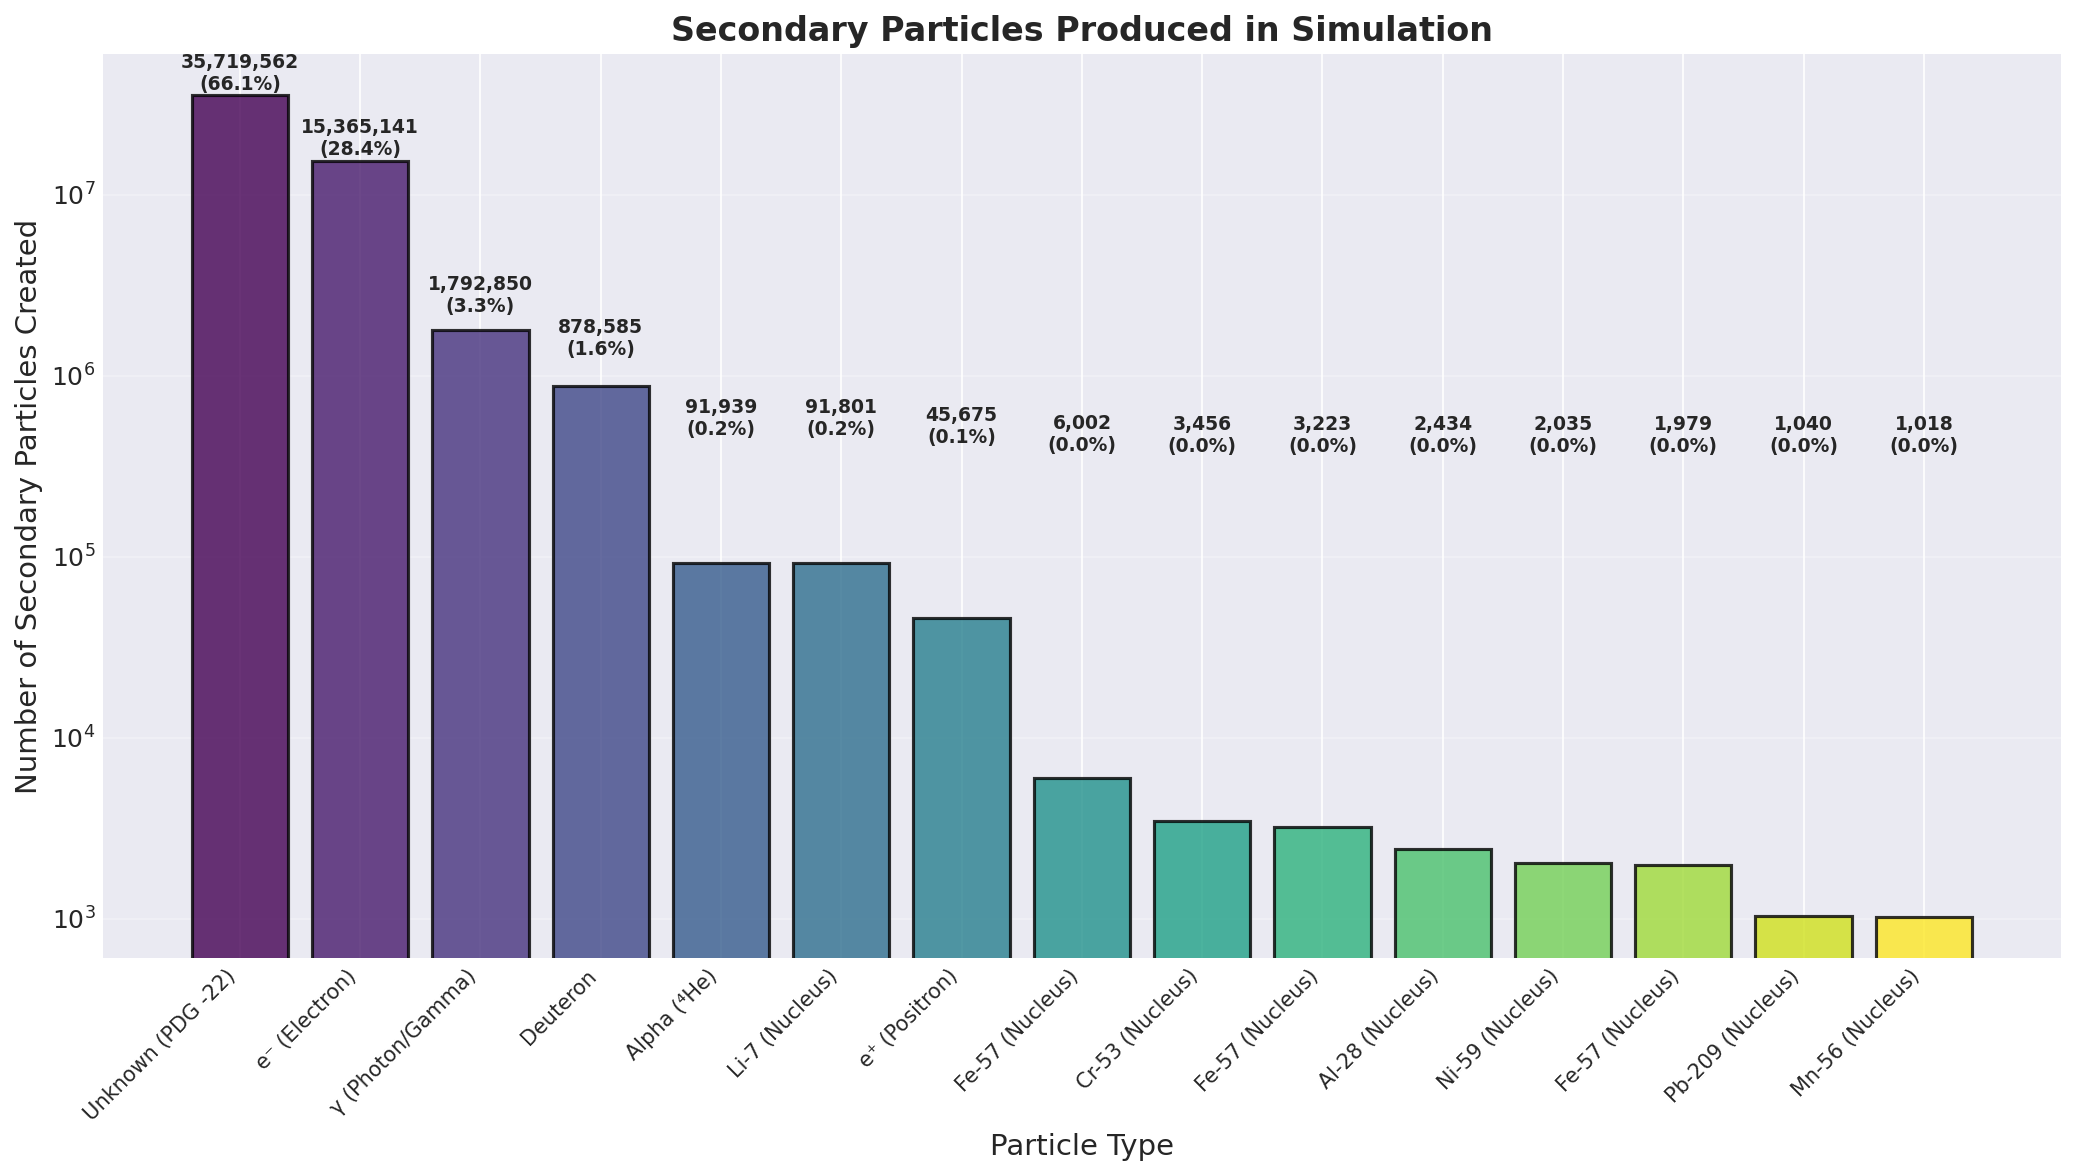

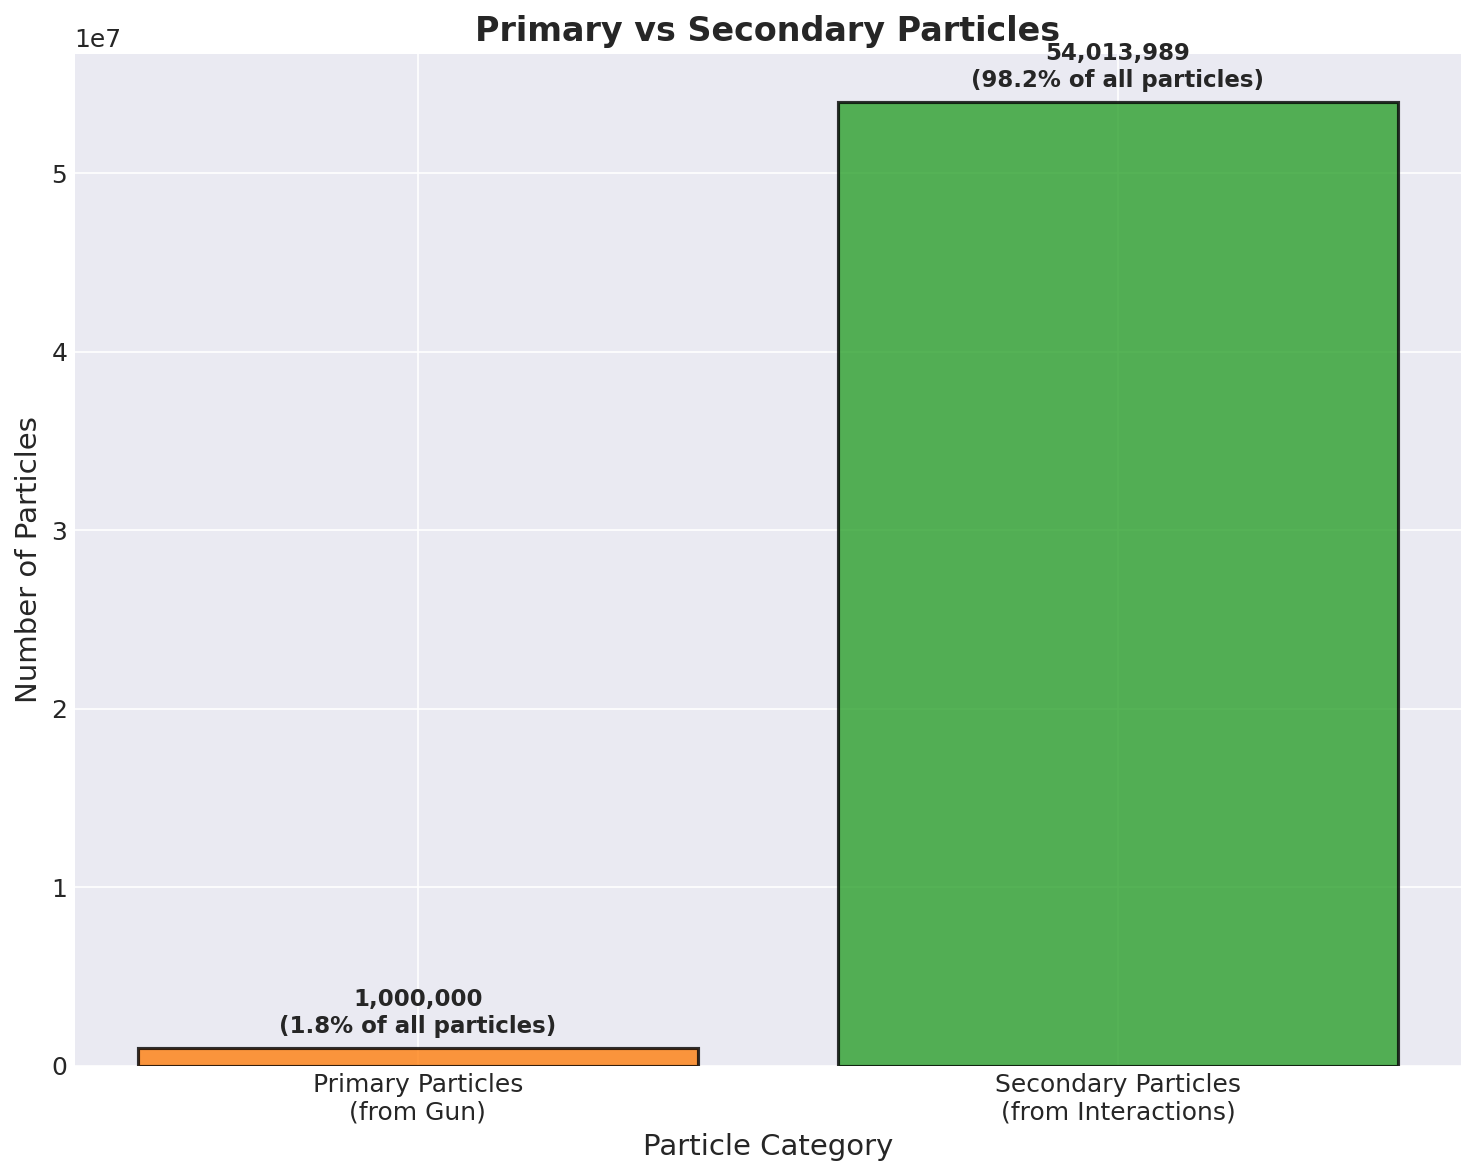

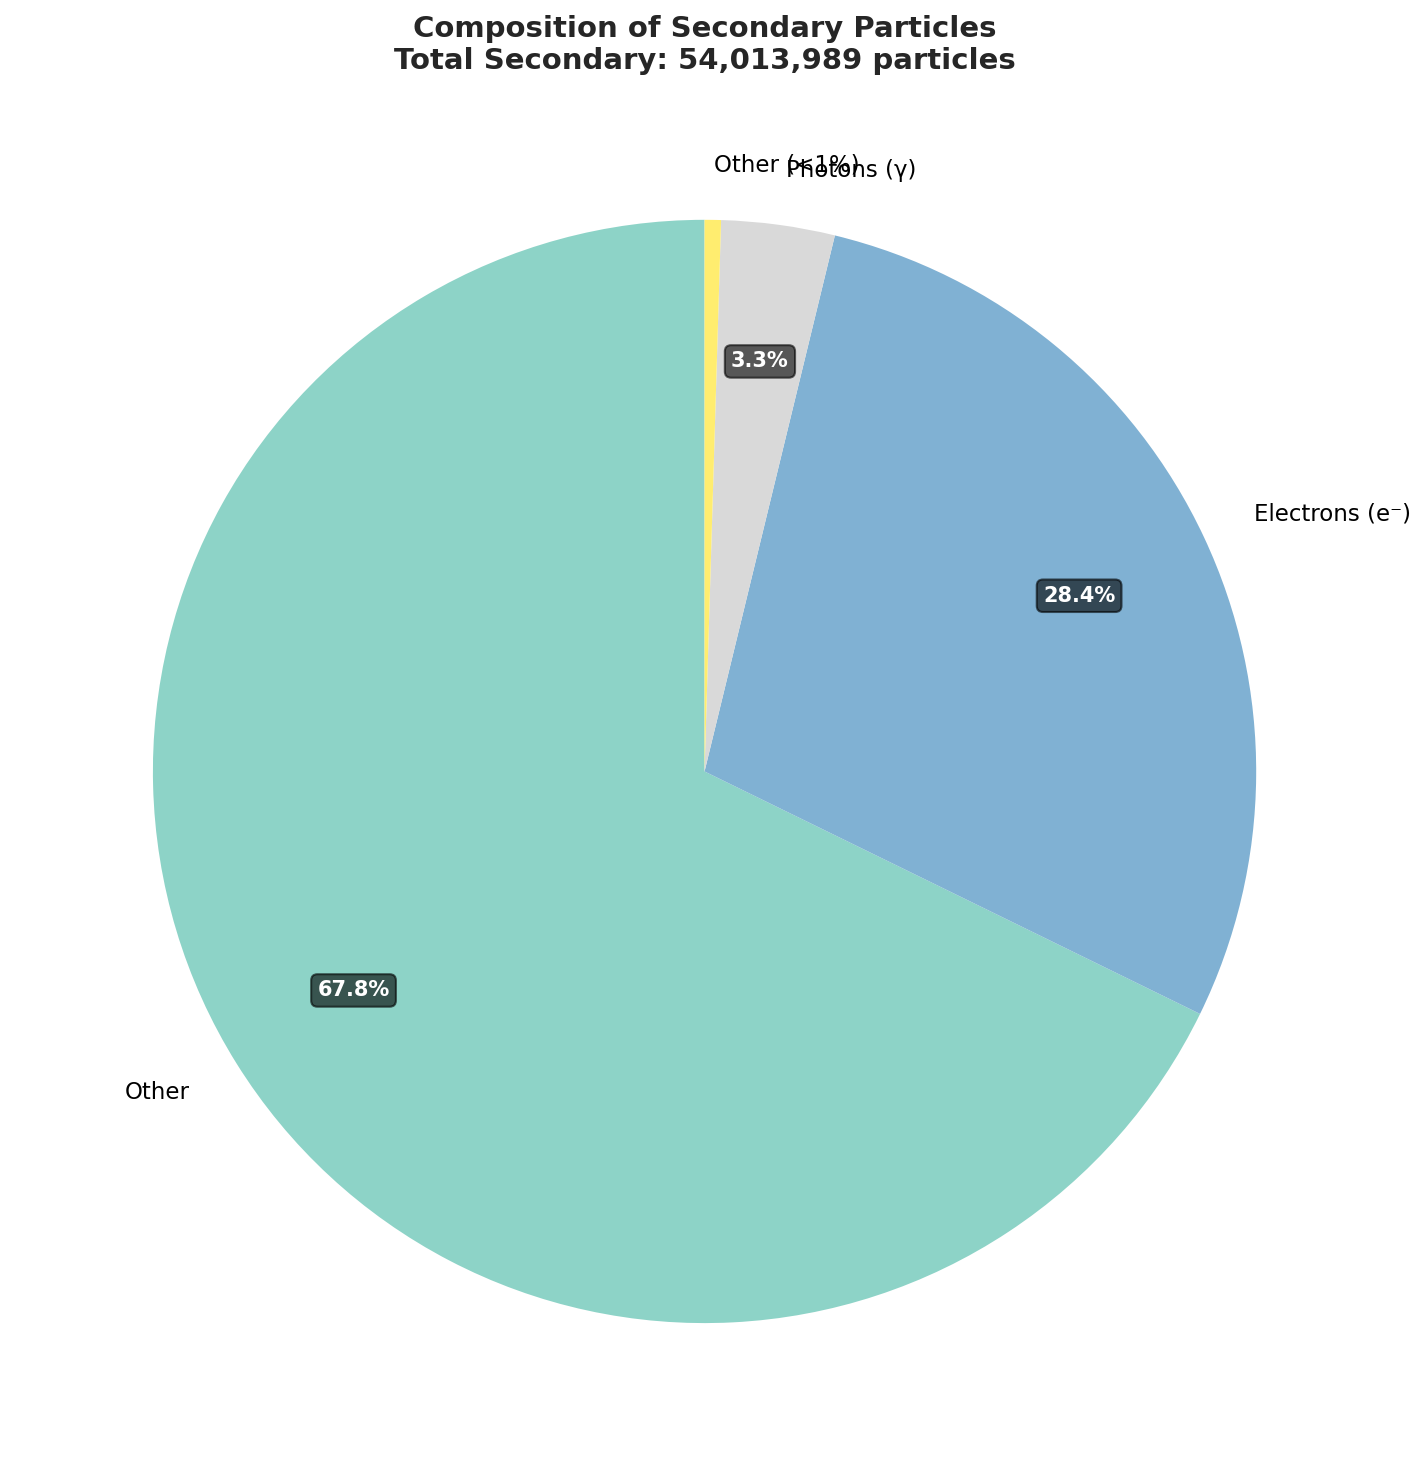

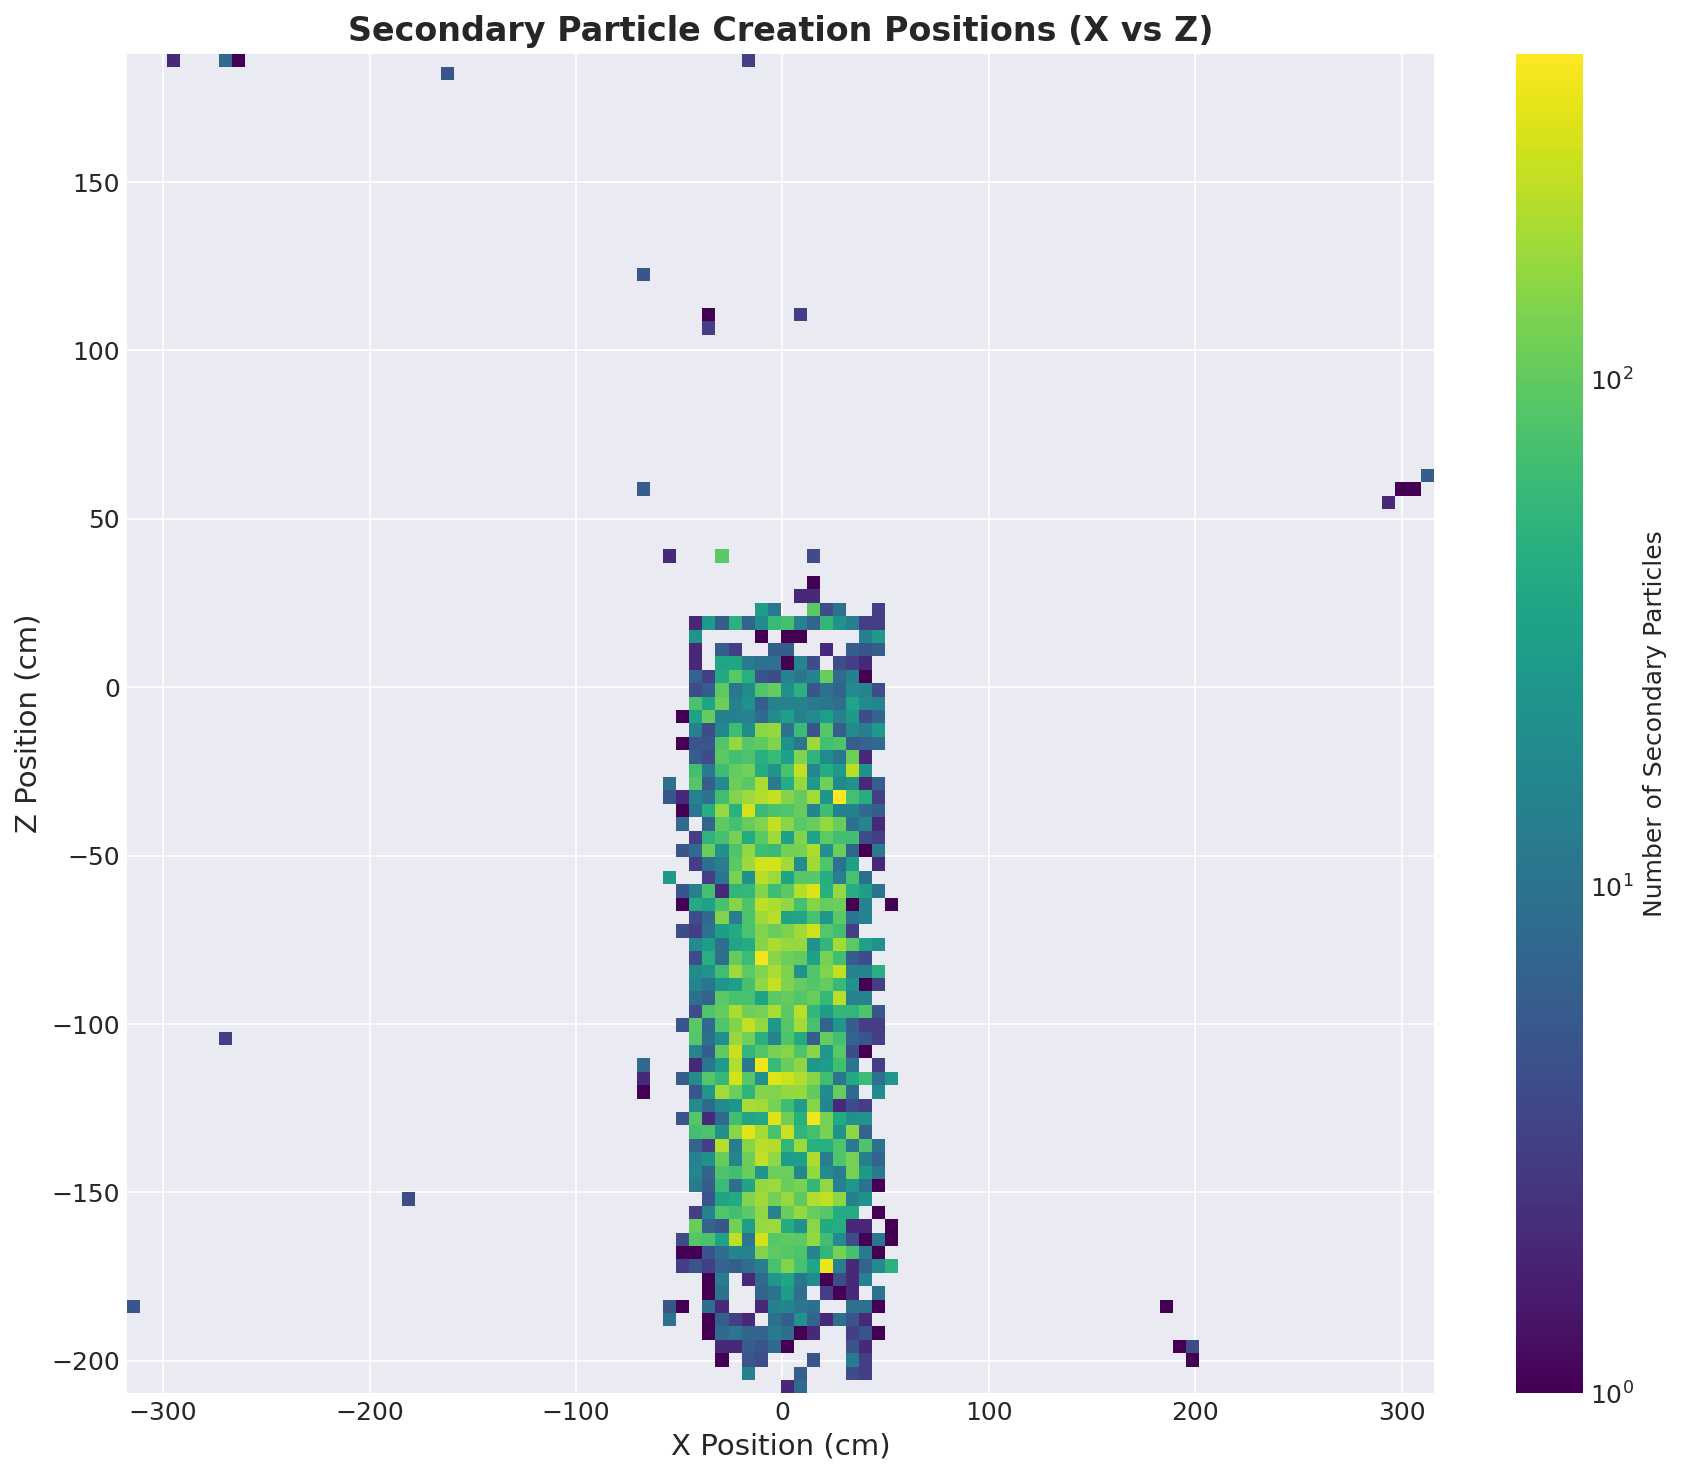


PARENT TYPE DISTRIBUTION


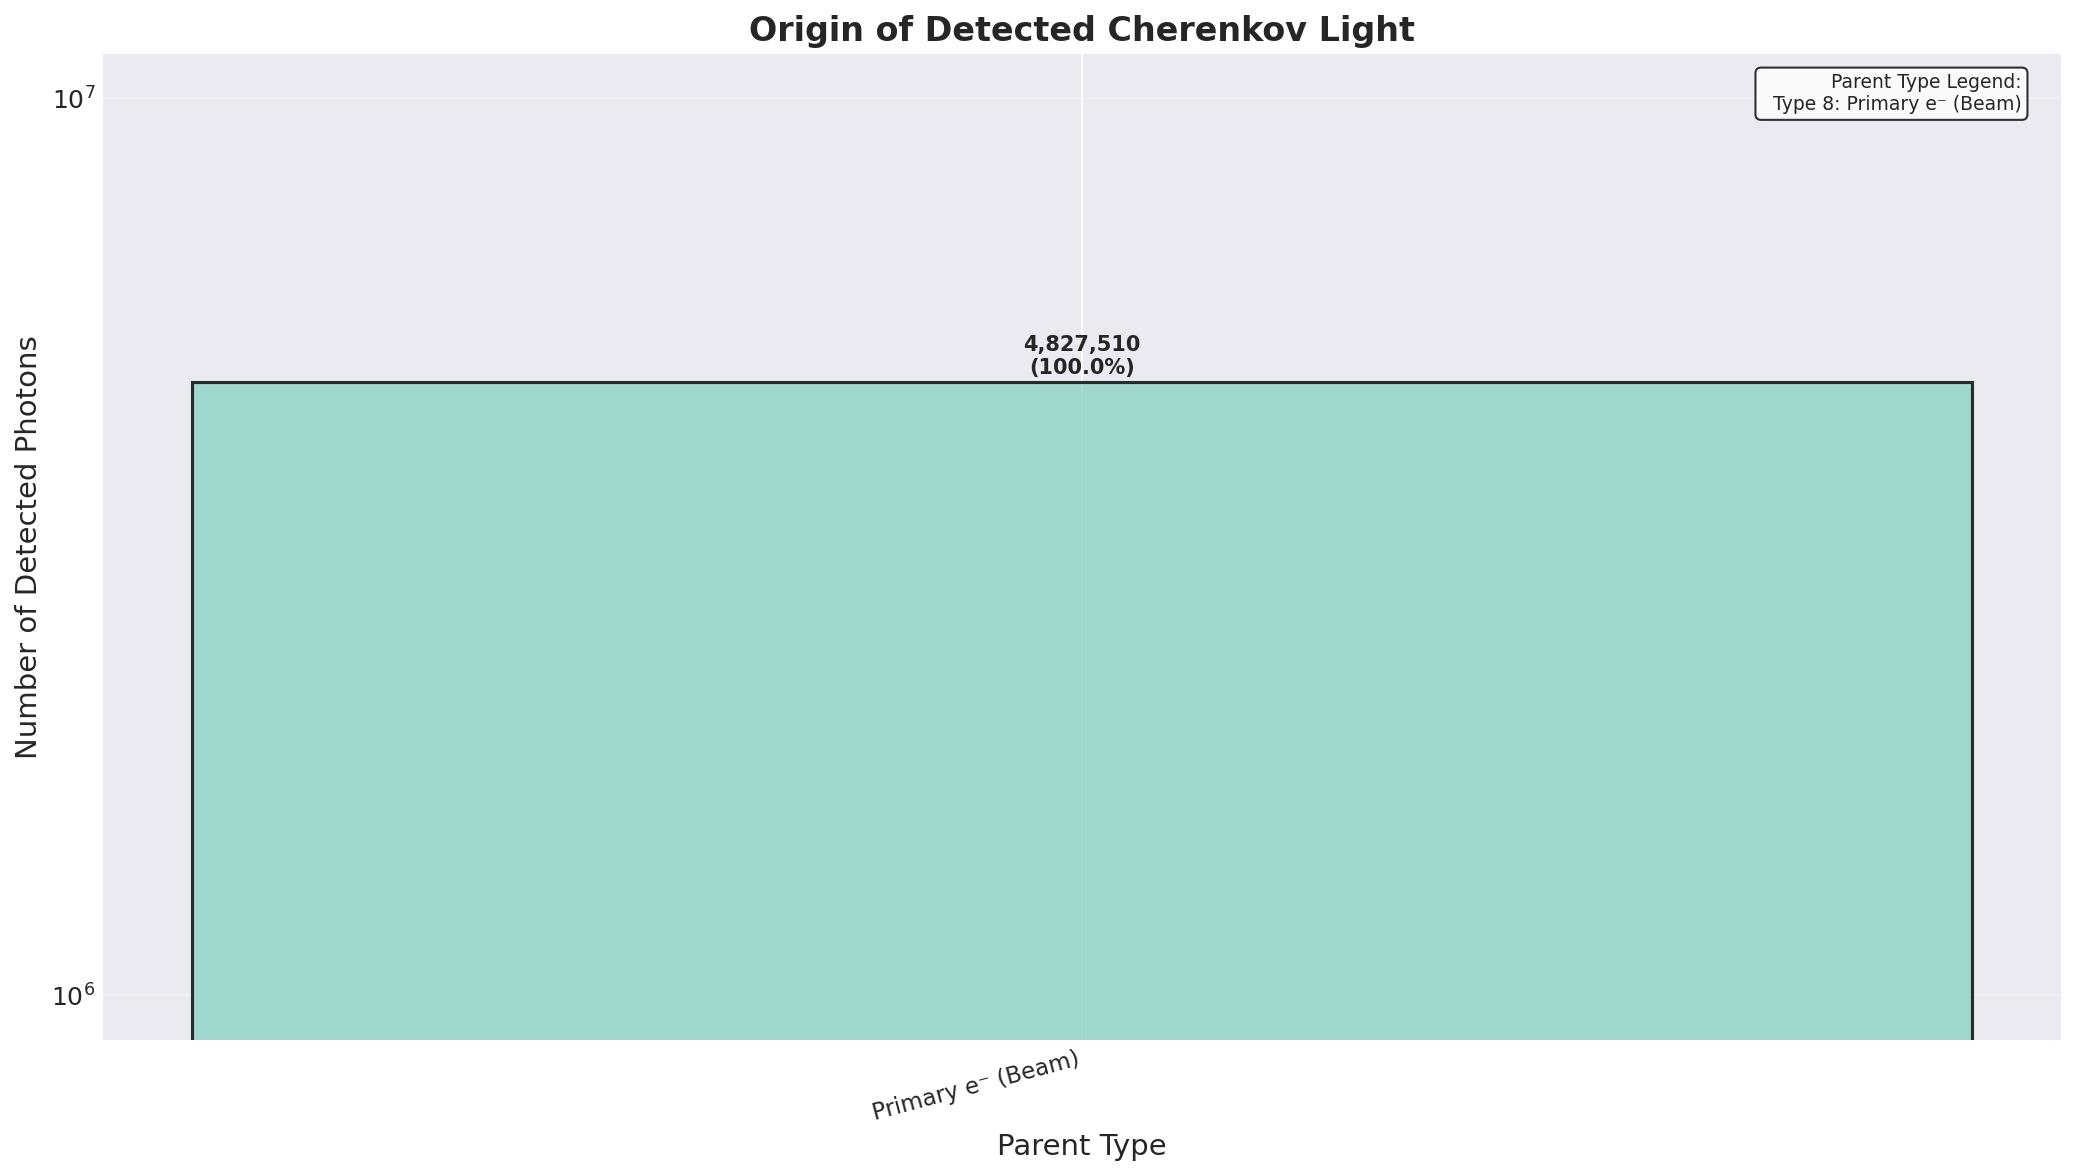


SUMMARY TABLE
Metric                                        Value               
-----------------------------------------------------------------
Total Events                                  1,000,000
Events After Quality Cuts                     613,276
Total Detected Photons                        4,827,510
Mean Photons per Event                        7.9
Total Particles Created                       55,013,989
Primary Particles (from Gun)                  1,000,000
Secondary Particles (from Interactions)       54,013,989
Secondary Fraction                            98.2%
Secondary Gammas (γ)                          1,792,850
Secondary Electrons (e⁻)                      15,365,141
Secondary Positrons (e⁺)                      45,675
Secondary Neutrons (n)                        0

Parent Type                                   Count                Percentage     
--------------------------------------------------------------------------------
Primary e⁻ (Beam)                  

In [ ]:


import uproot
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
import os
from collections import Counter

# ============================================================
# PLOT STYLE CONFIGURATION
# ============================================================
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.dpi'] = 150

print("Libraries imported successfully")

# ============================================================
# PDG CODE TO PARTICLE NAME MAPPING
# ============================================================

# Element symbols for nuclear ion decoding
ELEMENT_SYMBOLS = {
    1: 'H', 2: 'He', 3: 'Li', 4: 'Be', 5: 'B', 6: 'C', 7: 'N', 8: 'O',
    9: 'F', 10: 'Ne', 11: 'Na', 12: 'Mg', 13: 'Al', 14: 'Si', 15: 'P', 
    16: 'S', 17: 'Cl', 18: 'Ar', 19: 'K', 20: 'Ca', 21: 'Sc', 22: 'Ti',
    23: 'V', 24: 'Cr', 25: 'Mn', 26: 'Fe', 27: 'Co', 28: 'Ni', 29: 'Cu',
    30: 'Zn', 31: 'Ga', 32: 'Ge', 33: 'As', 34: 'Se', 35: 'Br', 36: 'Kr',
    37: 'Rb', 38: 'Sr', 39: 'Y', 40: 'Zr', 41: 'Nb', 42: 'Mo', 43: 'Tc',
    44: 'Ru', 45: 'Rh', 46: 'Pd', 47: 'Ag', 48: 'Cd', 49: 'In', 50: 'Sn',
    51: 'Sb', 52: 'Te', 53: 'I', 54: 'Xe', 55: 'Cs', 56: 'Ba', 57: 'La',
    58: 'Ce', 59: 'Pr', 60: 'Nd', 61: 'Pm', 62: 'Sm', 63: 'Eu', 64: 'Gd',
    65: 'Tb', 66: 'Dy', 67: 'Ho', 68: 'Er', 69: 'Tm', 70: 'Yb', 71: 'Lu',
    72: 'Hf', 73: 'Ta', 74: 'W', 75: 'Re', 76: 'Os', 77: 'Ir', 78: 'Pt',
    79: 'Au', 80: 'Hg', 81: 'Tl', 82: 'Pb', 83: 'Bi', 84: 'Po', 85: 'At',
    86: 'Rn', 87: 'Fr', 88: 'Ra', 89: 'Ac', 90: 'Th', 91: 'Pa', 92: 'U',
    93: 'Np', 94: 'Pu', 95: 'Am', 96: 'Cm', 97: 'Bk', 98: 'Cf', 99: 'Es',
    100: 'Fm'
}

# Common PDG codes
ELEMENTARY_PARTICLES = {
    11: "e⁻ (Electron)",
    -11: "e⁺ (Positron)",
    22: "γ (Photon/Gamma)",
    2112: "n (Neutron)",
    2212: "p (Proton)",
    13: "μ⁻ (Muon)",
    -13: "μ⁺ (Antimuon)",
    111: "π⁰ (Pion)",
    211: "π⁺ (Pion)",
    -211: "π⁻ (Pion)",
    12: "νₑ (Neutrino)",
    -12: "ν̄ₑ (Antineutrino)",
    14: "ν_μ (Muon Neutrino)",
    -14: "ν̄_μ (Muon Antineutrino)",
    1000010020: "Deuteron",
    1000010030: "Tritium",
    1000020040: "Alpha (⁴He)",
}

# Parent type labels for Cherenkov light origin
PARENT_TYPE_LABELS = {
    1: 'Muon',
    2: 'Michel e⁻ (μ decay)',
    3: 'EM Shower e⁻ (Compton, Photo, Pair)',
    4: 'Unclassified',
    5: 'Neutron Capture γ',
    6: 'EM Shower γ (Bremsstrahlung)',
    7: 'Delta Ray (Ionization e⁻)',
    8: 'Primary e⁻ (Beam)',
    9: 'Radioactive Decay',
    10: 'Neutron Inelastic',
    11: 'Cosmic Ray γ'
}


def decode_pdg_ion(pdg):
    """Decode nuclear ion PDG code (10-digit format)"""
    if pdg < 1000000000:
        return None
    
    I = pdg % 10
    A = (pdg // 10) % 1000
    Z = (pdg // 10000) % 1000
    L = (pdg // 10000000) % 10
    
    return {
        "Z": Z,
        "A": A,
        "L": L,
        "I": I,
        "element": ELEMENT_SYMBOLS.get(Z, f"Z={Z}")
    }


def get_particle_name(pdg):
    """Convert PDG code to human-readable particle name"""
    if pdg in ELEMENTARY_PARTICLES:
        return ELEMENTARY_PARTICLES[pdg]
    
    ion_info = decode_pdg_ion(pdg)
    if ion_info:
        return f"{ion_info['element']}-{ion_info['A']} (Nucleus)"
    
    return f"Unknown (PDG {pdg})"


def get_parent_type_label(pt):
    """Get human-readable label for parent type"""
    return PARENT_TYPE_LABELS.get(pt, f'Type {pt}')


# ============================================================
# FILE CONFIGURATION
# ============================================================
PATH = "Sim_D2ODetector004.root"  # <-- CHANGE THIS TO YOUR FILE NAME

if not os.path.exists(PATH):
    print(f"Error: {PATH} not found!")
    print("Please check the file path and name.")
    exit()


# ============================================================
# DATA LOADING
# ============================================================
print(f"\n{'='*80}")
print("LOADING DATA")
print(f"{'='*80}")

file = uproot.open(PATH)
Sim_Tree = file["Sim_Tree"]
event_data = Sim_Tree["eventData"]

print(f"File opened: {PATH}")
print(f"Total events: {Sim_Tree.num_entries}")

print("\nLoading PMT hit data...")
pmt_hits = event_data["pmtHits"].array()
pmt_num = pmt_hits["pmtHits.pmtNum"]
pmt_parent_type = pmt_hits["pmtHits.parentType"]
pmt_time = pmt_hits["pmtHits.eventTime"]
pmt_energy = pmt_hits["pmtHits.photonEnergy"]

# Load all particle data
has_all_particles = False
try:
    all_particle_trackID = event_data["allParticleTrackID"].array()
    all_particle_pdg = event_data["allParticlePDG"].array()
    all_particle_parentID = event_data["allParticleParentID"].array()
    all_particle_processID = event_data["allParticleProcessID"].array()
    all_particle_posX = event_data["allParticlePosX"].array()
    all_particle_posZ = event_data["allParticlePosZ"].array()
    has_all_particles = True
    print("✓ All particles data found")
except Exception as e:
    print(f"✗ All particles data not found: {e}")

# Load neutron capture data
has_capture_data = False
try:
    neutron_captured = event_data["neutronCaptureDetected"].array()
    has_capture_data = True
    print("✓ Neutron capture data found")
except:
    print("✗ Neutron capture data not found")

print("\nData loading complete")


# ============================================================
# PMT HIT QUALITY CUTS
# ============================================================
print(f"\n{'='*80}")
print("PMT HIT QUALITY CUTS")
print(f"{'='*80}")

n_events_all = len(pmt_num)

# Quality cut: at least 2 distinct PMTs per event
pass_mask = []
for evt in pmt_num:
    evt_np = np.asarray(ak.to_numpy(evt), dtype=np.int64)
    counts_12 = np.bincount(evt_np, minlength=12)[:12]
    n_distinct_pmts = np.sum(counts_12 >= 1)
    pass_mask.append(n_distinct_pmts >= 2)
pass_mask = np.asarray(pass_mask, dtype=bool)

pmt_num_sel = pmt_num[pass_mask]
pmt_parent_type_sel = pmt_parent_type[pass_mask]
pmt_time_sel = pmt_time[pass_mask]
pmt_energy_sel = pmt_energy[pass_mask]

totalPE = ak.num(pmt_num_sel, axis=1)
totalPE_np = ak.to_numpy(totalPE)

print(f"Events before cuts: {n_events_all:,}")
print(f"Events after cuts: {len(totalPE_np):,}")

# Flatten selected data
pmt_num_flat = ak.to_numpy(ak.flatten(pmt_num_sel))
pmt_parent_type_flat = ak.to_numpy(ak.flatten(pmt_parent_type_sel))
pmt_time_flat = ak.to_numpy(ak.flatten(pmt_time_sel))
pmt_energy_flat = ak.to_numpy(ak.flatten(pmt_energy_sel)) * 1000  # MeV to eV

print(f"Total detected photons after cuts: {len(pmt_num_flat):,}")


# ============================================================
# SECONDARY PARTICLE ANALYSIS
# ============================================================
if has_all_particles:
    print(f"\n{'='*80}")
    print("SECONDARY PARTICLE ANALYSIS")
    print(f"{'='*80}")
    
    all_pdg_flat = ak.to_numpy(ak.flatten(all_particle_pdg))
    all_parentID_flat = ak.to_numpy(ak.flatten(all_particle_parentID))
    
    # Exclude primary particles (parentID == 0)
    secondary_mask = (all_parentID_flat != 0)
    all_secondary_pdg = all_pdg_flat[secondary_mask]
    
    print(f"Total particles created: {len(all_pdg_flat):,}")
    print(f"Primary particles: {np.sum(all_parentID_flat == 0):,}")
    print(f"Secondary particles: {len(all_secondary_pdg):,}")
    print(f"Secondary fraction: {100 * len(all_secondary_pdg) / len(all_pdg_flat):.1f}%")
    
    # Get secondary particle distribution
    unique_secondary_pdg, secondary_counts = np.unique(all_secondary_pdg, return_counts=True)
    
    secondary_particle_data = []
    for pdg, count in zip(unique_secondary_pdg, secondary_counts):
        name = get_particle_name(pdg)
        secondary_particle_data.append((name, count, pdg))
    secondary_particle_data.sort(key=lambda x: x[1], reverse=True)
    
    # ============================================================
    # FIGURE 1: SECONDARY PARTICLES PRODUCED
    # ============================================================
    fig, ax = plt.subplots(figsize=(14, 8))
    
    top_n = min(15, len(secondary_particle_data))
    names_plot = [p[0] for p in secondary_particle_data[:top_n]]
    counts_plot = [p[1] for p in secondary_particle_data[:top_n]]
    names_plot_short = [name[:30] + "..." if len(name) > 30 else name for name in names_plot]
    
    colors = plt.cm.viridis(np.linspace(0, 1, top_n))
    bars = ax.bar(range(top_n), counts_plot, color=colors, edgecolor='black', alpha=0.8, linewidth=1.5)
    ax.set_xlabel('Particle Type', fontsize=14)
    ax.set_ylabel('Number of Secondary Particles Created', fontsize=14)
    ax.set_title('Secondary Particles Produced in Simulation', fontsize=16, fontweight='bold')
    ax.set_xticks(range(top_n))
    ax.set_xticklabels(names_plot_short, rotation=45, ha='right', fontsize=10)
    
    for bar, count in zip(bars, counts_plot):
        percentage = 100 * count / len(all_secondary_pdg)
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts_plot)*0.01, 
                f'{count:,}\n({percentage:.1f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig('figure1_secondary_particles.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # ============================================================
    # FIGURE 2: PRIMARY VS SECONDARY COMPARISON
    # ============================================================
    fig, ax = plt.subplots(figsize=(10, 8))
    
    primary_count = np.sum(all_parentID_flat == 0)
    secondary_count = len(all_secondary_pdg)
    
    comparison_data = [
        ("Primary Particles\n(from Gun)", primary_count),
        ("Secondary Particles\n(from Interactions)", secondary_count)
    ]
    
    names_comp = [d[0] for d in comparison_data]
    counts_comp = [d[1] for d in comparison_data]
    colors_comp = ['#ff7f0e', '#2ca02c']
    
    bars = ax.bar(range(len(names_comp)), counts_comp, color=colors_comp, edgecolor='black', alpha=0.8, linewidth=1.5)
    ax.set_xlabel('Particle Category', fontsize=14)
    ax.set_ylabel('Number of Particles', fontsize=14)
    ax.set_title('Primary vs Secondary Particles', fontsize=16, fontweight='bold')
    ax.set_xticks(range(len(names_comp)))
    ax.set_xticklabels(names_comp, fontsize=12)
    
    for bar, count in zip(bars, counts_comp):
        percentage = 100 * count / len(all_pdg_flat)
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts_comp)*0.01, 
                f'{count:,}\n({percentage:.1f}% of all particles)', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('figure2_primary_vs_secondary.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # ============================================================
    # FIGURE 3: SECONDARY PARTICLE COMPOSITION (Pie Chart)
    # ============================================================
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Group secondary particles for pie chart
    secondary_groups = {}
    for name, count, pdg in secondary_particle_data:
        if count < len(all_secondary_pdg) * 0.01:
            secondary_groups['Other (<1%)'] = secondary_groups.get('Other (<1%)', 0) + count
        elif 'Nucleus' in name:
            element = name.split('-')[0]
            secondary_groups[f'Nuclei ({element})'] = secondary_groups.get(f'Nuclei ({element})', 0) + count
        elif 'Photon' in name or 'γ' in name:
            secondary_groups['Photons (γ)'] = secondary_groups.get('Photons (γ)', 0) + count
        elif 'Electron' in name or 'e⁻' in name:
            secondary_groups['Electrons (e⁻)'] = secondary_groups.get('Electrons (e⁻)', 0) + count
        elif 'Positron' in name or 'e⁺' in name:
            secondary_groups['Positrons (e⁺)'] = secondary_groups.get('Positrons (e⁺)', 0) + count
        elif 'Neutron' in name:
            secondary_groups['Neutrons (n)'] = secondary_groups.get('Neutrons (n)', 0) + count
        elif 'Proton' in name:
            secondary_groups['Protons (p)'] = secondary_groups.get('Protons (p)', 0) + count
        elif 'Muon' in name:
            secondary_groups['Muons (μ)'] = secondary_groups.get('Muons (μ)', 0) + count
        else:
            secondary_groups['Other'] = secondary_groups.get('Other', 0) + count
    
    secondary_groups = {k: v for k, v in secondary_groups.items() if v > 0}
    colors_pie = plt.cm.Set3(np.linspace(0, 1, len(secondary_groups)))
    
    def autopct_format(pct):
        return f'{pct:.1f}%' if pct > 2 else ''
    
    wedges, texts, autotexts = ax.pie(secondary_groups.values(), 
                                        labels=secondary_groups.keys(), 
                                        autopct=autopct_format,
                                        colors=colors_pie, 
                                        startangle=90,
                                        textprops={'fontsize': 11},
                                        pctdistance=0.75,
                                        labeldistance=1.1)
    
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontsize(10)
        autotext.set_fontweight('bold')
        autotext.set_bbox(dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.6))
    
    for text in texts:
        text.set_color('black')
        text.set_fontsize(11)
    
    ax.set_title(f'Composition of Secondary Particles\nTotal Secondary: {len(all_secondary_pdg):,} particles', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('figure3_secondary_composition.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # ============================================================
    # FIGURE 4: SECONDARY PARTICLE CREATION POSITIONS
    # ============================================================
    fig, ax = plt.subplots(figsize=(12, 10))
    
    all_pos_x_flat = ak.to_numpy(ak.flatten(all_particle_posX))
    all_pos_z_flat = ak.to_numpy(ak.flatten(all_particle_posZ))
    
    secondary_pos_x = all_pos_x_flat[secondary_mask]
    secondary_pos_z = all_pos_z_flat[secondary_mask]
    
    h2d = ax.hist2d(secondary_pos_x[:50000], secondary_pos_z[:50000], bins=100, 
                    cmap='viridis', norm=plt.matplotlib.colors.LogNorm())
    ax.set_xlabel('X Position (cm)', fontsize=14)
    ax.set_ylabel('Z Position (cm)', fontsize=14)
    ax.set_title('Secondary Particle Creation Positions (X vs Z)', fontsize=16, fontweight='bold')
    cbar = plt.colorbar(h2d[3], ax=ax)
    cbar.set_label('Number of Secondary Particles', fontsize=12)
    plt.tight_layout()
    plt.savefig('figure4_secondary_particle_positions.png', dpi=300, bbox_inches='tight')
    plt.show()


# ============================================================
# FIGURE 5: ORIGIN OF DETECTED CHERENKOV LIGHT
# ============================================================
print(f"\n{'='*80}")
print("PARENT TYPE DISTRIBUTION")
print(f"{'='*80}")

unique_pt, pt_counts = np.unique(pmt_parent_type_flat, return_counts=True)

fig, ax = plt.subplots(figsize=(14, 8))

pt_labels = [get_parent_type_label(pt) for pt in unique_pt]
colors = plt.cm.Set3(np.linspace(0, 1, len(unique_pt)))
bars = ax.bar(range(len(unique_pt)), pt_counts, color=colors, edgecolor='black', alpha=0.8, linewidth=1.5)

ax.set_xlabel('Parent Type', fontsize=14)
ax.set_ylabel('Number of Detected Photons', fontsize=14)
ax.set_title('Origin of Detected Cherenkov Light', fontsize=16, fontweight='bold')
ax.set_xticks(range(len(unique_pt)))
ax.set_xticklabels(pt_labels, rotation=15, ha='right', fontsize=11)

for bar, count, pt in zip(bars, pt_counts, unique_pt):
    percentage = 100 * count / len(pmt_parent_type_flat)
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(pt_counts)*0.01, 
            f'{count:,}\n({percentage:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add legend with parent type descriptions
legend_text = "Parent Type Legend:\n" + "\n".join([f"  Type {pt}: {get_parent_type_label(pt)}" for pt in unique_pt])
ax.text(0.98, 0.98, legend_text, 
        transform=ax.transAxes, fontsize=9, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_yscale('log')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('figure5_parent_type_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


# ============================================================
# SUMMARY TABLE
# ============================================================
print(f"\n{'='*80}")
print("SUMMARY TABLE")
print(f"{'='*80}")

print(f"{'Metric':<45} {'Value':<20}")
print("-"*65)
print(f"{'Total Events':<45} {n_events_all:,}")
print(f"{'Events After Quality Cuts':<45} {len(totalPE_np):,}")
print(f"{'Total Detected Photons':<45} {len(pmt_num_flat):,}")
print(f"{'Mean Photons per Event':<45} {np.mean(totalPE_np):.1f}")

if has_all_particles:
    print(f"{'Total Particles Created':<45} {len(all_pdg_flat):,}")
    print(f"{'Primary Particles (from Gun)':<45} {np.sum(all_parentID_flat == 0):,}")
    print(f"{'Secondary Particles (from Interactions)':<45} {len(all_secondary_pdg):,}")
    print(f"{'Secondary Fraction':<45} {100 * len(all_secondary_pdg) / len(all_pdg_flat):.1f}%")
    
    # Count specific particle types
    n_gammas = np.sum(all_secondary_pdg == 22)
    n_electrons = np.sum(all_secondary_pdg == 11)
    n_positrons = np.sum(all_secondary_pdg == -11)
    n_neutrons = np.sum(all_secondary_pdg == 2112)
    print(f"{'Secondary Gammas (γ)':<45} {n_gammas:,}")
    print(f"{'Secondary Electrons (e⁻)':<45} {n_electrons:,}")
    print(f"{'Secondary Positrons (e⁺)':<45} {n_positrons:,}")
    print(f"{'Secondary Neutrons (n)':<45} {n_neutrons:,}")

# Parent type summary
print(f"\n{'Parent Type':<45} {'Count':<20} {'Percentage':<15}")
print("-"*80)
for pt, count in zip(unique_pt, pt_counts):
    percentage = 100 * count / len(pmt_parent_type_flat)
    label = get_parent_type_label(pt)
    print(f"{label:<45} {count:<20,} {percentage:<15.2f}%")


# ============================================================
# OUTPUT FILES
# ============================================================
print(f"\n{'='*80}")
print("FILES GENERATED")
print(f"{'='*80}")
print("  - figure1_secondary_particles.png")
print("  - figure2_primary_vs_secondary.png")
print("  - figure3_secondary_composition.png")
print("  - figure4_secondary_particle_positions.png")
print("  - figure5_parent_type_distribution.png")

print(f"\n{'='*80}")
print("ANALYSIS COMPLETE")
print(f"{'='*80}")

Libraries imported successfully


File opened: Sim_D2ODetector308.root
Total events: 1000000

Loading gamma particle data...
  Total gamma particles: 2,215,884
  Min gamma energy: 0.000450 MeV
  Max gamma energy: 10.829138 MeV


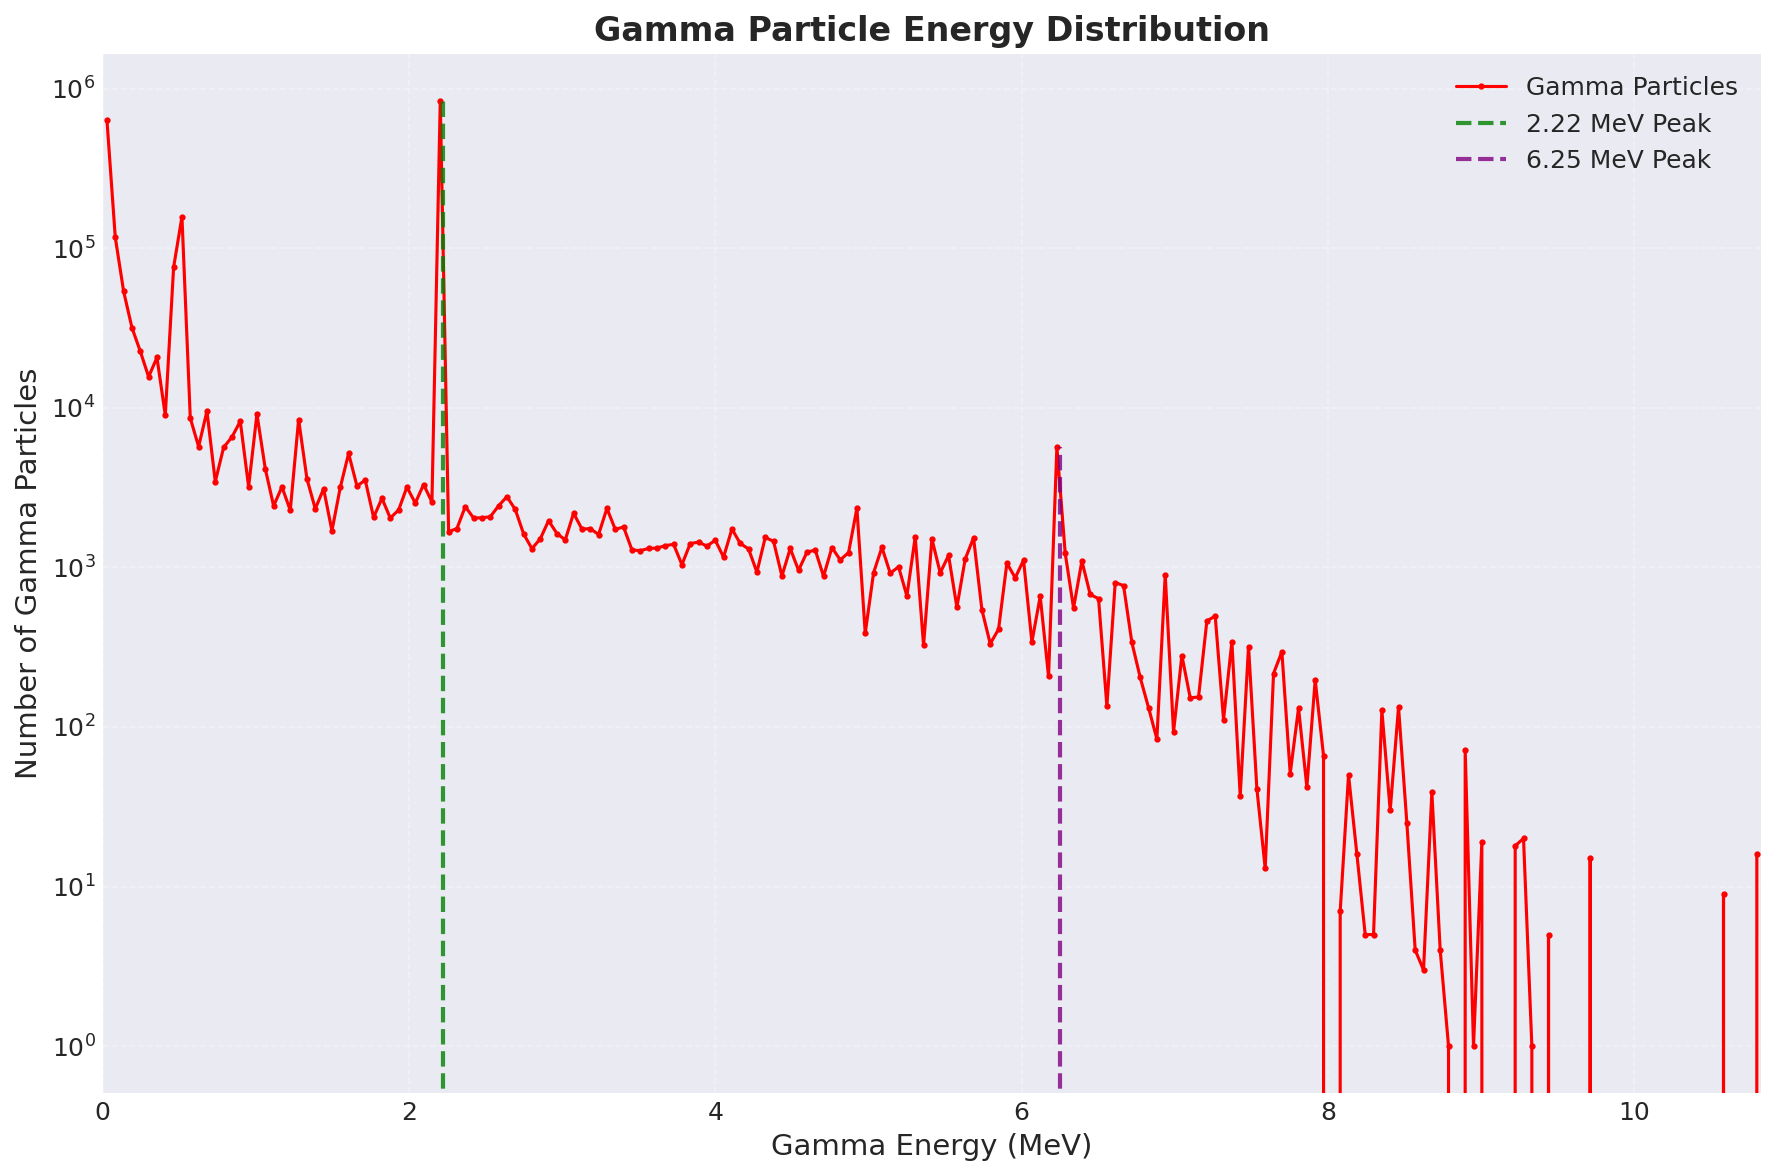


Figure saved as: figure_gamma_full_range.png
  Vertical line at 2.22 MeV extends to y = 837996
  Vertical line at 6.25 MeV extends to y = 5685

GAMMA PARTICLE STATISTICS (MeV)

Gamma Particles (All):
  Count: 2,215,884
  Mean energy: 1.210263 MeV
  Median energy: 0.510999 MeV
  Std dev: 1.265308 MeV
  Min energy: 0.000450 MeV
  Max energy: 10.829138 MeV

  Energy range distribution:
    < 1 keV:            332 (  0.0%)
    1-10 keV:       260,733 ( 11.8%)
    10-100 keV:     475,166 ( 21.4%)
    0.1-1 MeV:      453,638 ( 20.5%)
    1-10 MeV:      1,025,990 ( 46.3%)
    >10 MeV:             25 (  0.0%)

ANALYSIS COMPLETE


In [ ]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
import os

# Set publication-quality plot parameters
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.dpi'] = 150

print("Libraries imported successfully")

# ============================================================
# SPECIFY YOUR FILE HERE
# ============================================================

path = "Sim_D2ODetector308.root" 

if not os.path.exists(path):
    print(f"Error: {path} not found!")
    exit()

file = uproot.open(path)
Sim_Tree = file["Sim_Tree"]
event_data = Sim_Tree["eventData"]
print(f"File opened: {path}")
print(f"Total events: {Sim_Tree.num_entries}")

# ============================================================
# LOAD GAMMA DATA FROM ALL PARTICLES
# ============================================================
print("\nLoading gamma particle data...")

try:
    all_particle_pdg = event_data["allParticlePDG"].array()
    all_particle_energy = event_data["allParticleEnergy"].array()
    all_particle_parentID = event_data["allParticleParentID"].array()
    
    all_pdg_flat = ak.to_numpy(ak.flatten(all_particle_pdg))
    all_energy_flat = ak.to_numpy(ak.flatten(all_particle_energy))
    all_parentID_flat = ak.to_numpy(ak.flatten(all_particle_parentID))
    
    # Filter for gamma particles (PDG 22)
    gamma_particle_mask = (all_pdg_flat == 22)
    gamma_particle_energies = all_energy_flat[gamma_particle_mask]  # Already in MeV
    
    # Remove any zero or negative energies
    gamma_particle_energies = gamma_particle_energies[gamma_particle_energies > 0]
    
    n_all_gammas = len(gamma_particle_energies)
    
    print(f"  Total gamma particles: {n_all_gammas:,}")
    print(f"  Min gamma energy: {np.min(gamma_particle_energies):.6f} MeV")
    print(f"  Max gamma energy: {np.max(gamma_particle_energies):.6f} MeV")
    
except Exception as e:
    print(f"✗ Error loading gamma particle data: {e}")
    gamma_particle_energies = np.array([])
    n_all_gammas = 0

# ============================================================
# FIGURE: ALL GAMMA PARTICLES (Full range with vertical lines to peak)
# ============================================================
if n_all_gammas > 0:
    
    max_energy = np.max(gamma_particle_energies)
    
    # Define bins for full range
    bins_full = np.linspace(0, max_energy, 200)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Calculate histogram
    hist, bin_edges = np.histogram(gamma_particle_energies, bins=bins_full)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Plot the histogram as a line - changed color to orange
    ax.plot(bin_centers, hist, color='red', marker='o', markersize=2, 
            linewidth=1.5, label='Gamma Particles', linestyle='-')
    
    # Find the maximum y-value (peak of the histogram)
    max_y = np.max(hist)
    
    # Add vertical lines from x-axis up to the peak value at 2.22 MeV and 6.25 MeV
    # Find the histogram values at these specific energies
    idx_2p22 = np.argmin(np.abs(bin_centers - 2.22))
    idx_6p25 = np.argmin(np.abs(bin_centers - 6.25))
    
    y_2p22 = hist[idx_2p22]  # Height at 2.22 MeV
    y_6p25 = hist[idx_6p25]  # Height at 6.25 MeV
    
    # Draw vertical lines from 0 to the histogram height at those energies
    ax.vlines(x=2.22, ymin=0, ymax=y_2p22, colors='green', linestyles='--', 
              linewidth=2, alpha=0.8, label='2.22 MeV Peak')
    ax.vlines(x=6.25, ymin=0, ymax=y_6p25, colors='purple', linestyles='--', 
              linewidth=2, alpha=0.8, label='6.25 MeV Peak')
    
    ax.set_xlabel('Gamma Energy (MeV)', fontsize=14)
    ax.set_ylabel('Number of Gamma Particles', fontsize=14)
    ax.set_title('Gamma Particle Energy Distribution', fontsize=16, fontweight='bold')
    ax.set_xlim(0, max_energy)
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3, axis='both', linestyle='--')
    ax.legend(fontsize=12)
    
    plt.tight_layout()
    plt.savefig('figure_gamma_full_range.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nFigure saved as: figure_gamma_full_range.png")
    print(f"  Vertical line at 2.22 MeV extends to y = {y_2p22:.0f}")
    print(f"  Vertical line at 6.25 MeV extends to y = {y_6p25:.0f}")

else:
    print("\n" + "="*80)
    print("NO GAMMA PARTICLES FOUND")
    print("="*80)
    print("This is expected for EM shower simulation.")
    print("Gamma particles will appear when there are gamma interactions.")

# ============================================================
# PRINT GAMMA STATISTICS
# ============================================================
print("\n" + "="*80)
print("GAMMA PARTICLE STATISTICS (MeV)")
print("="*80)

if n_all_gammas > 0:
    print(f"\nGamma Particles (All):")
    print(f"  Count: {n_all_gammas:,}")
    print(f"  Mean energy: {np.mean(gamma_particle_energies):.6f} MeV")
    print(f"  Median energy: {np.median(gamma_particle_energies):.6f} MeV")
    print(f"  Std dev: {np.std(gamma_particle_energies):.6f} MeV")
    print(f"  Min energy: {np.min(gamma_particle_energies):.6f} MeV")
    print(f"  Max energy: {np.max(gamma_particle_energies):.6f} MeV")
    
    # Count gammas in specific energy ranges
    n_very_low = np.sum(gamma_particle_energies < 0.001)
    n_low = np.sum((gamma_particle_energies >= 0.001) & (gamma_particle_energies < 0.01))
    n_med_low = np.sum((gamma_particle_energies >= 0.01) & (gamma_particle_energies < 0.1))
    n_med = np.sum((gamma_particle_energies >= 0.1) & (gamma_particle_energies < 1))
    n_high = np.sum((gamma_particle_energies >= 1) & (gamma_particle_energies < 10))
    n_very_high = np.sum(gamma_particle_energies >= 10)
    
    print(f"\n  Energy range distribution:")
    print(f"    < 1 keV:       {n_very_low:>8,} ({100*n_very_low/n_all_gammas:>5.1f}%)")
    print(f"    1-10 keV:      {n_low:>8,} ({100*n_low/n_all_gammas:>5.1f}%)")
    print(f"    10-100 keV:    {n_med_low:>8,} ({100*n_med_low/n_all_gammas:>5.1f}%)")
    print(f"    0.1-1 MeV:     {n_med:>8,} ({100*n_med/n_all_gammas:>5.1f}%)")
    print(f"    1-10 MeV:      {n_high:>8,} ({100*n_high/n_all_gammas:>5.1f}%)")
    print(f"    >10 MeV:       {n_very_high:>8,} ({100*n_very_high/n_all_gammas:>5.1f}%)")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)

File opened: Sim_D2ODetector308.root
Total events: 1000000

Loading particle data...


✓ All particles data found

Identifying deuterons and tritium...
Deuterons found: 2,982,347
Tritium found: 5,568

Deuteron exponential fit (range: 16-1000 μs):
  A = 1795.7, τ = 161.8 μs, C = 259.5


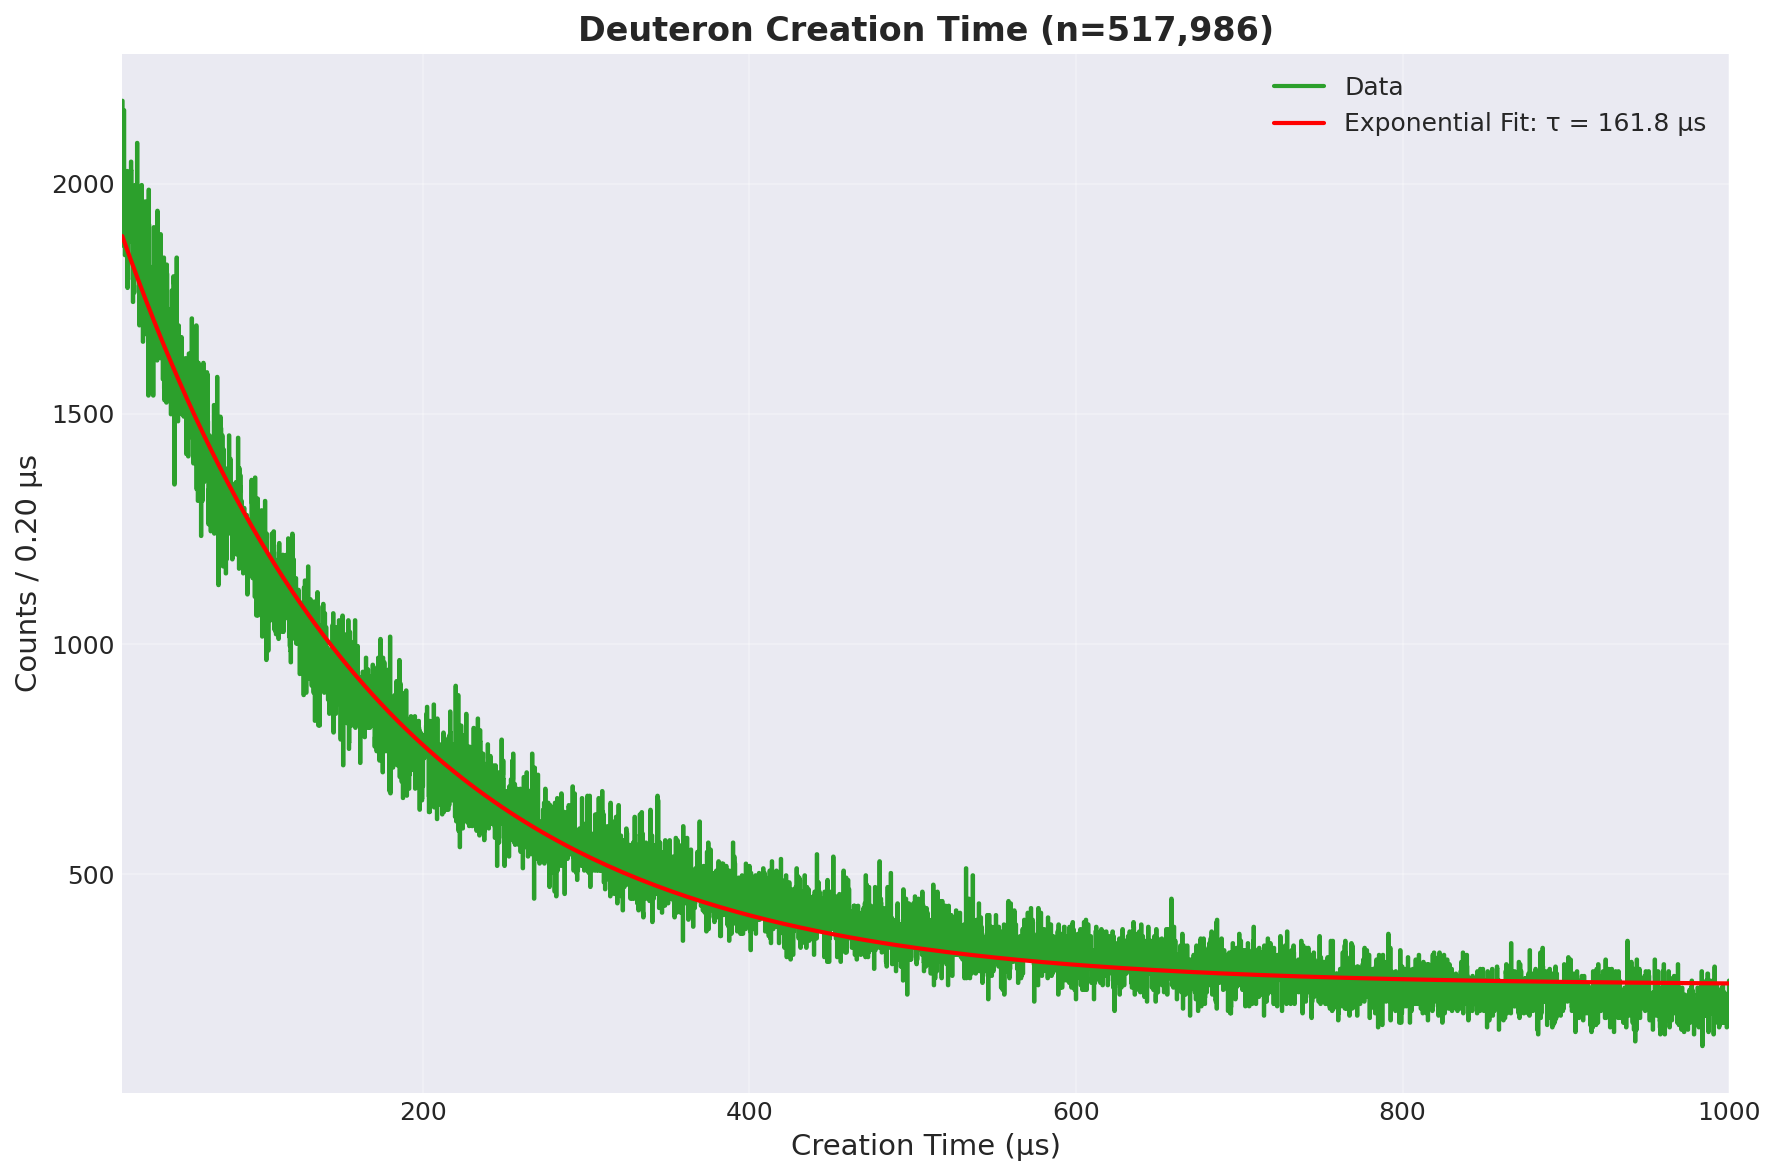


Tritium exponential fit (range: 16-10444 μs):
  A = 4.0, τ = 1363.6 μs, C = 0.0


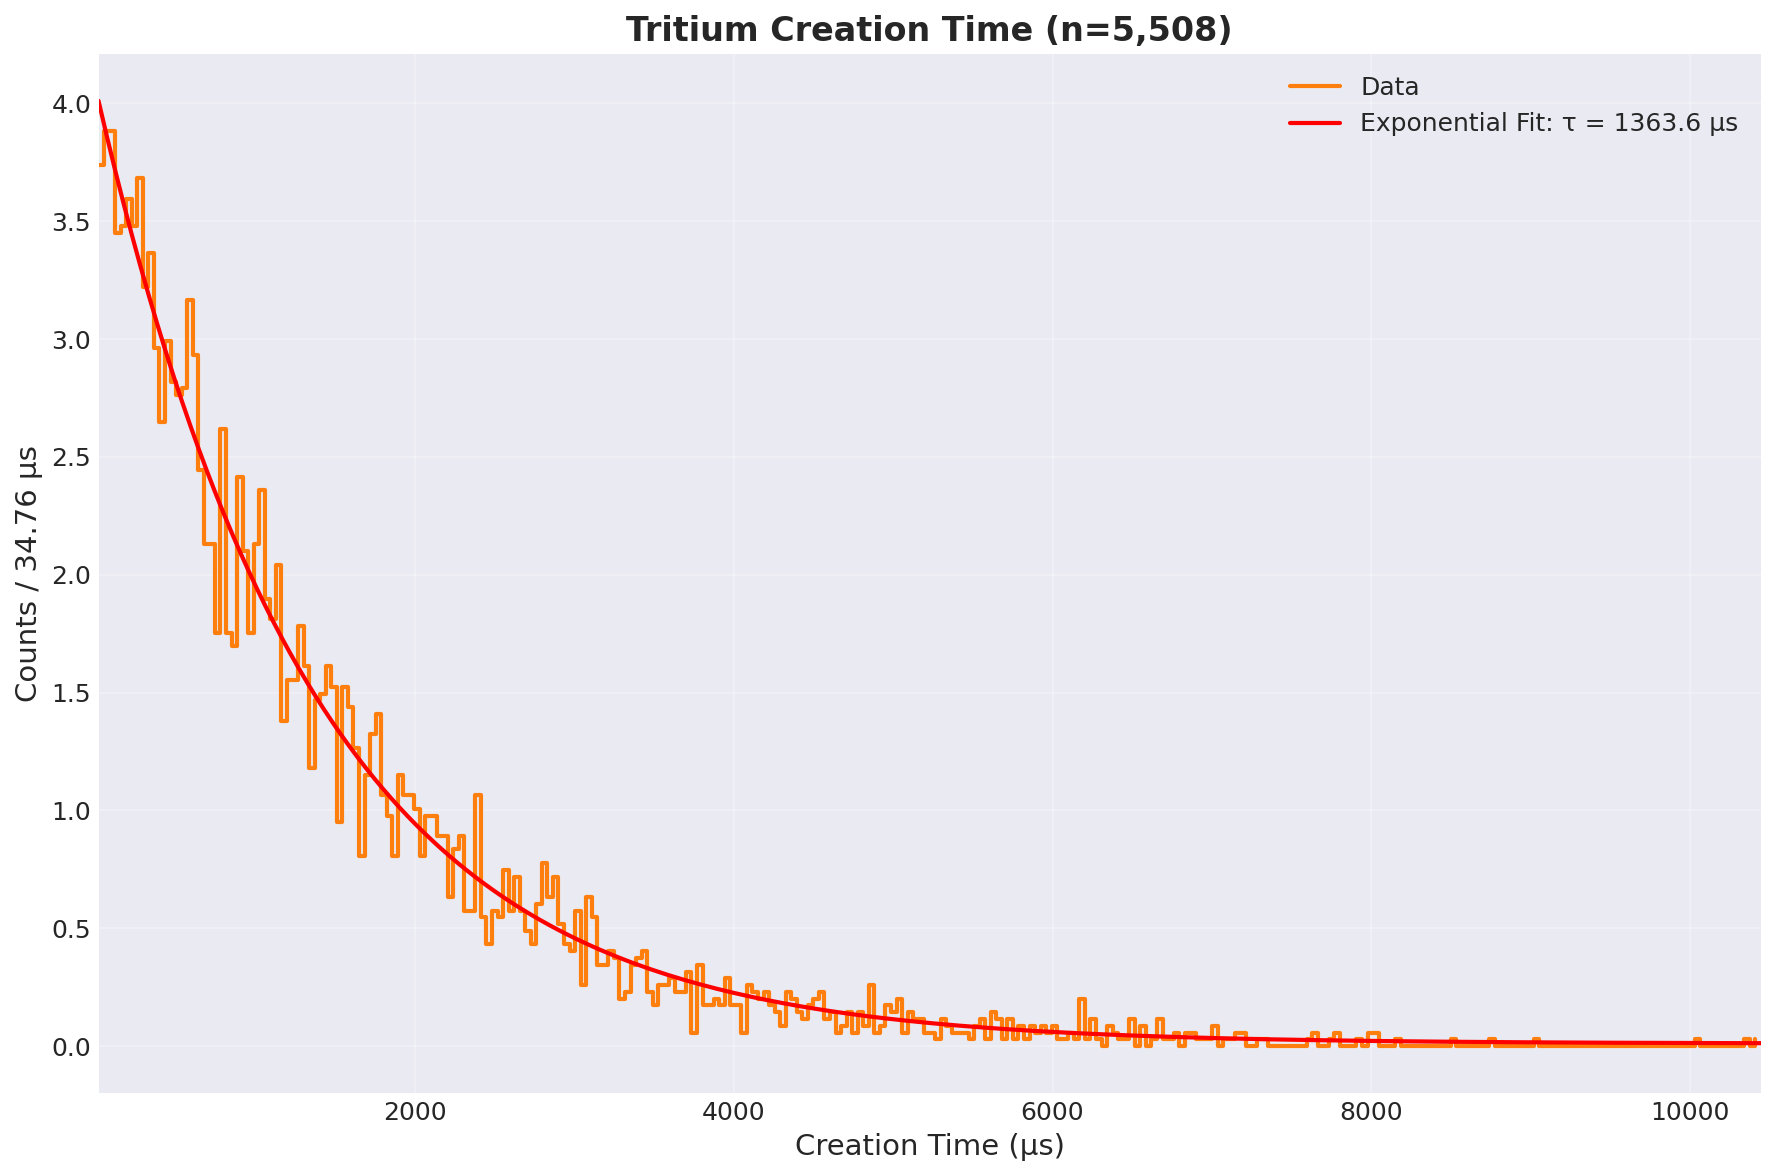

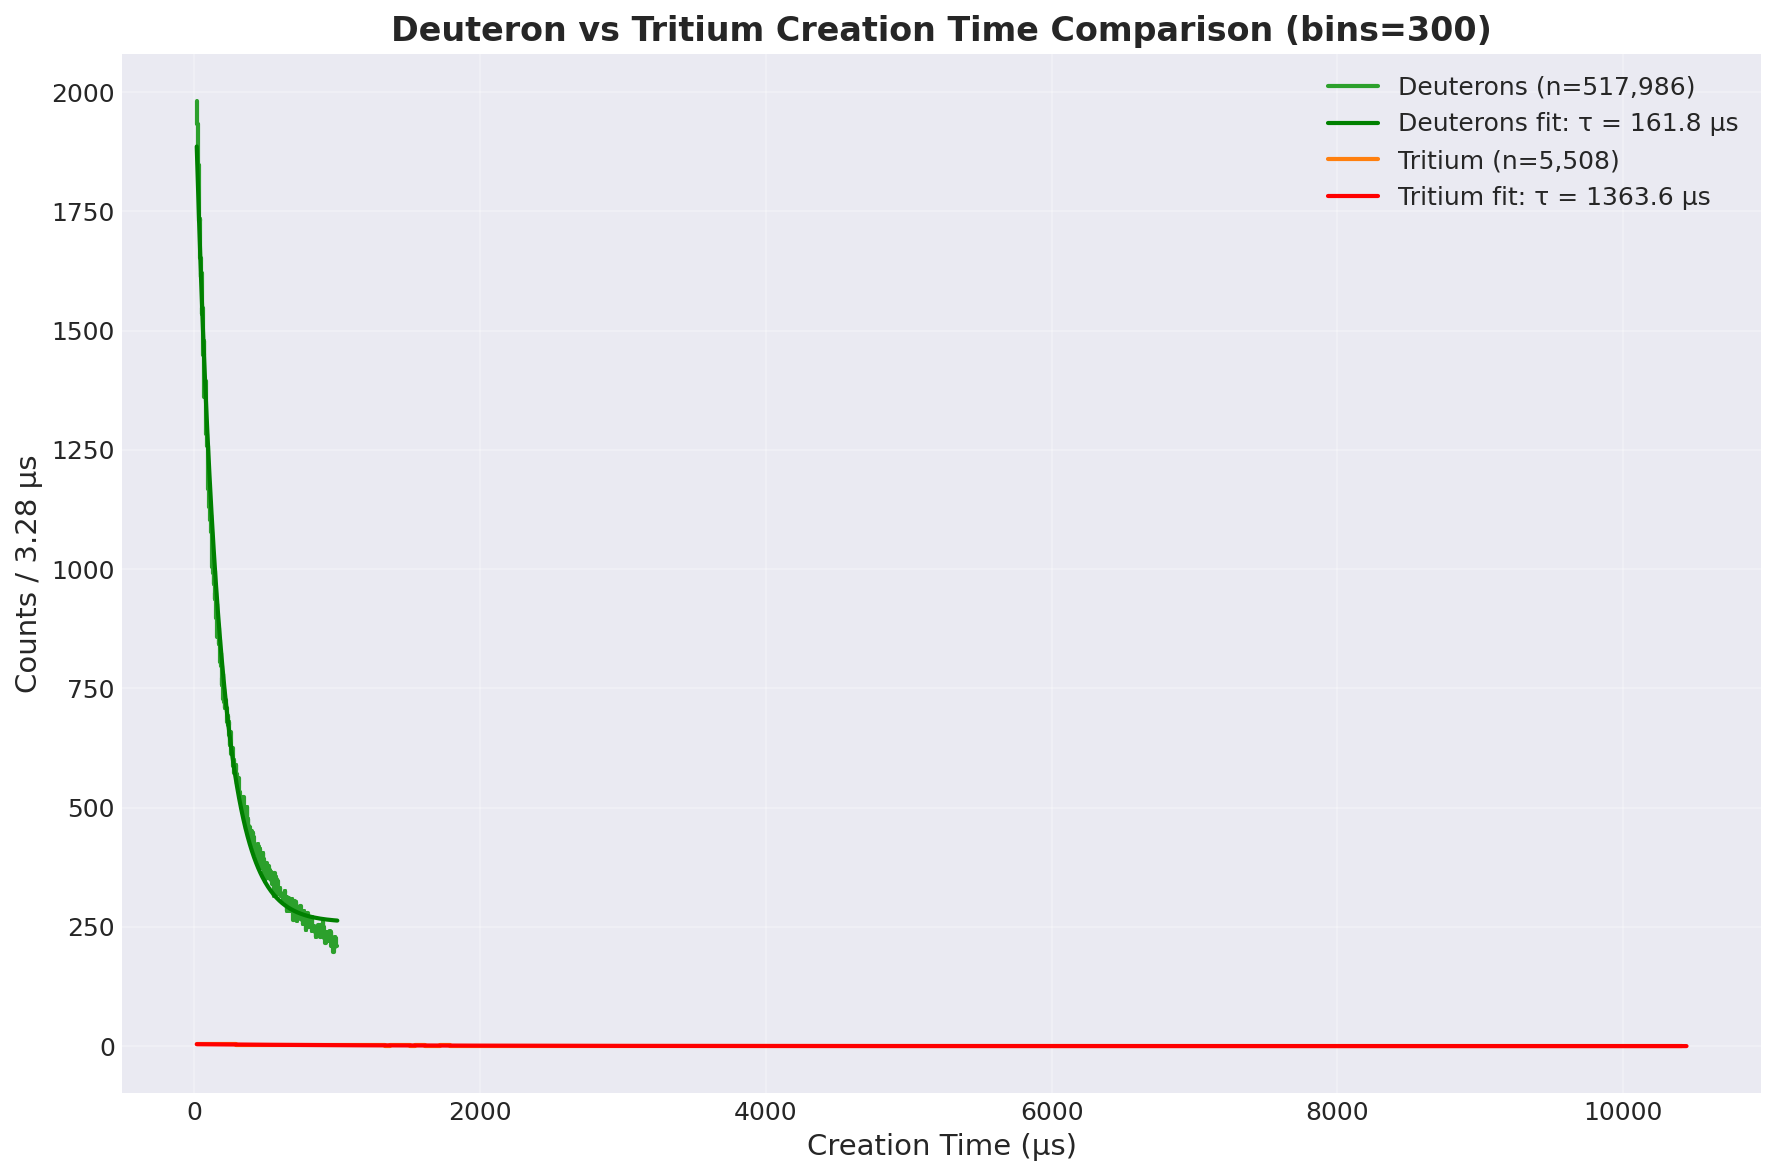

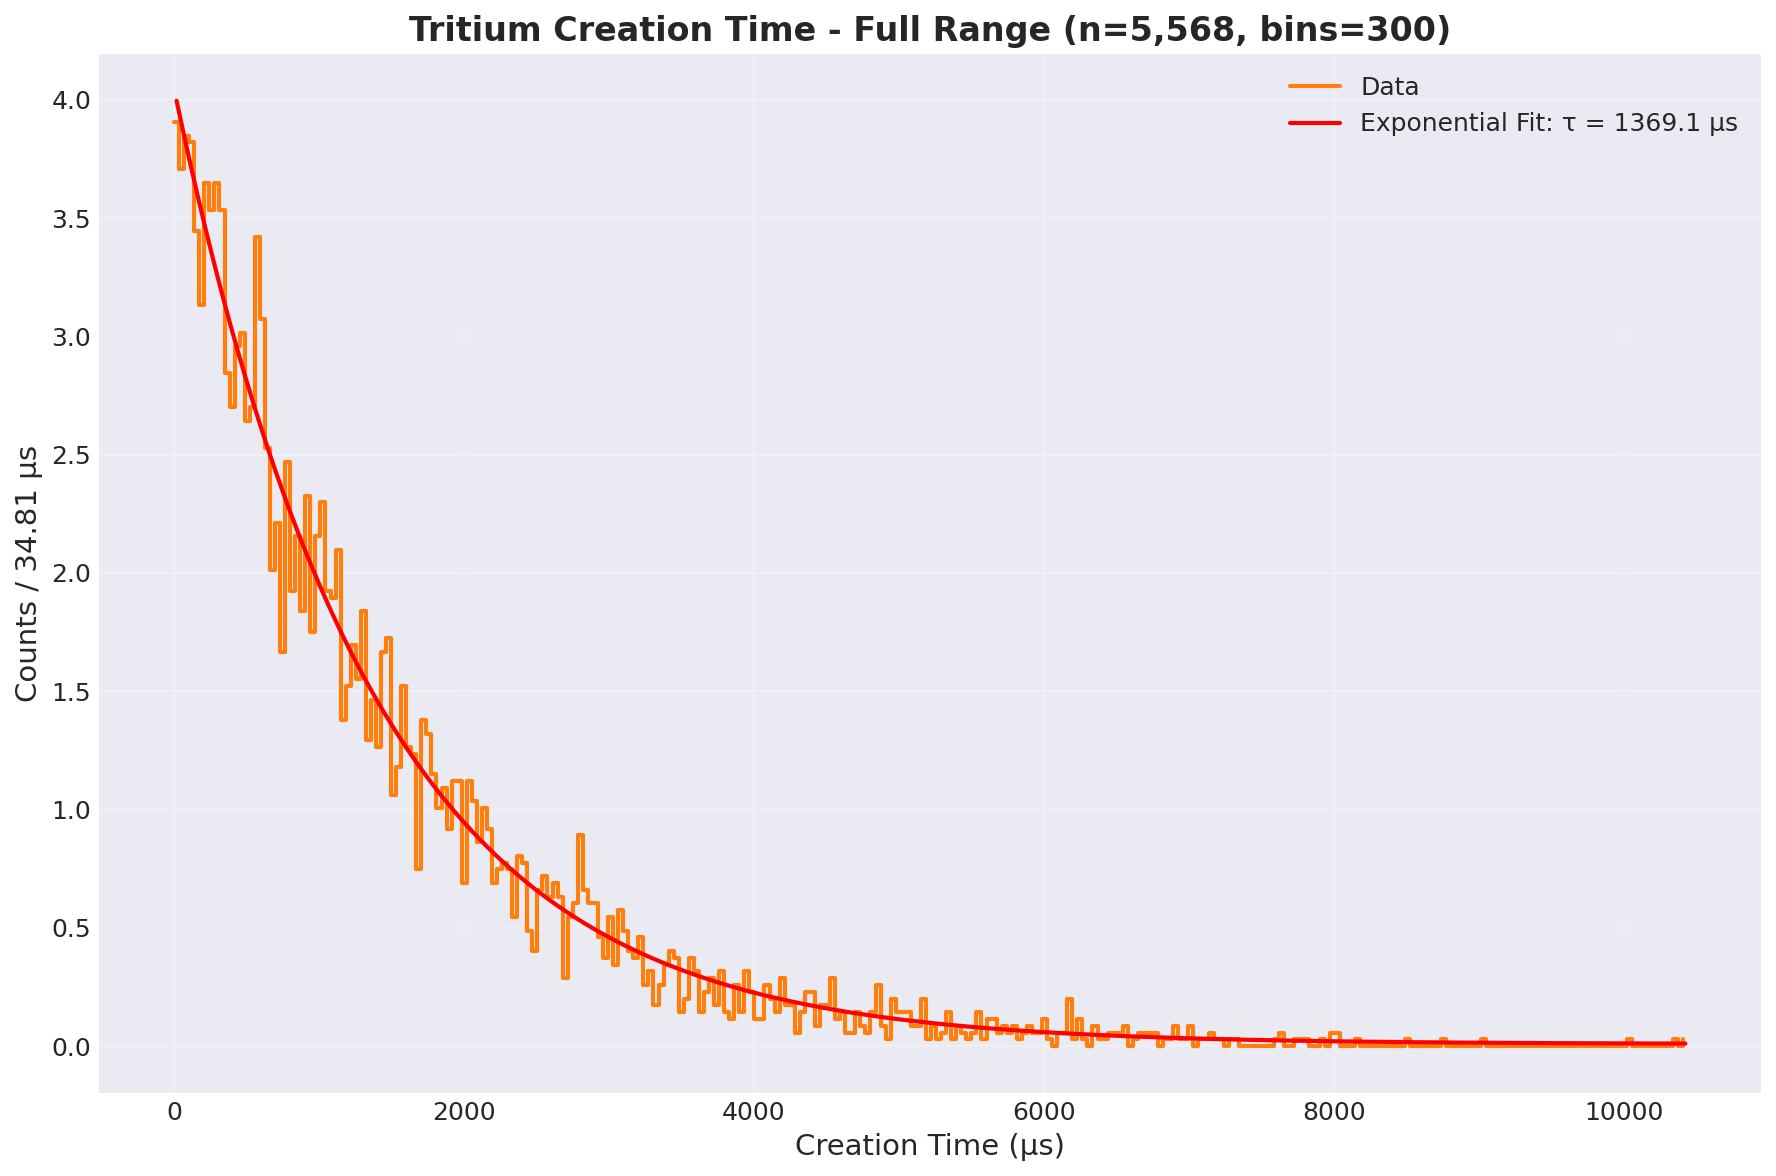


CREATION TIME STATISTICS

Deuterons (2,982,347 particles):
  Mean time (full range):   288.37 μs
  Median time (full range): 0.08 μs

  Statistics for 16-1000 μs range (n=517986):
    Mean time:   335.44 μs
    Median time: 250.53 μs

Tritium (5,568 particles):
  Mean time (full range):   1375.21 μs
  Median time (full range): 966.36 μs

  Statistics for ≥16 μs range (n=5508):
    Mean time:   1390.10 μs
    Median time: 982.07 μs

SUMMARY TABLE
Metric                                        Value               
-----------------------------------------------------------------
Deuterons (n + H → D + γ)                     2,982,347
Tritium (n + D → T + γ)                       5,568
Total Capture Products                        2,987,915
Deuteron Fraction                             99.8%
Tritium Fraction                              0.2%

FILES GENERATED
  - figure_deuteron.png
  - figure_tritium.png
  - figure_deuteron_tritium_overlay.png
  - figure_tritium_full_range.png

ANALYSIS C

In [ ]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
import os
from scipy.optimize import curve_fit

# ============================================================
# CONFIGURATION - ADJUST THESE PARAMETERS
# ============================================================
N_BINS_DEUTERON = 5000      # Number of bins for deuteron plot
N_BINS_TRITIUM = 300        # Number of bins for tritium plot
N_BINS_OVERLAY = 300        # Number of bins for overlay plot
N_BINS_FULL_RANGE = 300     # Number of bins for full range plot
BIN_RANGE_MIN = 16          # Minimum time range for plots
BIN_RANGE_MAX = 1000        # Maximum time range for deuteron plots

# ============================================================
# EXPONENTIAL FIT FUNCTION
# ============================================================
def exponential_decay(t, A, tau, C):
    """Exponential decay function: A * exp(-t/tau) + C"""
    return A * np.exp(-t / tau) + C

# ============================================================
# SPECIFY YOUR FILE HERE


if not os.path.exists(path):
    print(f"Error: {path} not found!")
    exit()

file = uproot.open(path)
Sim_Tree = file["Sim_Tree"]
event_data = Sim_Tree["eventData"]
print(f"File opened: {path}")
print(f"Total events: {Sim_Tree.num_entries}")

# ============================================================
# LOAD PARTICLE DATA
# ============================================================
print("\nLoading particle data...")

try:
    all_particle_pdg = event_data["allParticlePDG"].array()
    all_particle_time = event_data["allParticleTime"].array()
    has_all_particles = True
    print("✓ All particles data found")
except Exception as e:
    has_all_particles = False
    print(f"✗ All particles data not found: {e}")
    exit()

# ============================================================
# IDENTIFY DEUTERONS & TRITIUM
# ============================================================
print("\nIdentifying deuterons and tritium...")

all_pdg_flat = ak.to_numpy(ak.flatten(all_particle_pdg))
all_time_flat = ak.to_numpy(ak.flatten(all_particle_time))

# PDG codes
deuteron_pdg = 1000010020
tritium_pdg = 1000010030  # Tritium (not triton)

is_deuteron = (all_pdg_flat == deuteron_pdg)
is_tritium = (all_pdg_flat == tritium_pdg)

n_deuterons = np.sum(is_deuteron)
n_tritium = np.sum(is_tritium)

print(f"Deuterons found: {n_deuterons:,}")
print(f"Tritium found: {n_tritium:,}")

# ============================================================
# FIGURE 1: DEUTERON CREATION TIME
# ============================================================
fig, ax = plt.subplots(figsize=(12, 8))

if n_deuterons > 0:
    deuteron_times_us = all_time_flat[is_deuteron] / 1000
    
    # Define time range for deuterons (start from 16 μs)
    t_min = BIN_RANGE_MIN
    t_max = BIN_RANGE_MAX
    
    mask_plot = (deuteron_times_us >= t_min) & (deuteron_times_us <= t_max)
    deuteron_times_plot = deuteron_times_us[mask_plot]
    
    if len(deuteron_times_plot) > 0:
        # Use configurable number of bins
        hist, bin_edges = np.histogram(deuteron_times_plot, bins=N_BINS_DEUTERON, range=(t_min, t_max))
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        bin_width = bin_edges[1] - bin_edges[0]
        
        # Normalize by bin width to get counts per μs
        hist_norm = hist / bin_width
        
        # Plot as step histogram (stair-step line)
        ax.step(bin_edges[:-1], hist_norm, where='post', color='#2ca02c', linewidth=2, label='Data')
        
        # Fit exponential decay (fit to normalized data)
        mask_fit = hist > 0
        bin_centers_fit = bin_centers[mask_fit]
        hist_fit = hist[mask_fit] / bin_width  # Normalize fit data
        
        if len(bin_centers_fit) > 3:
            try:
                p0 = [max(hist_fit), 100, 0]
                popt, _ = curve_fit(exponential_decay, bin_centers_fit, hist_fit, p0=p0, maxfev=5000)
                x_fit = np.linspace(t_min, t_max, 200)
                y_fit = exponential_decay(x_fit, *popt)
                ax.plot(x_fit, y_fit, 'r-', linewidth=2, 
                        label=f'Exponential Fit: τ = {popt[1]:.1f} μs')
                
                print(f"\nDeuteron exponential fit (range: {t_min}-{t_max} μs):")
                print(f"  A = {popt[0]:.1f}, τ = {popt[1]:.1f} μs, C = {popt[2]:.1f}")
            except Exception as e:
                print(f"Fit failed for deuterons: {e}")
        
        ax.set_xlabel('Creation Time (μs)', fontsize=14)
        ax.set_ylabel(f'Counts / {bin_width:.2f} μs', fontsize=14)
        ax.set_title(f'Deuteron Creation Time (n={len(deuteron_times_plot):,})', 
                     fontsize=16, fontweight='bold')
        ax.set_xlim(t_min, t_max)
        ax.legend(fontsize=12)
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, f'No Deuterons in {t_min}-{t_max} μs range', 
                transform=ax.transAxes, ha='center', va='center', fontsize=14)
else:
    ax.text(0.5, 0.5, 'No Deuterons Found', transform=ax.transAxes, ha='center', va='center', fontsize=14)

plt.tight_layout()
plt.savefig('figure_deuteron.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# FIGURE 2: TRITIUM CREATION TIME
# ============================================================
fig, ax = plt.subplots(figsize=(12, 8))

if n_tritium > 0:
    tritium_times_us = all_time_flat[is_tritium] / 1000
    
    # Define time range for tritium (start from 16 μs)
    t_min = BIN_RANGE_MIN
    t_max = np.max(tritium_times_us)
    
    mask_plot = (tritium_times_us >= t_min)
    tritium_times_plot = tritium_times_us[mask_plot]
    
    if len(tritium_times_plot) > 0:
        # Use configurable number of bins
        hist, bin_edges = np.histogram(tritium_times_plot, bins=N_BINS_TRITIUM, range=(t_min, t_max))
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        bin_width = bin_edges[1] - bin_edges[0]
        
        # Normalize by bin width to get counts per μs
        hist_norm = hist / bin_width
        
        # Plot as step histogram (stair-step line)
        ax.step(bin_edges[:-1], hist_norm, where='post', color='#ff7f0e', linewidth=2, label='Data')
        
        # Fit exponential decay (fit to normalized data)
        mask_fit = hist > 0
        bin_centers_fit = bin_centers[mask_fit]
        hist_fit = hist[mask_fit] / bin_width  # Normalize fit data
        
        if len(bin_centers_fit) > 3:
            try:
                p0 = [max(hist_fit), np.mean(tritium_times_plot), 0]
                popt, _ = curve_fit(exponential_decay, bin_centers_fit, hist_fit, p0=p0, maxfev=5000)
                x_fit = np.linspace(t_min, t_max, 200)
                y_fit = exponential_decay(x_fit, *popt)
                ax.plot(x_fit, y_fit, 'r-', linewidth=2, 
                        label=f'Exponential Fit: τ = {popt[1]:.1f} μs')
                
                print(f"\nTritium exponential fit (range: {t_min}-{t_max:.0f} μs):")
                print(f"  A = {popt[0]:.1f}, τ = {popt[1]:.1f} μs, C = {popt[2]:.1f}")
            except Exception as e:
                print(f"Fit failed for tritium: {e}")
        
        ax.set_xlabel('Creation Time (μs)', fontsize=14)
        ax.set_ylabel(f'Counts / {bin_width:.2f} μs', fontsize=14)
        ax.set_title(f'Tritium Creation Time (n={len(tritium_times_plot):,})', 
                     fontsize=16, fontweight='bold')
        ax.set_xlim(t_min, t_max)
        ax.legend(fontsize=12)
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, f'No Tritium above {t_min} μs', 
                transform=ax.transAxes, ha='center', va='center', fontsize=14)
else:
    ax.text(0.5, 0.5, 'No Tritium Found', transform=ax.transAxes, ha='center', va='center', fontsize=14)

plt.tight_layout()
plt.savefig('figure_tritium.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# FIGURE 3: DEUTERON VS TRITIUM OVERLAY
# ============================================================
fig, ax = plt.subplots(figsize=(12, 8))

# Deuterons (16-1000 μs)
if n_deuterons > 0:
    deuteron_times_us = all_time_flat[is_deuteron] / 1000
    t_min_d = BIN_RANGE_MIN
    t_max_d = BIN_RANGE_MAX
    mask_d = (deuteron_times_us >= t_min_d) & (deuteron_times_us <= t_max_d)
    deuteron_times_plot = deuteron_times_us[mask_d]
    
    if len(deuteron_times_plot) > 0:
        hist_d, bin_edges_d = np.histogram(deuteron_times_plot, bins=N_BINS_OVERLAY, range=(t_min_d, t_max_d))
        bin_width_d = bin_edges_d[1] - bin_edges_d[0]
        hist_d_norm = hist_d / bin_width_d
        
        # Plot as step histogram (stair-step line)
        ax.step(bin_edges_d[:-1], hist_d_norm, where='post', color='#2ca02c', linewidth=2, 
                label=f'Deuterons (n={len(deuteron_times_plot):,})')
        
        # Fit for deuterons
        mask_fit_d = hist_d > 0
        bin_centers_fit_d = (bin_edges_d[:-1] + bin_edges_d[1:])[mask_fit_d] / 2
        hist_fit_d = hist_d[mask_fit_d] / bin_width_d
        
        if len(bin_centers_fit_d) > 3:
            try:
                p0 = [max(hist_fit_d), 100, 0]
                popt_d, _ = curve_fit(exponential_decay, bin_centers_fit_d, hist_fit_d, p0=p0, maxfev=5000)
                x_fit = np.linspace(t_min_d, t_max_d, 200)
                y_fit = exponential_decay(x_fit, *popt_d)
                ax.plot(x_fit, y_fit, 'g-', linewidth=2, 
                        label=f'Deuterons fit: τ = {popt_d[1]:.1f} μs')
            except:
                pass

# Tritium (16 μs to max)
if n_tritium > 0:
    tritium_times_us = all_time_flat[is_tritium] / 1000
    t_min_t = BIN_RANGE_MIN
    mask_t = (tritium_times_us >= t_min_t)
    tritium_times_plot = tritium_times_us[mask_t]
    
    if len(tritium_times_plot) > 0:
        t_max_t = np.max(tritium_times_plot)
        hist_t, bin_edges_t = np.histogram(tritium_times_plot, bins=N_BINS_OVERLAY, range=(t_min_t, t_max_t))
        bin_width_t = bin_edges_t[1] - bin_edges_t[0]
        hist_t_norm = hist_t / bin_width_t
        
        # Plot as step histogram (stair-step line)
        ax.step(bin_edges_t[:-1], hist_t_norm, where='post', color='#ff7f0e', linewidth=2, 
                label=f'Tritium (n={len(tritium_times_plot):,})')
        
        # Fit for tritium
        mask_fit_t = hist_t > 0
        bin_centers_fit_t = (bin_edges_t[:-1] + bin_edges_t[1:])[mask_fit_t] / 2
        hist_fit_t = hist_t[mask_fit_t] / bin_width_t
        
        if len(bin_centers_fit_t) > 3:
            try:
                p0 = [max(hist_fit_t), np.mean(tritium_times_plot), 0]
                popt_t, _ = curve_fit(exponential_decay, bin_centers_fit_t, hist_fit_t, p0=p0, maxfev=5000)
                x_fit = np.linspace(t_min_t, t_max_t, 200)
                y_fit = exponential_decay(x_fit, *popt_t)
                ax.plot(x_fit, y_fit, 'r-', linewidth=2, 
                        label=f'Tritium fit: τ = {popt_t[1]:.1f} μs')
            except:
                pass

ax.set_xlabel('Creation Time (μs)', fontsize=14)
ax.set_ylabel(f'Counts / {bin_width_d:.2f} μs', fontsize=14)
ax.set_title(f'Deuteron vs Tritium Creation Time Comparison (bins={N_BINS_OVERLAY})', 
             fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figure_deuteron_tritium_overlay.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# FIGURE 4: TRITIUM CREATION TIME - FULL RANGE
# ============================================================
if n_tritium > 0:
    fig, ax = plt.subplots(figsize=(12, 8))
    
    tritium_times_us = all_time_flat[is_tritium] / 1000
    
    # Use configurable number of bins for full range
    hist, bin_edges = np.histogram(tritium_times_us, bins=N_BINS_FULL_RANGE)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = bin_edges[1] - bin_edges[0]
    
    # Normalize by bin width to get counts per μs
    hist_norm = hist / bin_width
    
    # Plot as step histogram (stair-step line)
    ax.step(bin_edges[:-1], hist_norm, where='post', color='#ff7f0e', linewidth=2, label='Data')
    
    # Fit exponential decay (fit to normalized data)
    mask_fit = hist > 0
    bin_centers_fit = bin_centers[mask_fit]
    hist_fit = hist[mask_fit] / bin_width  # Normalize fit data
    
    if len(bin_centers_fit) > 3:
        try:
            p0 = [max(hist_fit), np.mean(tritium_times_us), 0]
            popt, _ = curve_fit(exponential_decay, bin_centers_fit, hist_fit, p0=p0, maxfev=5000)
            x_fit = np.linspace(min(bin_centers), max(bin_centers), 200)
            y_fit = exponential_decay(x_fit, *popt)
            ax.plot(x_fit, y_fit, 'r-', linewidth=2, 
                    label=f'Exponential Fit: τ = {popt[1]:.1f} μs')
        except:
            pass
    
    ax.set_xlabel('Creation Time (μs)', fontsize=14)
    ax.set_ylabel(f'Counts / {bin_width:.2f} μs', fontsize=14)
    ax.set_title(f'Tritium Creation Time - Full Range (n={n_tritium:,}, bins={N_BINS_FULL_RANGE})', 
                 fontsize=16, fontweight='bold')
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('figure_tritium_full_range.png', dpi=300, bbox_inches='tight')
    plt.show()

# ============================================================
# STATISTICS SUMMARY
# ============================================================
print("\n" + "="*80)
print("CREATION TIME STATISTICS")
print("="*80)

if n_deuterons > 0:
    deuteron_times_us = all_time_flat[is_deuteron] / 1000
    print(f"\nDeuterons ({n_deuterons:,} particles):")
    print(f"  Mean time (full range):   {np.mean(deuteron_times_us):.2f} μs")
    print(f"  Median time (full range): {np.median(deuteron_times_us):.2f} μs")
    
    mask_range = (deuteron_times_us >= BIN_RANGE_MIN) & (deuteron_times_us <= BIN_RANGE_MAX)
    if np.sum(mask_range) > 0:
        range_times = deuteron_times_us[mask_range]
        print(f"\n  Statistics for {BIN_RANGE_MIN}-{BIN_RANGE_MAX} μs range (n={len(range_times)}):")
        print(f"    Mean time:   {np.mean(range_times):.2f} μs")
        print(f"    Median time: {np.median(range_times):.2f} μs")

if n_tritium > 0:
    tritium_times_us = all_time_flat[is_tritium] / 1000
    print(f"\nTritium ({n_tritium:,} particles):")
    print(f"  Mean time (full range):   {np.mean(tritium_times_us):.2f} μs")
    print(f"  Median time (full range): {np.median(tritium_times_us):.2f} μs")
    
    # Statistics for times >= BIN_RANGE_MIN
    mask_range = (tritium_times_us >= BIN_RANGE_MIN)
    if np.sum(mask_range) > 0:
        range_times = tritium_times_us[mask_range]
        print(f"\n  Statistics for ≥{BIN_RANGE_MIN} μs range (n={len(range_times)}):")
        print(f"    Mean time:   {np.mean(range_times):.2f} μs")
        print(f"    Median time: {np.median(range_times):.2f} μs")

else:
    print("\n" + "="*80)
    print("NO DEUTERONS OR TRITIUM FOUND")
    print("="*80)

# ============================================================
# SUMMARY TABLE
# ============================================================
print("\n" + "="*80)
print("SUMMARY TABLE")
print("="*80)
print(f"{'Metric':<45} {'Value':<20}")
print("-"*65)
print(f"{'Deuterons (n + H → D + γ)':<45} {n_deuterons:,}")
print(f"{'Tritium (n + D → T + γ)':<45} {n_tritium:,}")
print(f"{'Total Capture Products':<45} {n_deuterons + n_tritium:,}")

if n_deuterons + n_tritium > 0:
    print(f"{'Deuteron Fraction':<45} {100 * n_deuterons / (n_deuterons + n_tritium):.1f}%")
    print(f"{'Tritium Fraction':<45} {100 * n_tritium / (n_deuterons + n_tritium):.1f}%")

print("\n" + "="*80)
print("FILES GENERATED")
print("="*80)
if n_deuterons > 0 or n_tritium > 0:
    print("  - figure_deuteron.png")
    print("  - figure_tritium.png")
    print("  - figure_deuteron_tritium_overlay.png")
    if n_tritium > 0:
        print("  - figure_tritium_full_range.png")
else:
    print("  No plots generated (no deuterons or tritium found)")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)

BACKUP CODES (!!DONOT DELETE!!)

In [ ]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
import os
from matplotlib.colors import LogNorm

# Set publication-quality plot parameters
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.dpi'] = 150

print("Libraries imported successfully")

# ============================================================
# SPECIFY YOUR FILE HERE
# ============================================================
path = "Sim_D2ODetector307.root" 

if not os.path.exists(path):
    print(f"Error: {path} not found!")
    exit()

file = uproot.open(path)
Sim_Tree = file["Sim_Tree"]
event_data = Sim_Tree["eventData"]
print(f"File opened: {path}")
print(f"Total events: {Sim_Tree.num_entries}")

# ============================================================
# LOAD ALL DATA
# ============================================================
print("\nLoading data...")

# PMT hit data
pmt_hits = event_data["pmtHits"].array()
pmt_num = pmt_hits["pmtHits.pmtNum"]
pmt_parent_type = pmt_hits["pmtHits.parentType"]
pmt_time = pmt_hits["pmtHits.eventTime"]
pmt_energy = pmt_hits["pmtHits.photonEnergy"]

print("Data loaded successfully")

# ============================================================
# APPLY QUALITY CUTS
# ============================================================
print("\nApplying quality cuts...")

n_events_all = len(pmt_num)

# Quality cut: at least 2 distinct PMTs per event
pass_mask = []
for evt in pmt_num:
    evt_np = np.asarray(ak.to_numpy(evt), dtype=np.int64)
    counts_12 = np.bincount(evt_np, minlength=12)[:12]
    n_distinct_pmts = np.sum(counts_12 >= 1)
    pass_mask.append(n_distinct_pmts >= 2)
pass_mask = np.asarray(pass_mask, dtype=bool)

# Apply cut
pmt_num_sel = pmt_num[pass_mask]
pmt_parent_type_sel = pmt_parent_type[pass_mask]

totalPE = ak.num(pmt_num_sel, axis=1)
totalPE_np = ak.to_numpy(totalPE)

print(f"Events before cuts: {n_events_all}")
print(f"Events after cuts: {len(totalPE_np)}")
print(f"Cut efficiency: {len(totalPE_np)/n_events_all:.3f}")

# Flatten for analysis
pmt_num_flat = ak.to_numpy(ak.flatten(pmt_num_sel))
pmt_parent_type_flat = ak.to_numpy(ak.flatten(pmt_parent_type_sel))
pmt_time_flat = ak.to_numpy(ak.flatten(pmt_time_sel))
pmt_energy_flat = ak.to_numpy(ak.flatten(pmt_energy_sel)) * 1000  # Convert to eV

print(f"Total detected photons after cuts: {len(pmt_num_flat)}")

# ============================================================
# PARENT TYPE MAPPING (INDEX → MEANING)
# ============================================================
print("\n" + "="*80)
print("PARENT TYPE INDEX MAPPING")
print("="*80)
print("""
┌─────────────────────────────────────────────────────────────────────────────────────┐
│  INDEX  │  NAME                    │  MEANING (Origin of particle that created     │
│         │                          │  the Cherenkov light)                         │
├─────────┼──────────────────────────┼─────────────────────────────────────────────────┤
│    1    │  Muon                    │  Muon itself                                   │
│    2    │  Michel e⁻               │  Electron from muon decay μ⁻ → e⁻ + ν̄ₑ + ν_μ   │
│    3    │  EM Shower e⁻            │  Electron from Compton, photoelectric, pair    │
│    4    │  Unclassified            │  Default / Not classified                      │
│    5    │  Neutron Capture γ       │  Gamma from n+H→D+γ (2.22MeV) or n+D→T+γ(6.25) │
│    6    │  EM Shower γ             │  Gamma from bremsstrahlung, nuclear de-excit.  │
│    7    │  Delta Ray               │  High-energy electron from ionization          │
│    8    │  Primary e⁻              │  Electron directly from beam/primary source    │
│    9    │  Radioactive Decay       │  Particle from radioactive decay (beta, alpha) │
│   10    │  Neutron Inelastic       │  Gamma/particle from neutron inelastic scatter │
│   11    │  Cosmic Ray γ            │  High-energy gamma from cosmic ray primary     │
└─────────┴──────────────────────────┴─────────────────────────────────────────────────┘
""")

# Short labels for plots
parent_labels = {
    1: 'Muon',
    2: 'Michel e⁻ (μ decay)',
    3: 'EM Shower e⁻ (Compton, Photo, Pair)',
    4: 'Unclassified',
    5: 'Neutron Capture γ',
    6: 'EM Shower γ (Bremsstrahlung)',
    7: 'Delta Ray (Ionization e⁻)',
    8: 'Primary e⁻ (Beam)',
    9: 'Radioactive Decay',
    10: 'Neutron Inelastic',
    11: 'Cosmic Ray γ'
}

# Get unique parent types from data
unique_pt, pt_counts = np.unique(pmt_parent_type_flat, return_counts=True)

# ============================================================
# PRINT DETECTED PARENT TYPES WITH PERCENTAGES
# ============================================================
print("\n" + "="*80)
print(f"DETECTED PARENT TYPES IN THIS FILE ({os.path.basename(path)})")
print("="*80)
print(f"{'Index':<8} {'Origin of Light-Producing Particle':<45} {'Count':<12} {'Percentage':<10}")
print("-"*80)
for pt, count in zip(unique_pt, pt_counts):
    label = parent_labels.get(pt, f'Unknown Type {pt}')
    percentage = 100 * count / len(pmt_parent_type_flat)
    bar = "█" * int(percentage / 2)
    print(f"{pt:<8} {label:<45} {count:<12,} {percentage:<10.2f}% {bar}")

# ============================================================
# FIGURE 1: PARENT TYPE DISTRIBUTION (Particle Origin Classification)
# ============================================================
fig, ax = plt.subplots(figsize=(14, 8))

pt_labels = [parent_labels.get(pt, f'Type {pt}') for pt in unique_pt]
colors = plt.cm.Set3(np.linspace(0, 1, len(unique_pt)))
bars = ax.bar(range(len(unique_pt)), pt_counts, color=colors, edgecolor='black', alpha=0.8, linewidth=1.5)

ax.set_xlabel('Parent Type Index (See legend for meaning)', fontsize=14)
ax.set_ylabel('Counts', fontsize=14)  # ← CORRECTED: Not "PMT Hits", just "Counts"
ax.set_title(f'Particle Origin Classification', fontsize=16, fontweight='bold')
ax.set_xticks(range(len(unique_pt)))
ax.set_xticklabels([f'Type {pt}' for pt in unique_pt], fontsize=12)

# Add value labels on bars
for bar, count, pt in zip(bars, pt_counts, unique_pt):
    percentage = 100 * count / len(pmt_parent_type_flat)
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
            f'{count:,}\n({percentage:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add a text box with the legend
legend_text = "Parent Type Legend:\n"
for pt in unique_pt:
    legend_text += f"  Type {pt}: {parent_labels.get(pt, f'Unknown')}\n"

ax.text(0.98, 0.98, legend_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_yscale('log')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('figure_parent_type_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# FIGURE 2: PMT Hit Pattern and Distribution
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# PMT hit pattern (2D histogram) - This is where photons hit PMTs
ax = axes[0, 0]
pmt_hits_per_event = np.zeros((min(200, len(pmt_num_sel)), 12))
for i in range(min(200, len(pmt_num_sel))):
    evt_pmts = ak.to_numpy(pmt_num_sel[i])
    for pmt in evt_pmts:
        if 0 <= pmt < 12:
            pmt_hits_per_event[i, pmt] += 1

im = ax.imshow(pmt_hits_per_event, aspect='auto', cmap='viridis', interpolation='nearest')
ax.set_xlabel('PMT Number', fontsize=12)
ax.set_ylabel('Event Number', fontsize=12)
ax.set_title('(a) PMT Hit Pattern (First 200 Events) - Photons Detected', fontsize=14)
ax.set_xticks(range(12))
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Number of Photons', fontsize=11)

# PMT hit counts
ax = axes[0, 1]
pmt_counts = np.bincount(pmt_num_flat, minlength=12)[:12]
bars = ax.bar(range(12), pmt_counts, color='steelblue', edgecolor='black', alpha=0.8)
ax.set_xlabel('PMT Number', fontsize=12)
ax.set_ylabel('Total Number of Detected Photons', fontsize=12)
ax.set_title('(b) PMT Hit Distribution', fontsize=14)
ax.set_xticks(range(12))
for bar, count in zip(bars, pmt_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, 
            f'{count}', ha='center', va='bottom', fontsize=9)

# Total PE distribution (Photoelectrons per event)
ax = axes[1, 0]
ax.hist(totalPE_np, bins=50, range=(0, 100), color='coral', edgecolor='black', alpha=0.7)
ax.set_xlabel('Total Photoelectrons per Event', fontsize=12)
ax.set_ylabel('Number of Events', fontsize=12)
ax.set_title('(c) Total PE Distribution', fontsize=14)
ax.axvline(np.mean(totalPE_np), color='red', linestyle='--', 
           label=f'Mean: {np.mean(totalPE_np):.1f}')
ax.axvline(np.median(totalPE_np), color='green', linestyle='--', 
           label=f'Median: {np.median(totalPE_np):.1f}')
ax.legend(fontsize=10)

# Mean PE per PMT
ax = axes[1, 1]
mean_pe_per_pmt = pmt_counts / len(pmt_num_sel)
ax.bar(range(12), mean_pe_per_pmt, color='teal', edgecolor='black', alpha=0.8)
ax.set_xlabel('PMT Number', fontsize=12)
ax.set_ylabel('Mean Photons per Event', fontsize=12)
ax.set_title('(d) Mean PMT Activity', fontsize=14)
ax.set_xticks(range(12))

plt.suptitle('PMT Performance Analysis - Photon Detection', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('figure_pmt_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# FIGURE 3: Photon Timing and Energy by Parent Type
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Time distribution
ax = axes[0, 0]
ax.hist(pmt_time_flat, bins=100, range=(0, 200), color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('Time (ns)', fontsize=12)
ax.set_ylabel('Number of Photons', fontsize=12)
ax.set_title('(a) Photon Arrival Time Distribution', fontsize=14)
ax.axvline(np.mean(pmt_time_flat), color='red', linestyle='--', 
           label=f'Mean: {np.mean(pmt_time_flat):.1f} ns')
ax.legend(fontsize=10)

# Energy distribution
ax = axes[0, 1]
ax.hist(pmt_energy_flat, bins=100, range=(0, 10), color='coral', edgecolor='black', alpha=0.7)
ax.set_xlabel('Photon Energy (eV)', fontsize=12)
ax.set_ylabel('Number of Photons', fontsize=12)
ax.set_title('(b) Photon Energy Distribution', fontsize=14)
ax.set_yscale('log')
ax.axvline(np.mean(pmt_energy_flat), color='red', linestyle='--', 
           label=f'Mean: {np.mean(pmt_energy_flat):.2f} eV')
ax.legend(fontsize=10)

# Time vs Energy 2D
ax = axes[1, 0]
h2d = ax.hist2d(pmt_time_flat[:50000], pmt_energy_flat[:50000], bins=80, 
                cmap='viridis', norm=LogNorm())
ax.set_xlabel('Time (ns)', fontsize=12)
ax.set_ylabel('Photon Energy (eV)', fontsize=12)
ax.set_title('(c) Time vs Energy Correlation', fontsize=14)
cbar = plt.colorbar(h2d[3], ax=ax)
cbar.set_label('Number of Photons', fontsize=11)

# Energy by parent type
ax = axes[1, 1]
for pt in unique_pt:
    mask = pmt_parent_type_flat == pt
    if np.sum(mask) > 100:
        label = parent_labels.get(pt, f'Type {pt}')
        ax.hist(pmt_energy_flat[mask], bins=50, range=(0, 10), alpha=0.5, 
                label=f'Type {pt}: {label[:20]}', histtype='stepfilled')
ax.set_xlabel('Photon Energy (eV)', fontsize=12)
ax.set_ylabel('Number of Photons (log scale)', fontsize=12)
ax.set_title('(d) Photon Energy Spectrum by Parent Type', fontsize=14)
ax.set_yscale('log')
ax.legend(loc='upper right', fontsize=8, ncol=2)

plt.suptitle('Photon Characteristics by Origin', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('figure_timing_energy.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# FIGURE 4: PMT vs Parent Type Correlation
# ============================================================
fig, ax = plt.subplots(figsize=(12, 8))

# Create 2D histogram
pt_bins = np.arange(0, 13, 1)
h2d = ax.hist2d(pmt_num_flat[:100000], pmt_parent_type_flat[:100000], 
                bins=[12, pt_bins], cmap='plasma', norm=LogNorm())
ax.set_xlabel('PMT Number', fontsize=12)
ax.set_ylabel('Parent Type Index', fontsize=12)
ax.set_title('Which PMTs Detect Photons from Each Parent Type?', fontsize=14)
ax.set_xlim(-0.5, 11.5)
ax.set_ylim(0, 12)
ax.set_yticks(range(1, 12))
ax.set_yticklabels([f'{i}' for i in range(1, 12)])
cbar = plt.colorbar(h2d[3], ax=ax)
cbar.set_label('Number of Photons (log scale)', fontsize=11)

plt.tight_layout()
plt.savefig('figure_pmt_vs_parent.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# EXPLANATION OF THE CHAIN
# ============================================================
print("\n" + "="*80)
print("UNDERSTANDING THE DETECTION CHAIN")
print("="*80)
print("""
┌─────────────────────────────────────────────────────────────────────────────────────┐
│  STEP 1: Physical Process                    → Parent Type tells you THIS          │
│         (Compton, neutron capture, etc.)                                           │
│                    ↓                                                               │
│  STEP 2: Charged Particle (usually e⁻)       → This particle produces light        │
│                    ↓                                                               │
│  STEP 3: Cherenkov Photons                   → What the PMT actually detects       │
│                    ↓                                                               │
│  STEP 4: PMT Hit                             → What we record                      │
└─────────────────────────────────────────────────────────────────────────────────────┘

The PARENT TYPE in the plot tells you what happened in STEP 1.
The y-axis shows COUNTS of how many detected photons originated from each process.
""")

# ============================================================
# SUMMARY TABLE
# ============================================================
print("\n" + "="*80)
print("SUMMARY TABLE")
print("="*80)
print(f"{'Metric':<40} {'Value':<20}")
print("-"*60)
print(f"{'File':<40} {os.path.basename(path)}")
print(f"{'Total Events':<40} {n_events_all:,}")
print(f"{'Events After Quality Cuts':<40} {len(totalPE_np):,}")
print(f"{'Total Detected Photons':<40} {len(pmt_num_flat):,}")
print(f"{'Mean Photons per Event':<40} {np.mean(totalPE_np):.1f}")
print(f"{'Median Photons per Event':<40} {np.median(totalPE_np):.1f}")
print(f"{'Mean Photon Energy':<40} {np.mean(pmt_energy_flat):.2f} eV")
print(f"{'Mean Photon Time':<40} {np.mean(pmt_time_flat):.1f} ns")

print("\n" + "="*80)
print(f"DETECTED PARENT TYPES IN {os.path.basename(path)}")
print("="*80)
for pt, count in zip(unique_pt, pt_counts):
    label = parent_labels.get(pt, f'Unknown Type {pt}')
    percentage = 100 * count / len(pmt_parent_type_flat)
    print(f"  Type {pt:2d}: {label:<45} {count:>8,} ({percentage:>5.2f}% of detected photons)")

print("\n" + "="*80)
print("FILES GENERATED")
print("="*80)
print("  - figure_parent_type_distribution.png  (Particle origin classification)")
print("  - figure_pmt_analysis.png               (PMT hit patterns)")
print("  - figure_timing_energy.png              (Photon timing and energy)")
print("  - figure_pmt_vs_parent.png              (PMT vs parent type correlation)")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)

In [ ]:
#!/usr/bin/env python
import uproot
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
from matplotlib.patches import Circle, Patch
from scipy.optimize import curve_fit
from collections import defaultdict

# ============================================================
# THESIS-STYLE PLOT SETTINGS
# ============================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "legend.fontsize": 11,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "axes.linewidth": 1.2,
    "lines.linewidth": 1.8,
    "figure.figsize": (12.8, 6.2),
    "figure.dpi": 140,
})

DEUTERON_PDG = 1000010020
GAMMA_PDG = 22
ELECTRON_PDG = 11

# ============================================================
# LOAD DATA
# ============================================================
path = "Sim_D2ODetector003.root"
file = uproot.open(path)
event_data = file["Sim_Tree"]["eventData"]

all_pdg = event_data["allParticlePDG"].array()
all_track = event_data["allParticleTrackID"].array()
all_parent = event_data["allParticleParentID"].array()
all_time = event_data["allParticleTime"].array()
all_energy = event_data["allParticleEnergy"].array()
all_posX = event_data["allParticlePosX"].array()
all_posY = event_data["allParticlePosY"].array()
all_posZ = event_data["allParticlePosZ"].array()

pdg = ak.to_numpy(ak.flatten(all_pdg))
track = ak.to_numpy(ak.flatten(all_track))
parent = ak.to_numpy(ak.flatten(all_parent))
time = ak.to_numpy(ak.flatten(all_time))
energy = ak.to_numpy(ak.flatten(all_energy))
posX = ak.to_numpy(ak.flatten(all_posX))
posY = ak.to_numpy(ak.flatten(all_posY))
posZ = ak.to_numpy(ak.flatten(all_posZ))

print(f"Total particles: {len(pdg):,}")

# ============================================================
# FIND CAPTURE GAMMAS (2.22 MeV)
# ============================================================
print("Finding capture gammas (2.22 MeV)...")

# Filter for gammas with energy near 2.22 MeV
gamma_mask = (pdg == GAMMA_PDG) & (energy > 2.0) & (energy < 2.5)
gamma_indices = np.where(gamma_mask)[0]
print(f"Capture gammas (2.22 MeV): {len(gamma_indices):,}")

if len(gamma_indices) == 0:
    raise SystemExit("No capture gammas found. Check simulation or energy cut.")

# ============================================================
# BUILD GAMMA -> ELECTRON LOOKUP (fast)
# ============================================================
print("Building gamma -> electron lookup...")

gamma_to_electrons = defaultdict(list)
for i, (p, par) in enumerate(zip(pdg, parent)):
    if p == ELECTRON_PDG:
        gamma_to_electrons[par].append(i)

print(f"Gamma parents with electrons: {len(gamma_to_electrons):,}")

# ============================================================
# EXTRACT COMPTON ELECTRONS
# ============================================================
print("Extracting Compton electrons...")

capture_times = []       # μs
capture_energies = []    # MeV
capture_positions = []   # (x,y,z) cm
capture_gamma_times = [] # μs

for g_idx in gamma_indices:
    gamma_track = track[g_idx]
    gamma_time = time[g_idx] / 1000.0  # ns -> μs
    
    for e_idx in gamma_to_electrons.get(gamma_track, []):
        e_energy = energy[e_idx]
        e_time = time[e_idx] / 1000.0
        # Only keep Compton electrons (energy > 0.1 MeV)
        # and creation time similar to gamma (within ~ns)
        if e_energy > 0.1 and abs(e_time - gamma_time) < 0.01:  # within 10 ns
            capture_times.append(e_time)
            capture_energies.append(e_energy)
            capture_positions.append((posX[e_idx], posY[e_idx], posZ[e_idx]))
            capture_gamma_times.append(gamma_time)

capture_times = np.array(capture_times)
capture_energies = np.array(capture_energies)
capture_positions = np.array(capture_positions)
capture_gamma_times = np.array(capture_gamma_times)

print(f"Compton electrons found: {len(capture_times):,}")
print(f"Fraction: {100 * len(capture_times) / max(1, len(gamma_indices)):.1f}% of gammas produced electrons")

if len(capture_times) == 0:
    raise SystemExit("No Compton electrons found. Try lowering the energy threshold.")

# ============================================================
# EXPONENTIAL DECAY FIT
# ============================================================
def exp_decay(t, A, tau, C):
    return A * np.exp(-t / tau) + C

# ============================================================
# PLOT 1: XY POSITIONS
# ============================================================
fig, ax = plt.subplots()
sc = ax.scatter(capture_positions[:,0], capture_positions[:,1],
                c=capture_times, cmap='viridis', s=15, alpha=0.7,
                edgecolors='black', linewidth=0.3)

boundaries = [(33.5, 'D₂O', 'blue'), (42.5, 'Acrylic', 'magenta'),
              (48.5, 'Tyvek', 'gray'), (52.5, 'Steel', 'darkgray')]
for r, label, col in boundaries:
    circle = Circle((0,0), r, fill=False, edgecolor=col, linestyle='--', linewidth=1.5)
    ax.add_patch(circle)

ax.set_xlabel('X Position (cm)', fontweight='bold')
ax.set_ylabel('Y Position (cm)', fontweight='bold')
ax.set_title(f'Neutron Capture Positions (XY)', pad=15, fontweight='bold')
ax.set_aspect('equal'); ax.set_xlim(-60,60); ax.set_ylim(-60,60)
cbar = plt.colorbar(sc); cbar.set_label('Capture Time (μs)', fontsize=12)

legend_elements = [Patch(facecolor='none', edgecolor=c, linestyle='--', linewidth=2, label=l)
                   for _, l, c in boundaries]
ax.legend(handles=legend_elements, loc='upper right', frameon=True,
          framealpha=0.96, fancybox=False, edgecolor='black')
ax.grid(True, linestyle='--', alpha=0.4); ax.minorticks_on()
ax.tick_params(which='both', direction='in', top=True, right=True)
ax.tick_params(which='major', length=6, width=1.2)
ax.tick_params(which='minor', length=3, width=0.8)
plt.tight_layout(); plt.savefig('fig1_capture_positions.png', dpi=300, bbox_inches='tight'); plt.close()
print("✓ Saved fig1_capture_positions.png")

# ============================================================
# PLOT 2: CAPTURE TIME DISTRIBUTION + EXPONENTIAL FIT
# ============================================================
fig, ax = plt.subplots()
bins = np.linspace(0, 500, 100)
hist, edges = np.histogram(capture_times, bins=bins)
centers = (edges[:-1] + edges[1:]) / 2
width = edges[1] - edges[0]
norm = hist / width

ax.step(centers, norm, where='mid', color='#1f77b4', linewidth=2, label=f'Data (n={len(capture_times):,})')
ax.plot(centers, norm, 'o', color='#1f77b4', markersize=3,
        markerfacecolor='white', markeredgecolor='#1f77b4')

# Fit
mask = (centers > 50) & (norm > 0)
if np.sum(mask) > 5:
    popt, _ = curve_fit(exp_decay, centers[mask], norm[mask], p0=[max(norm), 100, 0])
    x_fit = np.linspace(0, 500, 200)
    ax.plot(x_fit, exp_decay(x_fit, *popt), 'r-', linewidth=2,
            label=f'Fit: τ = {popt[1]:.1f} μs')
    print(f"Fit result: τ = {popt[1]:.1f} μs")

mean_t = np.mean(capture_times); median_t = np.median(capture_times)
ax.axvline(mean_t, color='red', linestyle='--', alpha=0.7, label=f'Mean: {mean_t:.1f} μs')
ax.axvline(median_t, color='green', linestyle='--', alpha=0.7, label=f'Median: {median_t:.1f} μs')

ax.set_xlabel('Capture Time (μs)', fontweight='bold')
ax.set_ylabel(f'Counts / {width:.1f} μs', fontweight='bold')
ax.set_title('Neutron Capture Time Distribution (Compton Electrons)', pad=15, fontweight='bold')
ax.set_xlim(0, 500); ax.set_yscale('log')
ax.legend(frameon=True, framealpha=0.96, fancybox=False, edgecolor='black')
ax.grid(True, linestyle='--', alpha=0.4); ax.minorticks_on()
ax.tick_params(which='both', direction='in', top=True, right=True)
plt.tight_layout(); plt.savefig('fig2_capture_time_fit.png', dpi=300, bbox_inches='tight'); plt.close()
print("✓ Saved fig2_capture_time_fit.png")

# ============================================================
# PLOT 3: DEUTERON ENERGY SPECTRUM (for verification)
# ============================================================
is_deuteron = (pdg == DEUTERON_PDG)
deuteron_energies_keV = energy[is_deuteron] * 1000

fig, ax = plt.subplots()
bins_e = np.linspace(0, 2.0, 50)
hist_e, edges_e = np.histogram(deuteron_energies_keV, bins=bins_e)
centers_e = (edges_e[:-1] + edges_e[1:]) / 2
width_e = edges_e[1] - edges_e[0]
norm_e = hist_e / width_e

ax.step(centers_e, norm_e, where='mid', color='#9467bd', linewidth=2,
        label=f'Deuterons (n={len(deuteron_energies_keV):,})')
ax.plot(centers_e, norm_e, 'o', color='#9467bd', markersize=3,
        markerfacecolor='white', markeredgecolor='#9467bd')
ax.axvline(1.3, color='red', linestyle='--', linewidth=2, label='Expected (1.3 keV)')

ax.set_xlabel('Deuteron Energy (keV)', fontweight='bold')
ax.set_ylabel(f'Counts / {width_e:.2f} keV', fontweight='bold')
ax.set_title('Deuteron Energy Spectrum (n + H → D + γ)', pad=15, fontweight='bold')
ax.legend(frameon=True, framealpha=0.96, fancybox=False, edgecolor='black')
ax.grid(True, linestyle='--', alpha=0.4); ax.minorticks_on()
ax.tick_params(which='both', direction='in', top=True, right=True)
plt.tight_layout(); plt.savefig('fig3_deuteron_energy.png', dpi=300, bbox_inches='tight'); plt.close()
print("✓ Saved fig3_deuteron_energy.png")

# ============================================================
# PLOT 4: TIME VS RADIAL POSITION
# ============================================================
radii = np.sqrt(capture_positions[:,0]**2 + capture_positions[:,1]**2)

fig, ax = plt.subplots()
sc = ax.scatter(radii, capture_times, c=capture_energies, cmap='plasma',
                s=15, alpha=0.6, edgecolors='black', linewidth=0.3)
ax.axvline(33.5, color='blue', linestyle='--', alpha=0.7, label='D₂O boundary')
ax.axvline(42.5, color='magenta', linestyle='--', alpha=0.7, label='Acrylic boundary')

ax.set_xlabel('Radial Position (cm)', fontweight='bold')
ax.set_ylabel('Capture Time (μs)', fontweight='bold')
ax.set_title('Capture Time vs Radial Position', pad=15, fontweight='bold')
ax.set_xlim(0, 60)
cbar = plt.colorbar(sc); cbar.set_label('Electron Energy (MeV)', fontsize=12)
ax.legend(frameon=True, framealpha=0.96, fancybox=False, edgecolor='black')
ax.grid(True, linestyle='--', alpha=0.4); ax.minorticks_on()
ax.tick_params(which='both', direction='in', top=True, right=True)
plt.tight_layout(); plt.savefig('fig4_time_vs_radius.png', dpi=300, bbox_inches='tight'); plt.close()
print("✓ Saved fig4_time_vs_radius.png")

# ============================================================
# SUMMARY
# ============================================================
print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"Capture gammas (2.22 MeV):        {len(gamma_indices):,}")
print(f"Compton electrons found:          {len(capture_times):,}")
print(f"Fraction of gammas producing e⁻:  {100 * len(capture_times) / max(1, len(gamma_indices)):.1f}%")
print(f"Mean capture time:                {np.mean(capture_times):.2f} μs")
print(f"Median capture time:              {np.median(capture_times):.2f} μs")
print("\nFigures saved:")
print("  - fig1_capture_positions.png")
print("  - fig2_capture_time_fit.png")
print("  - fig3_deuteron_energy.png")
print("  - fig4_time_vs_radius.png")
print("="*80)

In [ ]:
#!/usr/bin/env python
"""
Neutron Capture Analysis Script
===============================
Extracts Compton electrons from neutron capture gammas (2.22 MeV) and
generates thesis‑style plots with exponential fit and error.

Physics:
    n + H → D + γ (2.22 MeV) → Compton electron → Cherenkov light

Outputs:
    - fig1_capture_positions.png     : XY positions with volume boundaries
    - fig2_capture_time_fit.png      : Time distribution + exponential fit (τ ± error)
    - fig3_deuteron_energy.png       : Deuteron energy spectrum (1.3 keV peak)
    - fig4_time_vs_radius.png        : Time vs radial position
"""

import uproot
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
from matplotlib.patches import Circle, Patch
from scipy.optimize import curve_fit
from collections import defaultdict
import os
import sys

# ============================================================
# THESIS-STYLE PLOT SETTINGS
# ============================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "legend.fontsize": 11,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "axes.linewidth": 1.2,
    "lines.linewidth": 1.8,
    "figure.figsize": (12.8, 6.2),
    "figure.dpi": 140,
})

# ============================================================
# PDG CODES
# ============================================================
DEUTERON_PDG = 1000010020
TRITIUM_PDG = 1000010030
GAMMA_PDG = 22
ELECTRON_PDG = 11
NEUTRON_PDG = 2112

# ============================================================
# FIT FUNCTION
# ============================================================
def exponential_decay(t, A, tau, C):
    """
    Exponential decay: A * exp(-t/tau) + C
    
    Parameters:
    -----------
    t : array_like
        Time values (μs)
    A : float
        Amplitude
    tau : float
        Decay constant (neutron lifetime, μs)
    C : float
        Constant offset
    
    Returns:
    --------
    array_like : Fitted values
    """
    return A * np.exp(-t / tau) + C

# ============================================================
# CONFIGURATION
# ============================================================
# Adjust these as needed
COMPTON_ENERGY_THRESHOLD = 0.1      # MeV (minimum electron energy)
GAMMA_ENERGY_MIN = 2.0              # MeV
GAMMA_ENERGY_MAX = 2.5              # MeV
TIME_BINS = 100                     # Number of bins for time histogram
TIME_RANGE_MAX = 500                # μs
FIT_RANGE_START = 50                # μs (start fit after this time)
TIME_RANGE_MIN = 0                  # μs

# ============================================================
# SPECIFY YOUR ROOT FILE
# ============================================================
path = "Sim_D2ODetector003.root"   # <-- CHANGE THIS TO YOUR FILE

if not os.path.exists(path):
    print(f"Error: File '{path}' not found!")
    print("Please update the 'path' variable with the correct file path.")
    sys.exit(1)

# ============================================================
# LOAD DATA
# ============================================================
print("="*80)
print("NEUTRON CAPTURE ANALYSIS")
print("="*80)
print(f"File: {path}")

file = uproot.open(path)
Sim_Tree = file["Sim_Tree"]
event_data = Sim_Tree["eventData"]

print(f"Total events: {Sim_Tree.num_entries:,}")

# Load and flatten particle data
print("\nLoading particle data...")
all_pdg = event_data["allParticlePDG"].array()
all_track = event_data["allParticleTrackID"].array()
all_parent = event_data["allParticleParentID"].array()
all_time = event_data["allParticleTime"].array()
all_energy = event_data["allParticleEnergy"].array()
all_posX = event_data["allParticlePosX"].array()
all_posY = event_data["allParticlePosY"].array()
all_posZ = event_data["allParticlePosZ"].array()

pdg = ak.to_numpy(ak.flatten(all_pdg))
track = ak.to_numpy(ak.flatten(all_track))
parent = ak.to_numpy(ak.flatten(all_parent))
time = ak.to_numpy(ak.flatten(all_time))
energy = ak.to_numpy(ak.flatten(all_energy))
posX = ak.to_numpy(ak.flatten(all_posX))
posY = ak.to_numpy(ak.flatten(all_posY))
posZ = ak.to_numpy(ak.flatten(all_posZ))

print(f"Total particles: {len(pdg):,}")

# ============================================================
# FIND DEUTERONS (n + H → D + γ)
# ============================================================
print("\nFinding capture products...")

is_deuteron = (pdg == DEUTERON_PDG)
is_tritium = (pdg == TRITIUM_PDG)
deuteron_indices = np.where(is_deuteron)[0]
tritium_indices = np.where(is_tritium)[0]

n_deuterons = len(deuteron_indices)
n_tritium = len(tritium_indices)

print(f"Deuterons (n + H → D + γ): {n_deuterons:,}")
print(f"Tritium (n + D → T + γ):   {n_tritium:,}")

if n_deuterons == 0 and n_tritium == 0:
    print("\n⚠️ No capture products found!")
    print("Possible reasons:")
    print("  1. No neutron captures occurred")
    print("  2. NeutronTreatment = 0 in beamOn.dat (need HP physics)")
    print("  3. Run more events")
    sys.exit(1)

# ============================================================
# FIND CAPTURE GAMMAS (2.22 MeV from H capture)
# ============================================================
print("\nFinding capture gammas (2.22 MeV)...")

gamma_mask = (pdg == GAMMA_PDG) & (energy > GAMMA_ENERGY_MIN) & (energy < GAMMA_ENERGY_MAX)
gamma_indices = np.where(gamma_mask)[0]
n_gammas = len(gamma_indices)

print(f"Capture gammas (2.22 MeV): {n_gammas:,}")

if n_gammas == 0:
    print("\n⚠️ No capture gammas found!")
    print("Try adjusting GAMMA_ENERGY_MIN/MAX or check your simulation.")
    sys.exit(1)

# ============================================================
# BUILD GAMMA -> ELECTRON LOOKUP (Fast O(N))
# ============================================================
print("Building gamma -> electron lookup...")

gamma_to_electrons = defaultdict(list)
for i, (p, par) in enumerate(zip(pdg, parent)):
    if p == ELECTRON_PDG:
        gamma_to_electrons[par].append(i)

n_gamma_parents = len(gamma_to_electrons)
print(f"Gamma parents with electrons: {n_gamma_parents:,}")

# ============================================================
# EXTRACT COMPTON ELECTRONS
# ============================================================
print("Extracting Compton electrons...")

capture_times = []       # μs
capture_energies = []    # MeV
capture_positions = []   # (x,y,z) in cm
capture_gamma_times = [] # μs

for g_idx in gamma_indices:
    gamma_track = track[g_idx]
    gamma_time = time[g_idx] / 1000.0  # ns -> μs
    
    for e_idx in gamma_to_electrons.get(gamma_track, []):
        e_energy = energy[e_idx]
        e_time = time[e_idx] / 1000.0
        # Only keep Compton electrons above threshold
        # and created within ~10 ns of the gamma
        if e_energy > COMPTON_ENERGY_THRESHOLD and abs(e_time - gamma_time) < 0.01:
            capture_times.append(e_time)
            capture_energies.append(e_energy)
            capture_positions.append((posX[e_idx], posY[e_idx], posZ[e_idx]))
            capture_gamma_times.append(gamma_time)

capture_times = np.array(capture_times)
capture_energies = np.array(capture_energies)
capture_positions = np.array(capture_positions)
capture_gamma_times = np.array(capture_gamma_times)

n_captures = len(capture_times)
print(f"Compton electrons found: {n_captures:,}")

if n_captures == 0:
    print("\n⚠️ No Compton electrons found!")
    print(f"Try lowering COMPTON_ENERGY_THRESHOLD (currently {COMPTON_ENERGY_THRESHOLD} MeV)")
    sys.exit(1)

# Calculate fraction
fraction = 100 * n_captures / n_gammas
print(f"Fraction of gammas producing electrons: {fraction:.1f}%")

# ============================================================
# STATISTICS
# ============================================================
print("\n" + "="*60)
print("CAPTURE ELECTRON STATISTICS")
print("="*60)
print(f"Total:          {n_captures:,}")
print(f"Mean time:      {np.mean(capture_times):.2f} μs")
print(f"Median time:    {np.median(capture_times):.2f} μs")
print(f"Std dev:        {np.std(capture_times):.2f} μs")
print(f"Min time:       {np.min(capture_times):.2f} μs")
print(f"Max time:       {np.max(capture_times):.2f} μs")
print(f"Mean energy:    {np.mean(capture_energies):.3f} MeV")

# ============================================================
# FIGURE 1: XY CAPTURE POSITIONS
# ============================================================
print("\nGenerating Figure 1: Capture Positions (XY)")

fig, ax = plt.subplots()

sc = ax.scatter(capture_positions[:,0], capture_positions[:,1],
                c=capture_times, cmap='viridis', s=15, alpha=0.7,
                edgecolors='black', linewidth=0.3)

# Volume boundaries (adjust to your detector geometry)
boundaries = [
    (33.5, 'D₂O', 'blue'),
    (42.5, 'Acrylic', 'magenta'),
    (48.5, 'Tyvek', 'gray'),
    (52.5, 'Steel', 'darkgray'),
]

for r, label, col in boundaries:
    circle = Circle((0, 0), r, fill=False, edgecolor=col, 
                    linestyle='--', linewidth=1.5, alpha=0.7)
    ax.add_patch(circle)
    ax.text(r, -r - 3, label, color=col, fontsize=10, ha='center', fontweight='bold')

ax.set_xlabel('X Position (cm)', fontweight='bold')
ax.set_ylabel('Y Position (cm)', fontweight='bold')
ax.set_title(f'Neutron Capture Positions (XY)\n(n={n_captures:,})', pad=15, fontweight='bold')
ax.set_aspect('equal')
ax.set_xlim(-60, 60)
ax.set_ylim(-60, 60)

cbar = plt.colorbar(sc)
cbar.set_label('Capture Time (μs)', fontsize=12)

# Legend
legend_elements = [
    Patch(facecolor='none', edgecolor=c, linestyle='--', linewidth=2, label=l)
    for _, l, c in boundaries
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True,
          framealpha=0.96, fancybox=False, edgecolor='black')

ax.grid(True, linestyle='--', alpha=0.4)
ax.minorticks_on()
ax.tick_params(which='both', direction='in', top=True, right=True)
ax.tick_params(which='major', length=6, width=1.2)
ax.tick_params(which='minor', length=3, width=0.8)

plt.tight_layout()
plt.savefig('fig1_capture_positions.png', dpi=300, bbox_inches='tight')
plt.close()
print("✓ Saved: fig1_capture_positions.png")

# ============================================================
# FIGURE 2: CAPTURE TIME DISTRIBUTION + EXPONENTIAL FIT
# ============================================================
print("\nGenerating Figure 2: Capture Time Distribution with Fit")

fig, ax = plt.subplots()

# Histogram
bins = np.linspace(TIME_RANGE_MIN, TIME_RANGE_MAX, TIME_BINS)
hist, edges = np.histogram(capture_times, bins=bins)
centers = (edges[:-1] + edges[1:]) / 2
width = edges[1] - edges[0]
norm = hist / width

# Plot data (step curve with markers)
ax.step(centers, norm, where='mid', color='#1f77b4', linewidth=2, label='Data')
ax.plot(centers, norm, 'o', color='#1f77b4', markersize=3,
        markerfacecolor='white', markeredgecolor='#1f77b4', markeredgewidth=1.0)

# --- Exponential Fit with Error ---
fit_success = False
tau = 0
tau_err = 0

mask = (centers > FIT_RANGE_START) & (norm > 0)
bin_fit = centers[mask]
hist_fit = norm[mask]

if len(bin_fit) > 5:
    try:
        p0 = [max(hist_fit), 200, 0]
        popt, pcov = curve_fit(exponential_decay, bin_fit, hist_fit, p0=p0, maxfev=5000)
        
        tau = popt[1]
        tau_err = np.sqrt(pcov[1, 1])  # Standard error from covariance
        
        x_fit = np.linspace(0, TIME_RANGE_MAX, 200)
        y_fit = exponential_decay(x_fit, *popt)
        
        ax.plot(x_fit, y_fit, 'r-', linewidth=2,
                label=f'Fit: τ = {tau:.1f} ± {tau_err:.1f} μs')
        
        fit_success = True
        print(f"\n✅ Exponential fit successful:")
        print(f"   τ = {tau:.1f} ± {tau_err:.1f} μs")
        print(f"   A = {popt[0]:.2f}")
        print(f"   C = {popt[2]:.2f}")
        
    except Exception as e:
        print(f"⚠️ Fit failed: {e}")

# Statistics lines
mean_t = np.mean(capture_times)
median_t = np.median(capture_times)
ax.axvline(mean_t, color='red', linestyle='--', alpha=0.7, 
           linewidth=1.5, label=f'Mean: {mean_t:.1f} μs')
ax.axvline(median_t, color='green', linestyle='--', alpha=0.7, 
           linewidth=1.5, label=f'Median: {median_t:.1f} μs')

ax.set_xlabel('Capture Time (μs)', fontweight='bold')
ax.set_ylabel(f'Counts / {width:.1f} μs', fontweight='bold')
ax.set_title(f'Neutron Capture Time Distribution\n(n={n_captures:,})', pad=15, fontweight='bold')
ax.set_xlim(0, TIME_RANGE_MAX)
ax.set_yscale('log')

# Legend
legend = ax.legend(frameon=True, framealpha=0.96, fancybox=False, edgecolor='black')
legend.get_frame().set_linewidth(0.9)

ax.grid(True, linestyle='--', alpha=0.4)
ax.minorticks_on()
ax.tick_params(which='both', direction='in', top=True, right=True)
ax.tick_params(which='major', length=6, width=1.2)
ax.tick_params(which='minor', length=3, width=0.8)

plt.tight_layout()
plt.savefig('fig2_capture_time_fit.png', dpi=300, bbox_inches='tight')
plt.close()
print("✓ Saved: fig2_capture_time_fit.png")

# ============================================================
# FIGURE 3: DEUTERON ENERGY SPECTRUM
# ============================================================
print("\nGenerating Figure 3: Deuteron Energy Spectrum")

if n_deuterons > 0:
    deuteron_energies_keV = energy[is_deuteron] * 1000
    
    fig, ax = plt.subplots()
    
    bins_e = np.linspace(0, 2.0, 50)
    hist_e, edges_e = np.histogram(deuteron_energies_keV, bins=bins_e)
    centers_e = (edges_e[:-1] + edges_e[1:]) / 2
    width_e = edges_e[1] - edges_e[0]
    norm_e = hist_e / width_e
    
    ax.step(centers_e, norm_e, where='mid', color='#9467bd', linewidth=2,
            label=f'Data (n={n_deuterons:,})')
    ax.plot(centers_e, norm_e, 'o', color='#9467bd', markersize=3,
            markerfacecolor='white', markeredgecolor='#9467bd', markeredgewidth=1.0)
    
    # Expected deuteron energy from n + H → D + γ (~1.3 keV)
    ax.axvline(1.3, color='red', linestyle='--', linewidth=2, 
               label='Expected (1.3 keV)', alpha=0.8)
    
    # Mean and median
    mean_e = np.mean(deuteron_energies_keV)
    median_e = np.median(deuteron_energies_keV)
    ax.axvline(mean_e, color='orange', linestyle='--', linewidth=1.5, alpha=0.7,
               label=f'Mean: {mean_e:.2f} keV')
    
    ax.set_xlabel('Deuteron Energy (keV)', fontweight='bold')
    ax.set_ylabel(f'Counts / {width_e:.2f} keV', fontweight='bold')
    ax.set_title('Deuteron Energy Spectrum (n + H → D + γ)', pad=15, fontweight='bold')
    ax.set_xlim(0, 2.0)
    
    legend = ax.legend(frameon=True, framealpha=0.96, fancybox=False, edgecolor='black')
    legend.get_frame().set_linewidth(0.9)
    
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.minorticks_on()
    ax.tick_params(which='both', direction='in', top=True, right=True)
    ax.tick_params(which='major', length=6, width=1.2)
    ax.tick_params(which='minor', length=3, width=0.8)
    
    plt.tight_layout()
    plt.savefig('fig3_deuteron_energy.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("✓ Saved: fig3_deuteron_energy.png")
else:
    print("⚠️ No deuterons found, skipping Figure 3")

# ============================================================
# FIGURE 4: CAPTURE TIME VS RADIAL POSITION
# ============================================================
print("\nGenerating Figure 4: Time vs Radial Position")

radii = np.sqrt(capture_positions[:,0]**2 + capture_positions[:,1]**2)

fig, ax = plt.subplots()

sc = ax.scatter(radii, capture_times, c=capture_energies, cmap='plasma',
                s=15, alpha=0.6, edgecolors='black', linewidth=0.3)

# Volume boundaries
ax.axvline(33.5, color='blue', linestyle='--', alpha=0.7, linewidth=1.5, label='D₂O boundary')
ax.axvline(42.5, color='magenta', linestyle='--', alpha=0.7, linewidth=1.5, label='Acrylic boundary')

ax.set_xlabel('Radial Position (cm)', fontweight='bold')
ax.set_ylabel('Capture Time (μs)', fontweight='bold')
ax.set_title(f'Capture Time vs Radial Position\n(n={n_captures:,})', pad=15, fontweight='bold')
ax.set_xlim(0, 60)

cbar = plt.colorbar(sc)
cbar.set_label('Electron Energy (MeV)', fontsize=12)

legend = ax.legend(frameon=True, framealpha=0.96, fancybox=False, edgecolor='black')
legend.get_frame().set_linewidth(0.9)

ax.grid(True, linestyle='--', alpha=0.4)
ax.minorticks_on()
ax.tick_params(which='both', direction='in', top=True, right=True)
ax.tick_params(which='major', length=6, width=1.2)
ax.tick_params(which='minor', length=3, width=0.8)

plt.tight_layout()
plt.savefig('fig4_time_vs_radius.png', dpi=300, bbox_inches='tight')
plt.close()
print("✓ Saved: fig4_time_vs_radius.png")

# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n" + "="*80)
print("ANALYSIS COMPLETE - SUMMARY")
print("="*80)
print(f"{'Metric':<45} {'Value':<20}")
print("-"*65)
print(f"{'Deuterons (n + H → D + γ)':<45} {n_deuterons:,}")
print(f"{'Tritium (n + D → T + γ)':<45} {n_tritium:,}")
print(f"{'Capture Gammas (2.22 MeV)':<45} {n_gammas:,}")
print(f"{'Compton Electrons':<45} {n_captures:,}")
print(f"{'Fraction (e⁻ / γ)':<45} {fraction:.1f}%")
print(f"{'Mean Capture Time':<45} {np.mean(capture_times):.2f} μs")
print(f"{'Median Capture Time':<45} {np.median(capture_times):.2f} μs")
if fit_success:
    print(f"{'Exponential Fit τ':<45} {tau:.1f} ± {tau_err:.1f} μs")

print("\n" + "="*80)
print("FILES GENERATED")
print("="*80)
print("  - fig1_capture_positions.png")
print("  - fig2_capture_time_fit.png")
print("  - fig3_deuteron_energy.png")
print("  - fig4_time_vs_radius.png")

print("\n" + "="*80)
print("DONE")
print("="*80)

In [ ]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
import os

# Set publication-quality plot parameters
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.dpi'] = 150

print("Libraries imported successfully")

# ============================================================
# SPECIFY YOUR FILE HERE
# ============================================================

if not os.path.exists(path):
    print(f"Error: {path} not found!")
    exit()

file = uproot.open(path)
Sim_Tree = file["Sim_Tree"]
event_data = Sim_Tree["eventData"]
print(f"File opened: {path}")
print(f"Total events: {Sim_Tree.num_entries}")

# ============================================================
# LOAD GAMMA DATA FROM ALL PARTICLES
# ============================================================
print("\nLoading gamma particle data...")

try:
    all_particle_pdg = event_data["allParticlePDG"].array()
    all_particle_energy = event_data["allParticleEnergy"].array()
    all_particle_parentID = event_data["allParticleParentID"].array()
    
    all_pdg_flat = ak.to_numpy(ak.flatten(all_particle_pdg))
    all_energy_flat = ak.to_numpy(ak.flatten(all_particle_energy))
    all_parentID_flat = ak.to_numpy(ak.flatten(all_particle_parentID))
    
    # Filter for gamma particles (PDG 22)
    gamma_particle_mask = (all_pdg_flat == 22)
    gamma_particle_energies = all_energy_flat[gamma_particle_mask]  # Already in MeV
    
    # Remove any zero or negative energies
    gamma_particle_energies = gamma_particle_energies[gamma_particle_energies > 0]
    
    n_all_gammas = len(gamma_particle_energies)
    
    print(f"  Total gamma particles: {n_all_gammas:,}")
    print(f"  Min gamma energy: {np.min(gamma_particle_energies):.6f} MeV")
    print(f"  Max gamma energy: {np.max(gamma_particle_energies):.6f} MeV")
    
except Exception as e:
    print(f"✗ Error loading gamma particle data: {e}")
    gamma_particle_energies = np.array([])
    n_all_gammas = 0

# ============================================================
# FIGURE: ALL GAMMA PARTICLES (Full range with vertical lines to peak)
# ============================================================
if n_all_gammas > 0:
    
    max_energy = np.max(gamma_particle_energies)
    
    # Define bins for full range
    bins_full = np.linspace(0, max_energy, 200)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Calculate histogram
    hist, bin_edges = np.histogram(gamma_particle_energies, bins=bins_full)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Plot the histogram as a line - changed color to orange
    ax.plot(bin_centers, hist, color='red', marker='o', markersize=2, 
            linewidth=1.5, label='Gamma Particles', linestyle='-')
    
    # Find the maximum y-value (peak of the histogram)
    max_y = np.max(hist)
    
    # Add vertical lines from x-axis up to the peak value at 2.22 MeV and 6.25 MeV
    # Find the histogram values at these specific energies
    idx_2p22 = np.argmin(np.abs(bin_centers - 2.22))
    idx_6p25 = np.argmin(np.abs(bin_centers - 6.25))
    
    y_2p22 = hist[idx_2p22]  # Height at 2.22 MeV
    y_6p25 = hist[idx_6p25]  # Height at 6.25 MeV
    
    # Draw vertical lines from 0 to the histogram height at those energies
    ax.vlines(x=2.22, ymin=0, ymax=y_2p22, colors='green', linestyles='--', 
              linewidth=2, alpha=0.8, label='2.22 MeV Peak')
    ax.vlines(x=6.25, ymin=0, ymax=y_6p25, colors='purple', linestyles='--', 
              linewidth=2, alpha=0.8, label='6.25 MeV Peak')
    
    ax.set_xlabel('Gamma Energy (MeV)', fontsize=14)
    ax.set_ylabel('Number of Gamma Particles', fontsize=14)
    ax.set_title('Gamma Particle Energy Distribution', fontsize=16, fontweight='bold')
    ax.set_xlim(0, max_energy)
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3, axis='both', linestyle='--')
    ax.legend(fontsize=12)
    
    plt.tight_layout()
    plt.savefig('figure_gamma_full_range.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nFigure saved as: figure_gamma_full_range.png")
    print(f"  Vertical line at 2.22 MeV extends to y = {y_2p22:.0f}")
    print(f"  Vertical line at 6.25 MeV extends to y = {y_6p25:.0f}")

else:
    print("\n" + "="*80)
    print("NO GAMMA PARTICLES FOUND")
    print("="*80)
    print("This is expected for EM shower simulation.")
    print("Gamma particles will appear when there are gamma interactions.")

# ============================================================
# PRINT GAMMA STATISTICS
# ============================================================
print("\n" + "="*80)
print("GAMMA PARTICLE STATISTICS (MeV)")
print("="*80)

if n_all_gammas > 0:
    print(f"\nGamma Particles (All):")
    print(f"  Count: {n_all_gammas:,}")
    print(f"  Mean energy: {np.mean(gamma_particle_energies):.6f} MeV")
    print(f"  Median energy: {np.median(gamma_particle_energies):.6f} MeV")
    print(f"  Std dev: {np.std(gamma_particle_energies):.6f} MeV")
    print(f"  Min energy: {np.min(gamma_particle_energies):.6f} MeV")
    print(f"  Max energy: {np.max(gamma_particle_energies):.6f} MeV")
    
    # Count gammas in specific energy ranges
    n_very_low = np.sum(gamma_particle_energies < 0.001)
    n_low = np.sum((gamma_particle_energies >= 0.001) & (gamma_particle_energies < 0.01))
    n_med_low = np.sum((gamma_particle_energies >= 0.01) & (gamma_particle_energies < 0.1))
    n_med = np.sum((gamma_particle_energies >= 0.1) & (gamma_particle_energies < 1))
    n_high = np.sum((gamma_particle_energies >= 1) & (gamma_particle_energies < 10))
    n_very_high = np.sum(gamma_particle_energies >= 10)
    
    print(f"\n  Energy range distribution:")
    print(f"    < 1 keV:       {n_very_low:>8,} ({100*n_very_low/n_all_gammas:>5.1f}%)")
    print(f"    1-10 keV:      {n_low:>8,} ({100*n_low/n_all_gammas:>5.1f}%)")
    print(f"    10-100 keV:    {n_med_low:>8,} ({100*n_med_low/n_all_gammas:>5.1f}%)")
    print(f"    0.1-1 MeV:     {n_med:>8,} ({100*n_med/n_all_gammas:>5.1f}%)")
    print(f"    1-10 MeV:      {n_high:>8,} ({100*n_high/n_all_gammas:>5.1f}%)")
    print(f"    >10 MeV:       {n_very_high:>8,} ({100*n_very_high/n_all_gammas:>5.1f}%)")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)